# RAJA Performance Suite Clustering Analysis

In this notebook, we compose performance data from experiments using the RAJA Performance Suite on various hardware:

- AMD MI-250X GPUs on LLNL's Tioga system
- NVIDIA V100 GPUs on LLNL's Lassen system
- Intel Sapphire Rapids CPUs, DDR nodes on LLNL's Poodle
- Intel Sapphire Rapids CPUS, HBM nodes on LLNL's Poodle

We reproduce some of the analysis and visualizations from the paper:

Olga Pearce, Jason Burmark, Rich Hornung, Befikir Bogale, Ian Lumsden, Michael McKinsey, Dewi Yokelson, David Boehme, 
Stephanie Brink, Michela Taufer, and Tom Scogland. “RAJA Performance Suite: Performance Portability Analysis with 
Caliper and Thicket”. SC-W 2024: Workshops of ACM/IEEE International Conference for High Performance Computing, 
Networking, Storage, and Analysis. Performance, Portability & Productivity in HPC. 2024.

## 1. Import Necessary Packages

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from glob import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as sk
import plotly.graph_objects as go
from scipy.cluster.hierarchy import dendrogram
from scipy import stats

import thicket as tt

## 2. Define Kernels to Analyze

Define the sets of kernels to select for each tuning, separated by mi250x/v100 and Sapphire Rapids.

In [2]:
gpu_kernels = {
    "block_256": [
        "Algorithm_ATOMIC",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # For block_256
    # "default": [
    #     "Algorithm_SORT",
    #     "Algorithm_SORTPAIRS",
    # ], # For default
#     "blkatm_occgs_256": [
#         "Algorithm_REDUCE_SUM",
#         "Basic_PI_REDUCE",
#         "Basic_REDUCE3_INT",
#         "Basic_REDUCE_STRUCT",
#         "Basic_TRAP_INT",
# #    ], "blkatm_direct_256": [
#         "Stream_DOT",
#     ], # For blkatm_occgs_256
    "block_64": [
        "Apps_CONVECTION3DPA",
        "Apps_DIFFUSION3DPA",
        "Apps_MASS3DEA",
    ], # For block_64
    "block_25": [
        "Apps_MASS3DPA",
    ], # For block_25
    # "funcptr_256": [
    #     "Comm_HALO_EXCHANGE_FUSED",
    #     "Comm_HALO_PACKING_FUSED",
    # ], # For funcptr_256
    # "rocprim": [
    #     "Algorithm_SCAN",
    # ], # For rocprim
#     "atomic_occgs_256": [
#         "Algorithm_HISTOGRAM",
# #    ], "atomic_direct_256": [
#         "Basic_MULTI_REDUCE",
#     ], # For atomic_occgs_256
    # "blkdev_occgs_256": [
    #     "Lcals_FIRST_MIN",
    # ], # For blkdev_occgs_256
    # "cub": [
    #     "Algorithm_SCAN",
    # ], # For cub
}

spr_kernels = {
    "default": [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    # "funcptr": [
    #     "Comm_HALO_EXCHANGE_FUSED",
    #     "Comm_HALO_PACKING_FUSED",
    # ], # For funcptr
}

# List of kernels to exclude from the data, agnostic of parameters
exclude_kernels = [
    "Algorithm_ATOMIC",
    "Algorithm_HISTOGRAM",
    "Algorithm_REDUCE_SUM",
    "Algorithm_SCAN",
    "Algorithm_SORT",
    "Algorithm_SORTPAIRS",

    "Apps_NODAL_ACCUMULATION_3D",

    'Basic_DAXPY_ATOMIC',
    "Basic_INDEXLIST",
    "Basic_INDEXLIST_3LOOP", 
    "Basic_MULTI_REDUCE",
    "Basic_PI_ATOMIC",
    "Basic_PI_REDUCE",
    "Basic_REDUCE_STRUCT",
    "Basic_REDUCE3_INT",
    "Basic_TRAP_INT",
    
    "Lcals_FIRST_MIN",

    "Comm_HALO_EXCHANGE",
    "Comm_HALO_EXCHANGE_FUSED",
    "Comm_HALO_SENDRECV",
    "Comm_HALO_EXCHANGE_FUSED",
    "Comm_HALO_PACKING",
    "Comm_HALO_PACKING_FUSED",

    "Polybench_ADI", # only takes advantage of sqrt(n) parallelism, so GPU performance is poor
    "Polybench_GEMM",
    "Polybench_GEMVER",
    "Polybench_GESUMMV",

    "Stream_DOT",
]
Non_On_kernels = [
    "Algorithm_SORT",
    "Algorithm_SORTPAIRS",
    "Comm_HALO_EXCHANGE",
    "Comm_HALO_EXCHANGE_FUSED",
    "Comm_HALO_PACKING",
    "Comm_HALO_PACKING_FUSED",
    "Comm_HALO_SENDRECV",
    "Polybench_2MM",
    "Polybench_3MM" ,
    "Polybench_FLOYD_WARSHALL",
    "Polybench_GEMM",
    "Apps_EDGE3D",
    "Basic_PI_REDUCE",
]
exclude_kernels = exclude_kernels + Non_On_kernels

Memory_bound = ['Algorithm_MEMCPY',
 'Algorithm_MEMSET',
 'Apps_ENERGY',
 'Apps_MATVEC_3D_STENCIL',
 'Apps_PRESSURE',
 'Apps_ZONAL_ACCUMULATION_3D',
 'Basic_ARRAY_OF_PTRS',
 'Basic_COPY8',
 'Basic_DAXPY',
 'Basic_IF_QUAD',
 'Basic_INIT3',
 'Basic_MULADDSUB',
 'Lcals_DIFF_PREDICT',
 'Lcals_EOS',
 'Lcals_FIRST_DIFF',
 'Lcals_FIRST_SUM',
 'Lcals_GEN_LIN_RECUR',
 'Lcals_HYDRO_1D',
 'Lcals_HYDRO_2D',
 'Lcals_INT_PREDICT',
 'Lcals_TRIDIAG_ELIM',
 'Polybench_ADI',
 'Polybench_FDTD_2D',
 'Polybench_JACOBI_1D',
 'Polybench_JACOBI_2D',
 'Stream_ADD',
 'Stream_COPY',
 'Stream_MUL',
 'Stream_TRIAD']

retiring_bound = ['Apps_CONVECTION3DPA',
 'Apps_DEL_DOT_VEC_2D',
 'Apps_DIFFUSION3DPA',
 'Apps_FIR',
 'Apps_LTIMES',
 'Apps_LTIMES_NOVIEW',
 'Apps_MASS3DEA',
 'Apps_MASS3DPA',
 'Apps_VOL3D',
 'Basic_INIT_VIEW1D',
 'Basic_INIT_VIEW1D_OFFSET',
 'Basic_MAT_MAT_SHARED',
 'Basic_NESTED_INIT',
 'Lcals_PLANCKIAN',
 'Polybench_ATAX',
 'Polybench_HEAT_3D',
 'Polybench_MVT']

In [3]:
def kernel_query(kernel_list):
    return tt.query.Query().match(
        ".",
        lambda row: row["name"].apply(
            lambda n: n in kernel_list
        ).all()
    ).rel("*")

def not_kernel_query(kernel_list):
    return tt.query.Query().match(
        ".",
        lambda row: row["name"].apply(
            lambda n: n not in kernel_list
        ).all()
    ).rel("*")

## 3. Read Performance Data into Thicket

In [4]:
# Directories
main_dir = "../data/topdown_metrics/"
epyc_mi250x_dir = main_dir + "epyc-mi250x/"
p9_v100_dir = main_dir + "p9-v100/"
spr_ddr_dir = main_dir + "spr-ddr/"
spr_hbm_dir = main_dir + "spr-hbm/"
epyc_mi300a_dir = main_dir + "epyc-mi300a/rzadams_cray-mpich-8.1.31-amdclang-6.3.0-gfx942_caliper/SIZE_008388608/"
cas_a100_dir = main_dir + "cas-a100/"
gr_gh200_dir = main_dir + "gr-gh200/32M/"

tk_mi250x = tt.Thicket.from_caliperreader(glob(epyc_mi250x_dir + "**/*.cali", recursive=True), fill_perfdata=False)
tk_v100 = tt.Thicket.from_caliperreader(glob(p9_v100_dir + "**/*.cali", recursive=True), fill_perfdata=False)
tk_spr_ddr = tt.Thicket.from_caliperreader(glob(spr_ddr_dir + "**/*.cali", recursive=True), fill_perfdata=False)
tk_spr_hbm = tt.Thicket.from_caliperreader(glob(spr_hbm_dir + "**/*.cali", recursive=True), fill_perfdata=False)
tk_mi300a = tt.Thicket.from_caliperreader(glob(epyc_mi300a_dir + "*.cali", recursive=True), fill_perfdata=False)
tk_a100 = tt.Thicket.from_caliperreader(glob(cas_a100_dir + "**/*.cali", recursive=True), fill_perfdata=False)
tk_gh200 = tt.Thicket.from_caliperreader(glob(gr_gh200_dir + "**/*.cali", recursive=True), fill_perfdata=False)

print("epyc-mi250x: ", len(tk_mi250x.profile), " files")
print("p9-v100: ", len(tk_v100.profile), " files")
print("cas-a100: ", len(tk_a100.profile), " files")
print("spr-ddr: ", len(tk_spr_ddr.profile), " files")
print("spr-hbm: ", len(tk_spr_hbm.profile), " files")
print("epyc-mi300a: ", len(tk_mi300a.profile), " files")
print("gr-gh200: ", len(tk_gh200.profile), " files")

(2/2) Creating Thicket: 100%|██████████| 89/89 [00:00<00:00, 122.84it/s]

epyc-mi250x:  90  files
p9-v100:  90  files
cas-a100:  80  files
spr-ddr:  40  files
spr-hbm:  40  files
epyc-mi300a:  30  files
gr-gh200:  90  files


## 4. Compose Performance Data in Thicket

### 4.1 Groupby parameters to apply kernel queries for each tuning

In [5]:
gb_params = ["variant", "tuning"]
gb_mi250x = tk_mi250x.groupby(gb_params)
gb_mi300a = tk_mi300a.groupby(gb_params)
gb_v100 = tk_v100.groupby(gb_params)
gb_a100 = tk_a100.groupby(gb_params)
gb_gh200 = tk_gh200.groupby(gb_params)
gb_spr_ddr = tk_spr_ddr.groupby(gb_params + ["spot:topdown.all"])
gb_spr_hbm = tk_spr_hbm.groupby(gb_params + ["spot:topdown.all"])

In [6]:
new_gb_mi250x = {}
new_gb_v100 = {}
gb_spr_ddr_topdown = {}
gb_spr_ddr_notopdown = {}
gb_spr_hbm_topdown = {}
gb_spr_hbm_notopdown = {}
new_gb_mi300a = {}
new_gb_a100 = {}
new_gb_gh200 = {}

print("v100")
for k in gb_v100.keys():
    if k[1] in gpu_kernels.keys():
        print("\t", k)
        new_gb_v100[k] = gb_v100[k].query(kernel_query(gpu_kernels[k[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

print("spr-ddr")
for key in gb_spr_ddr.keys():
    if key[1] in spr_kernels.keys():
        print("\t", key)
        if key[2] == "true":
            gb_spr_ddr_topdown[key] = gb_spr_ddr[key].query(kernel_query(spr_kernels[key[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")
        else:
            gb_spr_ddr_notopdown[key] = gb_spr_ddr[key].query(kernel_query(spr_kernels[key[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

print("spr-hbm")
for key in gb_spr_hbm.keys():
    if key[1] in spr_kernels.keys():
        print("\t", key)
        if key[2] == "true":
            gb_spr_hbm_topdown[key] = gb_spr_hbm[key].query(kernel_query(spr_kernels[key[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")
        else:
            gb_spr_hbm_notopdown[key] = gb_spr_hbm[key].query(kernel_query(spr_kernels[key[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

print("mi250x")
for k in gb_mi250x.keys():
    if k[1] in gpu_kernels.keys(): 
        print("\t", k)
        new_gb_mi250x[k] = gb_mi250x[k].query(kernel_query(gpu_kernels[k[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

print("mi300a")
for k in gb_mi300a.keys():
    if k[1] in gpu_kernels.keys() and k[0] == "RAJA_HIP": 
        print("\t", k)
        new_gb_mi300a[k] = gb_mi300a[k].query(kernel_query(gpu_kernels[k[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

print("a100")
for k in gb_a100.keys():
    if k[1] in gpu_kernels.keys():
        print("\t", k)
        new_gb_a100[k] = gb_a100[k].query(kernel_query(gpu_kernels[k[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")
        
print("gh200")
for k in gb_gh200.keys():
    if k[1] in gpu_kernels.keys():
        print("\t", k)
        new_gb_gh200[k] = gb_gh200[k].query(kernel_query(gpu_kernels[k[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

v100
	 ('RAJA_CUDA', 'block_25')
	 ('RAJA_CUDA', 'block_256')
	 ('RAJA_CUDA', 'block_64')
spr-ddr
	 ('RAJA_Seq', 'default', 'true')
	 ('RAJA_Seq', 'default', nan)
spr-hbm
	 ('RAJA_Seq', 'default', 'true')
	 ('RAJA_Seq', 'default', nan)
mi250x
	 ('RAJA_HIP', 'block_25')
	 ('RAJA_HIP', 'block_256')
	 ('RAJA_HIP', 'block_64')
mi300a
	 ('RAJA_HIP', 'block_25')
	 ('RAJA_HIP', 'block_256')
	 ('RAJA_HIP', 'block_64')
a100
	 ('RAJA_CUDA', 'block_25')
	 ('RAJA_CUDA', 'block_256')
	 ('RAJA_CUDA', 'block_64')
gh200
	 ('RAJA_CUDA', 'block_25')
	 ('RAJA_CUDA', 'block_256')
	 ('RAJA_CUDA', 'block_64')


### 4.2 Compose Thickets after applying queries

We have separate Thickets for mi250x, v100, and the combination for Sapphire Rapids on DDR/HBM and topdown/no-topdown. We calculate statistics for each of these Thickets separately.

In [7]:
tk_mi250x = tt.Thicket.concat_thickets(list(new_gb_mi250x.values()), fill_perfdata=False)
tk_mi300a = tt.Thicket.concat_thickets(list(new_gb_mi300a.values()), fill_perfdata=False)
tk_v100 = tt.Thicket.concat_thickets(list(new_gb_v100.values()), fill_perfdata=False)
tk_a100 = tt.Thicket.concat_thickets(list(new_gb_a100.values()), fill_perfdata=False)
tk_gh200 = tt.Thicket.concat_thickets(list(new_gb_gh200.values()), fill_perfdata=False)
tk_spr_ddr_topdown = tt.Thicket.concat_thickets(list(gb_spr_ddr_topdown.values()), fill_perfdata=False)
tk_spr_ddr_notopdown = tt.Thicket.concat_thickets(list(gb_spr_ddr_notopdown.values()), fill_perfdata=False)
tk_spr_hbm_topdown = tt.Thicket.concat_thickets(list(gb_spr_hbm_topdown.values()), fill_perfdata=False)
tk_spr_hbm_notopdown = tt.Thicket.concat_thickets(list(gb_spr_hbm_notopdown.values()), fill_perfdata=False)

types = ["mi250x", "mi300a", "v100", "a100", "gh200", "ddr_topdown", "ddr", "hbm_topdown", "hbm"]
tks = [
    tk_mi250x,
    tk_mi300a,
    tk_v100,
    tk_a100,
    tk_gh200,
    tk_spr_ddr_topdown,
    tk_spr_ddr_notopdown,
    tk_spr_hbm_topdown,
    tk_spr_hbm_notopdown,
]
tkmap = dict(zip(types, tks))

## 5. Calculate Derived Metrics

### 5.1 Define metrics names

In [8]:
# Primary time metrics
ddr_no_topdown_time_metric = ("ddr", "Avg time/rank")
hbm_no_topdown_time_metric = ("hbm", "Avg time/rank")
mi250x_time_metric = ("mi250x", "Avg time/rank")
v100_time_metric = ("v100", "Avg time/rank")
mi300a_time_metric = ("mi300a", "Avg time/rank")
a100_time_metric = ("a100", "Avg time/rank")
gh200_time_metric = ("gh200", "Avg time/rank")

# RAJAPerf metrics used for Memory Bandwidth for DDR and HBM
ddr_reps = ("ddr", "Reps")
ddr_bytes_read_per_rep = ("ddr", "BytesRead/Rep")
ddr_bytes_write_per_rep = ("ddr", "BytesWritten/Rep")
ddr_bytes_atomic_write_per_rep = ("ddr", "BytesAtomicModifyWritten/Rep")
ddr_flops_per_rep = ("ddr", "Flops/Rep")
ddr_tsteps = ("ddr", "tsteps")

hbm_reps = ("hbm", "Reps")
hbm_bytes_read_per_rep = ("hbm", "BytesRead/Rep")
hbm_bytes_write_per_rep = ("hbm", "BytesWritten/Rep")
hbm_bytes_atomic_write_per_rep = ("hbm", "BytesAtomicModifyWritten/Rep")
hbm_flops_per_rep = ("hbm", "Flops/Rep")
hbm_tsteps = ("hbm", "tsteps")

mi250x_reps = ("mi250x", "Reps")
mi250x_bytes_read_per_rep = ("mi250x", "BytesRead/Rep")
mi250x_bytes_write_per_rep = ("mi250x", "BytesWritten/Rep")
mi250x_bytes_atomic_write_per_rep = ("mi250x", "BytesAtomicModifyWritten/Rep")
mi250x_flops_per_rep = ("mi250x", "Flops/Rep")
mi250x_tsteps = ("mi250x", "tsteps")

v100_reps = ("v100", "Reps")
v100_bytes_read_per_rep = ("v100", "BytesRead/Rep")
v100_bytes_write_per_rep = ("v100", "BytesWritten/Rep")
v100_bytes_atomic_write_per_rep = ("v100", "BytesAtomicModifyWritten/Rep")
v100_flops_per_rep = ("v100", "Flops/Rep")
v100_tsteps = ("v100", "tsteps")

mi300a_reps = ("mi300a", "Reps")
mi300a_bytes_read_per_rep = ("mi300a", "BytesRead/Rep")
mi300a_bytes_write_per_rep = ("mi300a", "BytesWritten/Rep")
mi300a_bytes_atomic_write_per_rep = ("mi300a", "BytesAtomicModifyWritten/Rep")
mi300a_flops_per_rep = ("mi300a", "Flops/Rep")
mi300a_tsteps = ("mi300a", "tsteps")

a100_reps = ("a100", "Reps")
a100_bytes_read_per_rep = ("a100", "BytesRead/Rep")
a100_bytes_write_per_rep = ("a100", "BytesWritten/Rep")
a100_bytes_atomic_write_per_rep = ("a100", "BytesAtomicModifyWritten/Rep")
a100_flops_per_rep = ("a100", "Flops/Rep")
a100_tsteps = ("a100", "tsteps")

gh200_reps = ("gh200", "Reps")
gh200_bytes_read_per_rep = ("gh200", "BytesRead/Rep")
gh200_bytes_write_per_rep = ("gh200", "BytesWritten/Rep")
gh200_bytes_atomic_write_per_rep = ("gh200", "BytesAtomicModifyWritten/Rep")
gh200_flops_per_rep = ("gh200", "Flops/Rep")
gh200_tsteps = ("gh200", "tsteps")

# Topdown metrics for DDR and HBM
ddr_be_bound = ("ddr_topdown", "Backend bound")
ddr_mem_bound = ("ddr_topdown", "Memory bound")
ddr_core_bound = ("ddr_topdown", "Core bound")
ddr_fe_bound = ("ddr_topdown", "Frontend bound")
ddr_fe_lat = ("ddr_topdown", "Frontend latency")
ddr_fe_bw = ("ddr_topdown", "Frontend bandwidth")
ddr_bad_spec = ("ddr_topdown", "Bad speculation")
ddr_br_mispred = ("ddr_topdown", "Branch mispredict")
ddr_machine_clears = ("ddr_topdown", "Machine clears")
ddr_retiring = ("ddr_topdown", "Retiring")
ddr_heavy_ops = ("ddr_topdown", "Heavy operations")
ddr_light_ops = ("ddr_topdown", "Light operations")

hbm_be_bound = ("hbm_topdown", "Backend bound")
hbm_mem_bound = ("hbm_topdown", "Memory bound")
hbm_core_bound = ("hbm_topdown", "Core bound")
hbm_fe_bound = ("hbm_topdown", "Frontend bound")
hbm_fe_lat = ("hbm_topdown", "Frontend latency")
hbm_fe_bw = ("hbm_topdown", "Frontend bandwidth")
hbm_bad_spec = ("hbm_topdown", "Bad speculation")
hbm_br_mispred = ("hbm_topdown", "Branch mispredict")
hbm_machine_clears = ("hbm_topdown", "Machine clears")
hbm_retiring = ("hbm_topdown", "Retiring")
hbm_heavy_ops = ("hbm_topdown", "Heavy operations")
hbm_light_ops = ("hbm_topdown", "Light operations")

ddr_problem_size = ("ddr", "ProblemSize")
hbm_problem_size = ("hbm", "ProblemSize")
mi250x_problem_size = ("mi250x", "ProblemSize")
v100_problem_size = ("v100", "ProblemSize")
mi300a_problem_size = ("mi300a", "ProblemSize")
a100_problem_size = ("a100", "ProblemSize")
gh200_problem_size = ("gh200", "ProblemSize")

# Configurable derived metrics
ddr_bytes_read_per_rep_scaled = ("ddr", "Bytes Read/Rep/Problem Size")
hbm_bytes_read_per_rep_scaled = ("hbm", "Bytes Read/Rep/Problem Size")
mi250x_bytes_read_per_rep_scaled = ("mi250x", "Bytes Read/Rep/Problem Size")
v100_bytes_read_per_rep_scaled = ("v100", "Bytes Read/Rep/Problem Size")
mi300a_bytes_read_per_rep_scaled = ("mi300a", "Bytes Read/Rep/Problem Size")
a100_bytes_read_per_rep_scaled = ("a100", "Bytes Read/Rep/Problem Size")
gh200_bytes_read_per_rep_scaled = ("gh200", "Bytes Read/Rep/Problem Size")

ddr_bytes_write_per_rep_scaled = ("ddr", "Bytes Written/Rep/Problem Size")
hbm_bytes_write_per_rep_scaled = ("hbm", "Bytes Written/Rep/Problem Size")
mi250x_bytes_write_per_rep_scaled = ("mi250x", "Bytes Written/Rep/Problem Size")
v100_bytes_write_per_rep_scaled = ("v100", "Bytes Written/Rep/Problem Size")
mi300a_bytes_write_per_rep_scaled = ("mi300a", "Bytes Written/Rep/Problem Size")
a100_bytes_write_per_rep_scaled = ("a100", "Bytes Written/Rep/Problem Size")
gh200_bytes_write_per_rep_scaled = ("gh200", "Bytes Written/Rep/Problem Size")

ddr_flops_per_rep_scaled = ("ddr", "FLOPs/Rep/Problem Size")
hbm_flops_per_rep_scaled = ("hbm", "FLOPs/Rep/Problem Size")
mi250x_flops_per_rep_scaled = ("mi250x", "FLOPs/Rep/Problem Size")
v100_flops_per_rep_scaled = ("v100", "FLOPs/Rep/Problem Size")
mi300a_flops_per_rep_scaled = ("mi300a", "FLOPs/Rep/Problem Size")
a100_flops_per_rep_scaled = ("a100", "FLOPs/Rep/Problem Size")
gh200_flops_per_rep_scaled = ("gh200", "FLOPs/Rep/Problem Size")

ddr_bytes_per_rep = ("ddr", "Bytes/Rep")
hbm_bytes_per_rep = ("hbm", "Bytes/Rep")
mi250x_bytes_per_rep = ("mi250x", "Bytes/Rep")
v100_bytes_per_rep = ("v100", "Bytes/Rep")
mi300a_bytes_per_rep = ("mi300a", "Bytes/Rep")
a100_bytes_per_rep = ("a100", "Bytes/Rep")
gh200_bytes_per_rep = ("gh200", "Bytes/Rep")

ddr_bytes_per_rep_scaled = ("ddr", "Bytes/Rep/Problem Size")
hbm_bytes_per_rep_scaled = ("hbm", "Bytes/Rep/Problem Size")
mi250x_bytes_per_rep_scaled = ("mi250x", "Bytes/Rep/Problem Size")
v100_bytes_per_rep_scaled = ("v100", "Bytes/Rep/Problem Size")
mi300a_bytes_per_rep_scaled = ("mi300a", "Bytes/Rep/Problem Size")
a100_bytes_per_rep_scaled = ("a100", "Bytes/Rep/Problem Size")
gh200_bytes_per_rep_scaled = ("gh200", "Bytes/Rep/Problem Size")

ddr_flops_per_byte = ("ddr", "FLOPs/Byte")
hbm_flops_per_byte = ("hbm", "FLOPs/Byte")
mi250x_flops_per_byte = ("mi250x", "FLOPs/Byte")
v100_flops_per_byte = ("v100", "FLOPs/Byte")
mi300a_flops_per_byte = ("mi300a", "FLOPs/Byte")
a100_flops_per_byte = ("a100", "FLOPs/Byte")
gh200_flops_per_byte = ("gh200", "FLOPs/Byte")

ddr_flop_rate = ("ddr", "FLOP rate (GFLOPS)")
hbm_flop_rate = ("hbm", "FLOP rate (GFLOPS)")
mi250x_flop_rate = ("mi250x", "FLOP rate (GFLOPS)")
v100_flop_rate = ("v100", "FLOP rate (GFLOPS)")
mi300a_flop_rate = ("mi300a", "FLOP rate (GFLOPS)")
a100_flop_rate = ("a100", "FLOP rate (GFLOPS)")
gh200_flop_rate = ("gh200", "FLOP rate (GFLOPS)")

ddr_read_bw = ("ddr", "Read Bandwidth (GB/sec)")
hbm_read_bw = ("hbm", "Read Bandwidth (GB/sec)")
mi250x_read_bw = ("mi250x", "Read Bandwidth (GB/sec)")
v100_read_bw = ("v100", "Read Bandwidth (GB/sec)")
mi300a_read_bw = ("mi300a", "Read Bandwidth (GB/sec)")
a100_read_bw = ("a100", "Read Bandwidth (GB/sec)")
gh200_read_bw = ("gh200", "Read Bandwidth (GB/sec)")

ddr_write_bw = ("ddr", "Write Bandwidth (GB/sec)")
hbm_write_bw = ("hbm", "Write Bandwidth (GB/sec)")
mi250x_write_bw = ("mi250x", "Write Bandwidth (GB/sec)")
v100_write_bw = ("v100", "Write Bandwidth (GB/sec)")
mi300a_write_bw = ("mi300a", "Write Bandwidth (GB/sec)")
a100_write_bw = ("a100", "Write Bandwidth (GB/sec)")
gh200_write_bw = ("gh200", "Write Bandwidth (GB/sec)")

ddr_mem_bw = ("ddr", "Memory Bandwidth (GB/sec)")
hbm_mem_bw = ("hbm", "Memory Bandwidth (GB/sec)")
mi250x_mem_bw = ("mi250x", "Memory Bandwidth (GB/sec)")
v100_mem_bw = ("v100", "Memory Bandwidth (GB/sec)")
mi300a_mem_bw = ("mi300a", "Memory Bandwidth (GB/sec)")
a100_mem_bw = ("a100", "Memory Bandwidth (GB/sec)")
gh200_mem_bw = ("gh200", "Memory Bandwidth (GB/sec)")

ddr_atom_bw = ("ddr", "Atomic Write Bandwidth (GB/sec)")
hbm_atom_bw = ("hbm", "Atomic Write Bandwidth (GB/sec)")
mi250x_atom_bw = ("mi250x", "Atomic Write Bandwidth (GB/sec)")
v100_atom_bw = ("v100", "Atomic Write Bandwidth (GB/sec)")
mi300a_atom_bw = ("mi300a", "Atomic Write Bandwidth (GB/sec)")
a100_atom_bw = ("a100", "Atomic Write Bandwidth (GB/sec)")
gh200_atom_bw = ("gh200", "Atomic Write Bandwidth (GB/sec)")

### 5.2 Insert manually defined timestep mapping into dataframes

In [9]:
timestep_mapping = {
    "Polybench_ADI": 4,
    "Polybench_FDTD_2D": 40,
    "Polybench_JACOBI_1D": 16,
    "Polybench_HEAT_3D": 20,
    "Polybench_JACOBI_2D": 40,
}

for k in tkmap:
    tkmap[k].dataframe["tsteps"] = tkmap[k].dataframe["name"].apply(lambda kernel_name: timestep_mapping[kernel_name] if kernel_name in timestep_mapping else 1)

### 5.3 Calculate metrics

In [10]:
# Adjust bytes read per rep by number of cores (CPU) or number of GPUs (GPU)
tkmap[ddr_bytes_read_per_rep[0]].dataframe[ddr_bytes_read_per_rep[1]] *= 112
tkmap[hbm_bytes_read_per_rep[0]].dataframe[hbm_bytes_read_per_rep[1]] *= 112
tkmap[mi250x_bytes_read_per_rep[0]].dataframe[mi250x_bytes_read_per_rep[1]] *= 8
tkmap[v100_bytes_read_per_rep[0]].dataframe[v100_bytes_read_per_rep[1]] *= 4
tkmap[mi300a_bytes_read_per_rep[0]].dataframe[mi300a_bytes_read_per_rep[1]] *= 4
tkmap[a100_bytes_read_per_rep[0]].dataframe[a100_bytes_read_per_rep[1]] *= 2
tkmap[gh200_bytes_read_per_rep[0]].dataframe[gh200_bytes_read_per_rep[1]] *= 1

# Adjust bytes written per rep by number of cores (CPU) or number of GPUs (GPU)
tkmap[ddr_bytes_write_per_rep[0]].dataframe[ddr_bytes_write_per_rep[1]] *= 112
tkmap[hbm_bytes_write_per_rep[0]].dataframe[hbm_bytes_write_per_rep[1]] *= 112
tkmap[mi250x_bytes_write_per_rep[0]].dataframe[mi250x_bytes_write_per_rep[1]] *= 8
tkmap[v100_bytes_write_per_rep[0]].dataframe[v100_bytes_write_per_rep[1]] *= 4
tkmap[mi300a_bytes_write_per_rep[0]].dataframe[mi300a_bytes_write_per_rep[1]] *= 4
tkmap[a100_bytes_write_per_rep[0]].dataframe[a100_bytes_write_per_rep[1]] *= 2
tkmap[gh200_bytes_write_per_rep[0]].dataframe[gh200_bytes_write_per_rep[1]] *= 1

# Adjust flops per rep by number of cores (CPU) or number of GPUs (GPU)
tkmap[ddr_flops_per_rep[0]].dataframe[ddr_flops_per_rep[1]] *= 112
tkmap[hbm_flops_per_rep[0]].dataframe[hbm_flops_per_rep[1]] *= 112
tkmap[mi250x_flops_per_rep[0]].dataframe[mi250x_flops_per_rep[1]] *= 8
tkmap[v100_flops_per_rep[0]].dataframe[v100_flops_per_rep[1]] *= 4
tkmap[mi300a_flops_per_rep[0]].dataframe[mi300a_flops_per_rep[1]] *= 4
tkmap[a100_flops_per_rep[0]].dataframe[a100_flops_per_rep[1]] *= 2
tkmap[gh200_flops_per_rep[0]].dataframe[gh200_flops_per_rep[1]] *= 1

# SCALED METRICS
# Calculate bytes read per rep scaled per problem per device (i.e. per core or per GPU)
tkmap[ddr_bytes_read_per_rep_scaled[0]].dataframe[ddr_bytes_read_per_rep_scaled[1]] = tkmap[ddr_bytes_read_per_rep[0]].dataframe[ddr_bytes_read_per_rep[1]] / tkmap[ddr_tsteps[0]].dataframe[ddr_tsteps[1]] / tkmap[ddr_problem_size[0]].dataframe[ddr_problem_size[1]] / 112
tkmap[hbm_bytes_read_per_rep_scaled[0]].dataframe[hbm_bytes_read_per_rep_scaled[1]] = tkmap[hbm_bytes_read_per_rep[0]].dataframe[hbm_bytes_read_per_rep[1]] / tkmap[hbm_tsteps[0]].dataframe[hbm_tsteps[1]] / tkmap[hbm_problem_size[0]].dataframe[hbm_problem_size[1]] / 112
tkmap[mi250x_bytes_read_per_rep_scaled[0]].dataframe[mi250x_bytes_read_per_rep_scaled[1]] = tkmap[mi250x_bytes_read_per_rep[0]].dataframe[mi250x_bytes_read_per_rep[1]] / tkmap[mi250x_tsteps[0]].dataframe[mi250x_tsteps[1]] / tkmap[mi250x_problem_size[0]].dataframe[mi250x_problem_size[1]] / 8
tkmap[v100_bytes_read_per_rep_scaled[0]].dataframe[v100_bytes_read_per_rep_scaled[1]] = tkmap[v100_bytes_read_per_rep[0]].dataframe[v100_bytes_read_per_rep[1]] / tkmap[v100_tsteps[0]].dataframe[v100_tsteps[1]] / tkmap[v100_problem_size[0]].dataframe[v100_problem_size[1]] / 4
tkmap[mi300a_bytes_read_per_rep_scaled[0]].dataframe[mi300a_bytes_read_per_rep_scaled[1]] = tkmap[mi300a_bytes_read_per_rep[0]].dataframe[mi300a_bytes_read_per_rep[1]] / tkmap[mi300a_tsteps[0]].dataframe[mi300a_tsteps[1]] / tkmap[mi300a_problem_size[0]].dataframe[mi300a_problem_size[1]] / 4
tkmap[a100_bytes_read_per_rep_scaled[0]].dataframe[a100_bytes_read_per_rep_scaled[1]] = tkmap[a100_bytes_read_per_rep[0]].dataframe[a100_bytes_read_per_rep[1]] / tkmap[a100_tsteps[0]].dataframe[a100_tsteps[1]] / tkmap[a100_problem_size[0]].dataframe[a100_problem_size[1]] / 2
tkmap[gh200_bytes_read_per_rep_scaled[0]].dataframe[gh200_bytes_read_per_rep_scaled[1]] = tkmap[gh200_bytes_read_per_rep[0]].dataframe[gh200_bytes_read_per_rep[1]] / tkmap[gh200_tsteps[0]].dataframe[gh200_tsteps[1]] / tkmap[gh200_problem_size[0]].dataframe[gh200_problem_size[1]] / 1
# Calculate bytes written per rep scaled per problem per device (i.e. per core or per GPU)
tkmap[ddr_bytes_write_per_rep_scaled[0]].dataframe[ddr_bytes_write_per_rep_scaled[1]] = tkmap[ddr_bytes_write_per_rep[0]].dataframe[ddr_bytes_write_per_rep[1]] / tkmap[ddr_tsteps[0]].dataframe[ddr_tsteps[1]] / tkmap[ddr_problem_size[0]].dataframe[ddr_problem_size[1]] / 112
tkmap[hbm_bytes_write_per_rep_scaled[0]].dataframe[hbm_bytes_write_per_rep_scaled[1]] = tkmap[hbm_bytes_write_per_rep[0]].dataframe[hbm_bytes_write_per_rep[1]] / tkmap[hbm_tsteps[0]].dataframe[hbm_tsteps[1]] / tkmap[hbm_problem_size[0]].dataframe[hbm_problem_size[1]] / 112
tkmap[mi250x_bytes_write_per_rep_scaled[0]].dataframe[mi250x_bytes_write_per_rep_scaled[1]] = tkmap[mi250x_bytes_write_per_rep[0]].dataframe[mi250x_bytes_write_per_rep[1]] / tkmap[mi250x_tsteps[0]].dataframe[mi250x_tsteps[1]] / tkmap[mi250x_problem_size[0]].dataframe[mi250x_problem_size[1]] / 8
tkmap[v100_bytes_write_per_rep_scaled[0]].dataframe[v100_bytes_write_per_rep_scaled[1]] = tkmap[v100_bytes_write_per_rep[0]].dataframe[v100_bytes_write_per_rep[1]] / tkmap[v100_tsteps[0]].dataframe[v100_tsteps[1]] / tkmap[v100_problem_size[0]].dataframe[v100_problem_size[1]] / 4
tkmap[mi300a_bytes_write_per_rep_scaled[0]].dataframe[mi300a_bytes_write_per_rep_scaled[1]] = tkmap[mi300a_bytes_write_per_rep[0]].dataframe[mi300a_bytes_write_per_rep[1]] / tkmap[mi300a_tsteps[0]].dataframe[mi300a_tsteps[1]] / tkmap[mi300a_problem_size[0]].dataframe[mi300a_problem_size[1]] / 4
tkmap[a100_bytes_write_per_rep_scaled[0]].dataframe[a100_bytes_write_per_rep_scaled[1]] = tkmap[a100_bytes_write_per_rep[0]].dataframe[a100_bytes_write_per_rep[1]] / tkmap[a100_tsteps[0]].dataframe[a100_tsteps[1]] / tkmap[a100_problem_size[0]].dataframe[a100_problem_size[1]] / 2
tkmap[gh200_bytes_write_per_rep_scaled[0]].dataframe[gh200_bytes_write_per_rep_scaled[1]] = tkmap[gh200_bytes_write_per_rep[0]].dataframe[gh200_bytes_write_per_rep[1]] / tkmap[gh200_tsteps[0]].dataframe[gh200_tsteps[1]] / tkmap[gh200_problem_size[0]].dataframe[gh200_problem_size[1]] / 1
# Calculate flops per rep scaled per problem per device (i.e. per core or per GPU)
tkmap[ddr_flops_per_rep_scaled[0]].dataframe[ddr_flops_per_rep_scaled[1]] = tkmap[ddr_flops_per_rep[0]].dataframe[ddr_flops_per_rep[1]] / tkmap[ddr_tsteps[0]].dataframe[ddr_tsteps[1]] / tkmap[ddr_problem_size[0]].dataframe[ddr_problem_size[1]] / 112
tkmap[hbm_flops_per_rep_scaled[0]].dataframe[hbm_flops_per_rep_scaled[1]] = tkmap[hbm_flops_per_rep[0]].dataframe[hbm_flops_per_rep[1]] / tkmap[hbm_tsteps[0]].dataframe[hbm_tsteps[1]] / tkmap[hbm_problem_size[0]].dataframe[hbm_problem_size[1]] / 112
tkmap[mi250x_flops_per_rep_scaled[0]].dataframe[mi250x_flops_per_rep_scaled[1]] = tkmap[mi250x_flops_per_rep[0]].dataframe[mi250x_flops_per_rep[1]] / tkmap[mi250x_tsteps[0]].dataframe[mi250x_tsteps[1]] / tkmap[mi250x_problem_size[0]].dataframe[mi250x_problem_size[1]] / 8
tkmap[v100_flops_per_rep_scaled[0]].dataframe[v100_flops_per_rep_scaled[1]] = tkmap[v100_flops_per_rep[0]].dataframe[v100_flops_per_rep[1]] / tkmap[v100_tsteps[0]].dataframe[v100_tsteps[1]] / tkmap[v100_problem_size[0]].dataframe[v100_problem_size[1]] / 4
tkmap[mi300a_flops_per_rep_scaled[0]].dataframe[mi300a_flops_per_rep_scaled[1]] = tkmap[mi300a_flops_per_rep[0]].dataframe[mi300a_flops_per_rep[1]] / tkmap[mi300a_tsteps[0]].dataframe[mi300a_tsteps[1]] / tkmap[mi300a_problem_size[0]].dataframe[mi300a_problem_size[1]] / 4
tkmap[a100_flops_per_rep_scaled[0]].dataframe[a100_flops_per_rep_scaled[1]] = tkmap[a100_flops_per_rep[0]].dataframe[a100_flops_per_rep[1]] / tkmap[a100_tsteps[0]].dataframe[a100_tsteps[1]] / tkmap[a100_problem_size[0]].dataframe[a100_problem_size[1]] / 2
tkmap[gh200_flops_per_rep_scaled[0]].dataframe[gh200_flops_per_rep_scaled[1]] = tkmap[gh200_flops_per_rep[0]].dataframe[gh200_flops_per_rep[1]] / tkmap[gh200_tsteps[0]].dataframe[gh200_tsteps[1]] / tkmap[gh200_problem_size[0]].dataframe[gh200_problem_size[1]] / 1
# Calculate total bytes per rep from scaled byteswritten and bytesread
tkmap[ddr_bytes_per_rep_scaled[0]].dataframe[ddr_bytes_per_rep_scaled[1]] = tkmap[ddr_bytes_read_per_rep_scaled[0]].dataframe[ddr_bytes_read_per_rep_scaled[1]] + tkmap[ddr_bytes_write_per_rep_scaled[0]].dataframe[ddr_bytes_write_per_rep_scaled[1]]
tkmap[hbm_bytes_per_rep_scaled[0]].dataframe[hbm_bytes_per_rep_scaled[1]] = tkmap[hbm_bytes_read_per_rep_scaled[0]].dataframe[hbm_bytes_read_per_rep_scaled[1]] + tkmap[hbm_bytes_write_per_rep_scaled[0]].dataframe[hbm_bytes_write_per_rep_scaled[1]]
tkmap[mi250x_bytes_per_rep_scaled[0]].dataframe[mi250x_bytes_per_rep_scaled[1]] = tkmap[mi250x_bytes_read_per_rep_scaled[0]].dataframe[mi250x_bytes_read_per_rep_scaled[1]] + tkmap[mi250x_bytes_write_per_rep_scaled[0]].dataframe[mi250x_bytes_write_per_rep_scaled[1]]
tkmap[v100_bytes_per_rep_scaled[0]].dataframe[v100_bytes_per_rep_scaled[1]] = tkmap[v100_bytes_read_per_rep_scaled[0]].dataframe[v100_bytes_read_per_rep_scaled[1]] + tkmap[v100_bytes_write_per_rep_scaled[0]].dataframe[v100_bytes_write_per_rep_scaled[1]]
tkmap[mi300a_bytes_per_rep_scaled[0]].dataframe[mi300a_bytes_per_rep_scaled[1]] = tkmap[mi300a_bytes_read_per_rep_scaled[0]].dataframe[mi300a_bytes_read_per_rep_scaled[1]] + tkmap[mi300a_bytes_write_per_rep_scaled[0]].dataframe[mi300a_bytes_write_per_rep_scaled[1]]
tkmap[a100_bytes_per_rep_scaled[0]].dataframe[a100_bytes_per_rep_scaled[1]] = tkmap[a100_bytes_read_per_rep_scaled[0]].dataframe[a100_bytes_read_per_rep_scaled[1]] + tkmap[a100_bytes_write_per_rep_scaled[0]].dataframe[a100_bytes_write_per_rep_scaled[1]]
tkmap[gh200_bytes_per_rep_scaled[0]].dataframe[gh200_bytes_per_rep_scaled[1]] = tkmap[gh200_bytes_read_per_rep_scaled[0]].dataframe[gh200_bytes_read_per_rep_scaled[1]] + tkmap[gh200_bytes_write_per_rep_scaled[0]].dataframe[gh200_bytes_write_per_rep_scaled[1]]
# Calculate flops per byte
tkmap[ddr_flops_per_byte[0]].dataframe[ddr_flops_per_byte[1]] = tkmap[ddr_flops_per_rep_scaled[0]].dataframe[ddr_flops_per_rep_scaled[1]] / tkmap[ddr_bytes_per_rep_scaled[0]].dataframe[ddr_bytes_per_rep_scaled[1]]
tkmap[hbm_flops_per_byte[0]].dataframe[hbm_flops_per_byte[1]] = tkmap[hbm_flops_per_rep_scaled[0]].dataframe[hbm_flops_per_rep_scaled[1]] / tkmap[hbm_bytes_per_rep_scaled[0]].dataframe[hbm_bytes_per_rep_scaled[1]]
tkmap[mi250x_flops_per_byte[0]].dataframe[mi250x_flops_per_byte[1]] = tkmap[mi250x_flops_per_rep_scaled[0]].dataframe[mi250x_flops_per_rep_scaled[1]] / tkmap[mi250x_bytes_per_rep_scaled[0]].dataframe[mi250x_bytes_per_rep_scaled[1]]
tkmap[v100_flops_per_byte[0]].dataframe[v100_flops_per_byte[1]] = tkmap[v100_flops_per_rep_scaled[0]].dataframe[v100_flops_per_rep_scaled[1]] / tkmap[v100_bytes_per_rep_scaled[0]].dataframe[v100_bytes_per_rep_scaled[1]]
tkmap[mi300a_flops_per_byte[0]].dataframe[mi300a_flops_per_byte[1]] = tkmap[mi300a_flops_per_rep_scaled[0]].dataframe[mi300a_flops_per_rep_scaled[1]] / tkmap[mi300a_bytes_per_rep_scaled[0]].dataframe[mi300a_bytes_per_rep_scaled[1]]
tkmap[a100_flops_per_byte[0]].dataframe[a100_flops_per_byte[1]] = tkmap[a100_flops_per_rep_scaled[0]].dataframe[a100_flops_per_rep_scaled[1]] / tkmap[a100_bytes_per_rep_scaled[0]].dataframe[a100_bytes_per_rep_scaled[1]]
tkmap[gh200_flops_per_byte[0]].dataframe[gh200_flops_per_byte[1]] = tkmap[gh200_flops_per_rep_scaled[0]].dataframe[gh200_flops_per_rep_scaled[1]] / tkmap[gh200_bytes_per_rep_scaled[0]].dataframe[gh200_bytes_per_rep_scaled[1]]

# Calculate flop rate (in GFLOPS)
tkmap[ddr_flop_rate[0]].dataframe[ddr_flop_rate[1]] = (tkmap[ddr_flops_per_rep[0]].dataframe[ddr_flops_per_rep[1]] / (tkmap[ddr_no_topdown_time_metric[0]].dataframe[ddr_no_topdown_time_metric[1]] / tkmap[ddr_reps[0]].dataframe[ddr_reps[1]])) / (10**9)
tkmap[hbm_flop_rate[0]].dataframe[hbm_flop_rate[1]] = (tkmap[hbm_flops_per_rep[0]].dataframe[hbm_flops_per_rep[1]] / (tkmap[hbm_no_topdown_time_metric[0]].dataframe[hbm_no_topdown_time_metric[1]] / tkmap[hbm_reps[0]].dataframe[hbm_reps[1]])) / (10**9)
tkmap[mi250x_flop_rate[0]].dataframe[mi250x_flop_rate[1]] = (tkmap[mi250x_flops_per_rep[0]].dataframe[mi250x_flops_per_rep[1]] / (tkmap[mi250x_time_metric[0]].dataframe[mi250x_time_metric[1]] / tkmap[mi250x_reps[0]].dataframe[mi250x_reps[1]])) / (10**9)
tkmap[v100_flop_rate[0]].dataframe[v100_flop_rate[1]] = (tkmap[v100_flops_per_rep[0]].dataframe[v100_flops_per_rep[1]] / (tkmap[v100_time_metric[0]].dataframe[v100_time_metric[1]] / tkmap[v100_reps[0]].dataframe[v100_reps[1]])) / (10**9)
tkmap[mi300a_flop_rate[0]].dataframe[mi300a_flop_rate[1]] = (tkmap[mi300a_flops_per_rep[0]].dataframe[mi300a_flops_per_rep[1]] / (tkmap[mi300a_time_metric[0]].dataframe[mi300a_time_metric[1]] / tkmap[mi300a_reps[0]].dataframe[mi300a_reps[1]])) / (10**9)
tkmap[a100_flop_rate[0]].dataframe[a100_flop_rate[1]] = (tkmap[a100_flops_per_rep[0]].dataframe[a100_flops_per_rep[1]] / (tkmap[a100_time_metric[0]].dataframe[a100_time_metric[1]] / tkmap[a100_reps[0]].dataframe[a100_reps[1]])) / (10**9)
tkmap[gh200_flop_rate[0]].dataframe[gh200_flop_rate[1]] = (tkmap[gh200_flops_per_rep[0]].dataframe[gh200_flops_per_rep[1]] / (tkmap[gh200_time_metric[0]].dataframe[gh200_time_metric[1]] / tkmap[gh200_reps[0]].dataframe[gh200_reps[1]])) / (10**9)

# Calculate read bandwidth (in GB/sec)
tkmap[ddr_read_bw[0]].dataframe[ddr_read_bw[1]] = ((tkmap[ddr_bytes_read_per_rep[0]].dataframe[ddr_bytes_read_per_rep[1]]) / (tkmap[ddr_no_topdown_time_metric[0]].dataframe[ddr_no_topdown_time_metric[1]] / tkmap[ddr_reps[0]].dataframe[ddr_reps[1]])) / (10**9)
tkmap[hbm_read_bw[0]].dataframe[hbm_read_bw[1]] = ((tkmap[hbm_bytes_read_per_rep[0]].dataframe[hbm_bytes_read_per_rep[1]]) / (tkmap[hbm_no_topdown_time_metric[0]].dataframe[hbm_no_topdown_time_metric[1]] / tkmap[hbm_reps[0]].dataframe[hbm_reps[1]])) / (10**9)
tkmap[mi250x_read_bw[0]].dataframe[mi250x_read_bw[1]] = ((tkmap[mi250x_bytes_read_per_rep[0]].dataframe[mi250x_bytes_read_per_rep[1]]) / (tkmap[mi250x_time_metric[0]].dataframe[mi250x_time_metric[1]] / tkmap[mi250x_reps[0]].dataframe[mi250x_reps[1]])) / (10**9)
tkmap[v100_read_bw[0]].dataframe[v100_read_bw[1]] = ((tkmap[v100_bytes_read_per_rep[0]].dataframe[v100_bytes_read_per_rep[1]]) / (tkmap[v100_time_metric[0]].dataframe[v100_time_metric[1]] / tkmap[v100_reps[0]].dataframe[v100_reps[1]])) / (10**9)
tkmap[mi300a_read_bw[0]].dataframe[mi300a_read_bw[1]] = ((tkmap[mi300a_bytes_read_per_rep[0]].dataframe[mi300a_bytes_read_per_rep[1]]) / (tkmap[mi300a_time_metric[0]].dataframe[mi300a_time_metric[1]] / tkmap[mi300a_reps[0]].dataframe[mi300a_reps[1]])) / (10**9)
tkmap[a100_read_bw[0]].dataframe[a100_read_bw[1]] = ((tkmap[a100_bytes_read_per_rep[0]].dataframe[a100_bytes_read_per_rep[1]]) / (tkmap[a100_time_metric[0]].dataframe[a100_time_metric[1]] / tkmap[a100_reps[0]].dataframe[a100_reps[1]])) / (10**9)
tkmap[gh200_read_bw[0]].dataframe[gh200_read_bw[1]] = ((tkmap[gh200_bytes_read_per_rep[0]].dataframe[gh200_bytes_read_per_rep[1]]) / (tkmap[gh200_time_metric[0]].dataframe[gh200_time_metric[1]] / tkmap[gh200_reps[0]].dataframe[gh200_reps[1]])) / (10**9)

# Calculate write bandwidth (in GB/sec)
tkmap[ddr_write_bw[0]].dataframe[ddr_write_bw[1]] = ((tkmap[ddr_bytes_write_per_rep[0]].dataframe[ddr_bytes_write_per_rep[1]]) / (tkmap[ddr_no_topdown_time_metric[0]].dataframe[ddr_no_topdown_time_metric[1]] / tkmap[ddr_reps[0]].dataframe[ddr_reps[1]])) / (10**9)# Calculate flops per byte
tkmap[hbm_write_bw[0]].dataframe[hbm_write_bw[1]] = ((tkmap[hbm_bytes_write_per_rep[0]].dataframe[hbm_bytes_write_per_rep[1]]) / (tkmap[hbm_no_topdown_time_metric[0]].dataframe[hbm_no_topdown_time_metric[1]] / tkmap[hbm_reps[0]].dataframe[hbm_reps[1]])) / (10**9)
tkmap[mi250x_write_bw[0]].dataframe[mi250x_write_bw[1]] = ((tkmap[mi250x_bytes_write_per_rep[0]].dataframe[mi250x_bytes_write_per_rep[1]]) / (tkmap[mi250x_time_metric[0]].dataframe[mi250x_time_metric[1]] / tkmap[mi250x_reps[0]].dataframe[mi250x_reps[1]])) / (10**9)
tkmap[v100_write_bw[0]].dataframe[v100_write_bw[1]] = ((tkmap[v100_bytes_write_per_rep[0]].dataframe[v100_bytes_write_per_rep[1]]) / (tkmap[v100_time_metric[0]].dataframe[v100_time_metric[1]] / tkmap[v100_reps[0]].dataframe[v100_reps[1]])) / (10**9)   
tkmap[mi300a_write_bw[0]].dataframe[mi300a_write_bw[1]] = ((tkmap[mi300a_bytes_write_per_rep[0]].dataframe[mi300a_bytes_write_per_rep[1]]) / (tkmap[mi300a_time_metric[0]].dataframe[mi300a_time_metric[1]] / tkmap[mi300a_reps[0]].dataframe[mi300a_reps[1]])) / (10**9)
tkmap[a100_write_bw[0]].dataframe[a100_write_bw[1]] = ((tkmap[a100_bytes_write_per_rep[0]].dataframe[a100_bytes_write_per_rep[1]]) / (tkmap[a100_time_metric[0]].dataframe[a100_time_metric[1]] / tkmap[a100_reps[0]].dataframe[a100_reps[1]])) / (10**9)
tkmap[gh200_write_bw[0]].dataframe[gh200_write_bw[1]] = ((tkmap[gh200_bytes_write_per_rep[0]].dataframe[gh200_bytes_write_per_rep[1]]) / (tkmap[gh200_time_metric[0]].dataframe[gh200_time_metric[1]] / tkmap[gh200_reps[0]].dataframe[gh200_reps[1]])) / (10**9)

# Calculate total memory bandwidth (in GB/sec)
tkmap[ddr_mem_bw[0]].dataframe[ddr_mem_bw[1]] = ((tkmap[ddr_bytes_read_per_rep[0]].dataframe[ddr_bytes_read_per_rep[1]] + tkmap[ddr_bytes_write_per_rep[0]].dataframe[ddr_bytes_write_per_rep[1]]) / (tkmap[ddr_no_topdown_time_metric[0]].dataframe[ddr_no_topdown_time_metric[1]] / tkmap[ddr_reps[0]].dataframe[ddr_reps[1]])) / (10**9)
tkmap[hbm_mem_bw[0]].dataframe[hbm_mem_bw[1]] = ((tkmap[hbm_bytes_read_per_rep[0]].dataframe[hbm_bytes_read_per_rep[1]] + tkmap[hbm_bytes_write_per_rep[0]].dataframe[hbm_bytes_write_per_rep[1]]) / (tkmap[hbm_no_topdown_time_metric[0]].dataframe[hbm_no_topdown_time_metric[1]] / tkmap[hbm_reps[0]].dataframe[hbm_reps[1]])) / (10**9)
tkmap[mi250x_mem_bw[0]].dataframe[mi250x_mem_bw[1]] = ((tkmap[mi250x_bytes_read_per_rep[0]].dataframe[mi250x_bytes_read_per_rep[1]] + tkmap[mi250x_bytes_write_per_rep[0]].dataframe[mi250x_bytes_write_per_rep[1]]) / (tkmap[mi250x_time_metric[0]].dataframe[mi250x_time_metric[1]] / tkmap[mi250x_reps[0]].dataframe[mi250x_reps[1]])) / (10**9)
tkmap[v100_mem_bw[0]].dataframe[v100_mem_bw[1]] = ((tkmap[v100_bytes_read_per_rep[0]].dataframe[v100_bytes_read_per_rep[1]] + tkmap[v100_bytes_write_per_rep[0]].dataframe[v100_bytes_write_per_rep[1]]) / (tkmap[v100_time_metric[0]].dataframe[v100_time_metric[1]] / tkmap[v100_reps[0]].dataframe[v100_reps[1]])) / (10**9)
tkmap[mi300a_mem_bw[0]].dataframe[mi300a_mem_bw[1]] = ((tkmap[mi300a_bytes_read_per_rep[0]].dataframe[mi300a_bytes_read_per_rep[1]] + tkmap[mi300a_bytes_write_per_rep[0]].dataframe[mi300a_bytes_write_per_rep[1]]) / (tkmap[mi300a_time_metric[0]].dataframe[mi300a_time_metric[1]] / tkmap[mi300a_reps[0]].dataframe[mi300a_reps[1]])) / (10**9)
tkmap[a100_mem_bw[0]].dataframe[a100_mem_bw[1]] = ((tkmap[a100_bytes_read_per_rep[0]].dataframe[a100_bytes_read_per_rep[1]] + tkmap[a100_bytes_write_per_rep[0]].dataframe[a100_bytes_write_per_rep[1]]) / (tkmap[a100_time_metric[0]].dataframe[a100_time_metric[1]] / tkmap[a100_reps[0]].dataframe[a100_reps[1]])) / (10**9)
tkmap[gh200_mem_bw[0]].dataframe[gh200_mem_bw[1]] = ((tkmap[gh200_bytes_read_per_rep[0]].dataframe[gh200_bytes_read_per_rep[1]] + tkmap[gh200_bytes_write_per_rep[0]].dataframe[gh200_bytes_write_per_rep[1]]) / (tkmap[gh200_time_metric[0]].dataframe[gh200_time_metric[1]] / tkmap[gh200_reps[0]].dataframe[gh200_reps[1]])) / (10**9)

# Calculate atomic write bandwidth (in GB/sec)
tkmap[ddr_atom_bw[0]].dataframe[ddr_atom_bw[1]] = (tkmap[ddr_bytes_atomic_write_per_rep[0]].dataframe[ddr_bytes_atomic_write_per_rep[1]] / (tkmap[ddr_no_topdown_time_metric[0]].dataframe[ddr_no_topdown_time_metric[1]] / tkmap[ddr_reps[0]].dataframe[ddr_reps[1]])) / (10**9)
tkmap[hbm_atom_bw[0]].dataframe[hbm_atom_bw[1]] = (tkmap[hbm_bytes_atomic_write_per_rep[0]].dataframe[hbm_bytes_atomic_write_per_rep[1]] / (tkmap[hbm_no_topdown_time_metric[0]].dataframe[hbm_no_topdown_time_metric[1]] / tkmap[hbm_reps[0]].dataframe[hbm_reps[1]])) / (10**9)
tkmap[mi250x_atom_bw[0]].dataframe[mi250x_atom_bw[1]] = (tkmap[mi250x_bytes_atomic_write_per_rep[0]].dataframe[mi250x_bytes_atomic_write_per_rep[1]] / (tkmap[mi250x_time_metric[0]].dataframe[mi250x_time_metric[1]] / tkmap[mi250x_reps[0]].dataframe[mi250x_reps[1]])) / (10**9)
tkmap[v100_atom_bw[0]].dataframe[v100_atom_bw[1]] = (tkmap[v100_bytes_atomic_write_per_rep[0]].dataframe[v100_bytes_atomic_write_per_rep[1]] / (tkmap[v100_time_metric[0]].dataframe[v100_time_metric[1]] / tkmap[v100_reps[0]].dataframe[v100_reps[1]])) / (10**9)
tkmap[mi300a_atom_bw[0]].dataframe[mi300a_atom_bw[1]] = (tkmap[mi300a_bytes_atomic_write_per_rep[0]].dataframe[mi300a_bytes_atomic_write_per_rep[1]] / (tkmap[mi300a_time_metric[0]].dataframe[mi300a_time_metric[1]] / tkmap[mi300a_reps[0]].dataframe[mi300a_reps[1]])) / (10**9)
tkmap[a100_atom_bw[0]].dataframe[a100_atom_bw[1]] = (tkmap[a100_bytes_atomic_write_per_rep[0]].dataframe[a100_bytes_atomic_write_per_rep[1]] / (tkmap[a100_time_metric[0]].dataframe[a100_time_metric[1]] / tkmap[a100_reps[0]].dataframe[a100_reps[1]])) / (10**9)
tkmap[gh200_atom_bw[0]].dataframe[gh200_atom_bw[1]] = (tkmap[gh200_bytes_atomic_write_per_rep[0]].dataframe[gh200_bytes_atomic_write_per_rep[1]] / (tkmap[gh200_time_metric[0]].dataframe[gh200_time_metric[1]] / tkmap[gh200_reps[0]].dataframe[gh200_reps[1]])) / (10**9)

# Calculate unscaled bytes/rep
tkmap[ddr_bytes_per_rep[0]].dataframe[ddr_bytes_per_rep[1]] = (tkmap[ddr_bytes_read_per_rep[0]].dataframe[ddr_bytes_read_per_rep[1]] + tkmap[ddr_bytes_write_per_rep[0]].dataframe[ddr_bytes_write_per_rep[1]])
tkmap[hbm_bytes_per_rep[0]].dataframe[hbm_bytes_per_rep[1]] = (tkmap[hbm_bytes_read_per_rep[0]].dataframe[hbm_bytes_read_per_rep[1]] + tkmap[hbm_bytes_write_per_rep[0]].dataframe[hbm_bytes_write_per_rep[1]])
tkmap[mi250x_bytes_per_rep[0]].dataframe[mi250x_bytes_per_rep[1]] = (tkmap[mi250x_bytes_read_per_rep[0]].dataframe[mi250x_bytes_read_per_rep[1]] + tkmap[mi250x_bytes_write_per_rep[0]].dataframe[mi250x_bytes_write_per_rep[1]])
tkmap[v100_bytes_per_rep[0]].dataframe[v100_bytes_per_rep[1]] = (tkmap[v100_bytes_read_per_rep[0]].dataframe[v100_bytes_read_per_rep[1]] + tkmap[v100_bytes_write_per_rep[0]].dataframe[v100_bytes_write_per_rep[1]])
tkmap[mi300a_bytes_per_rep[0]].dataframe[mi300a_bytes_per_rep[1]] = (tkmap[mi300a_bytes_read_per_rep[0]].dataframe[mi300a_bytes_read_per_rep[1]] + tkmap[mi300a_bytes_write_per_rep[0]].dataframe[mi300a_bytes_write_per_rep[1]])
tkmap[a100_bytes_per_rep[0]].dataframe[a100_bytes_per_rep[1]] = (tkmap[a100_bytes_read_per_rep[0]].dataframe[a100_bytes_read_per_rep[1]] + tkmap[a100_bytes_write_per_rep[0]].dataframe[a100_bytes_write_per_rep[1]])
tkmap[gh200_bytes_per_rep[0]].dataframe[gh200_bytes_per_rep[1]] = (tkmap[gh200_bytes_read_per_rep[0]].dataframe[gh200_bytes_read_per_rep[1]] + tkmap[gh200_bytes_write_per_rep[0]].dataframe[gh200_bytes_write_per_rep[1]])


### 5.4 Define stats variables

This cell controls what columns are passed to:
* `thicket.stats.mean`
* `thicket.stats.minimum`
* `thicket.stats.maximum`
* `thicket.stats.std`

Users should set `stats_metrics_variable_names` to the names of the variables in the last two cells for which they
want these stats functions applied. The rest of the cells in this section will create new variables based on the following templates:
* `<input_variable_name>_mean`
* `<input_variable_name>_min`
* `<input_variable_name>_max`
* `<input_variable_name>_std`

In [11]:
# Names of all the variables defined above
stats_metrics_variable_names = [
    "ddr_no_topdown_time_metric",
    "hbm_no_topdown_time_metric",
    "mi250x_time_metric",
    "v100_time_metric",
    "mi300a_time_metric",
    "a100_time_metric",
    "gh200_time_metric",
    "ddr_bytes_read_per_rep",
    "hbm_bytes_read_per_rep",
    "mi250x_bytes_read_per_rep",
    "mi300a_bytes_read_per_rep",
    "a100_bytes_read_per_rep",
    "gh200_bytes_read_per_rep",
    "v100_bytes_read_per_rep",
    "ddr_bytes_write_per_rep",
    "hbm_bytes_write_per_rep",
    "mi250x_bytes_write_per_rep",
    "v100_bytes_write_per_rep",
    "mi300a_bytes_write_per_rep",
    "a100_bytes_write_per_rep",
    "gh200_bytes_write_per_rep",
    "ddr_bytes_read_per_rep_scaled",
    "hbm_bytes_read_per_rep_scaled",
    "mi250x_bytes_read_per_rep_scaled",
    "v100_bytes_read_per_rep_scaled",
    "mi300a_bytes_read_per_rep_scaled",
    "a100_bytes_read_per_rep_scaled",
    "gh200_bytes_read_per_rep_scaled",
    "ddr_bytes_write_per_rep_scaled",
    "hbm_bytes_write_per_rep_scaled",
    "mi250x_bytes_write_per_rep_scaled",
    "v100_bytes_write_per_rep_scaled",
    "mi300a_bytes_write_per_rep_scaled",
    "a100_bytes_write_per_rep_scaled",
    "gh200_bytes_write_per_rep_scaled",
    "ddr_flops_per_rep",
    "hbm_flops_per_rep",
    "mi250x_flops_per_rep",
    "v100_flops_per_rep",
    "mi300a_flops_per_rep",
    "a100_flops_per_rep",
    "gh200_flops_per_rep",
    "ddr_flops_per_rep_scaled",
    "hbm_flops_per_rep_scaled",
    "mi250x_flops_per_rep_scaled",
    "v100_flops_per_rep_scaled",
    "mi300a_flops_per_rep_scaled",
    "a100_flops_per_rep_scaled",
    "gh200_flops_per_rep_scaled",
    "ddr_bytes_per_rep",
    "hbm_bytes_per_rep",
    "mi250x_bytes_per_rep",
    "v100_bytes_per_rep",
    "mi300a_bytes_per_rep",
    "a100_bytes_per_rep",
    "gh200_bytes_per_rep",
    "ddr_bytes_per_rep_scaled",
    "hbm_bytes_per_rep_scaled",
    "mi250x_bytes_per_rep_scaled",
    "v100_bytes_per_rep_scaled",
    "mi300a_bytes_per_rep_scaled",
    "a100_bytes_per_rep_scaled",
    "gh200_bytes_per_rep_scaled",
    "ddr_flops_per_byte",
    "hbm_flops_per_byte",
    "mi250x_flops_per_byte",
    "v100_flops_per_byte",
    "mi300a_flops_per_byte",
    "a100_flops_per_byte",
    "gh200_flops_per_byte",
    "ddr_flop_rate",
    "hbm_flop_rate",
    "mi250x_flop_rate",
    "v100_flop_rate",
    "mi300a_flop_rate",
    "a100_flop_rate",
    "gh200_flop_rate",
    "ddr_read_bw",
    "hbm_read_bw",
    "mi250x_read_bw",
    "v100_read_bw",
    "mi300a_read_bw",
    "a100_read_bw",
    "gh200_read_bw",
    "ddr_write_bw",
    "hbm_write_bw",
    "mi250x_write_bw",
    "v100_write_bw",
    "mi300a_write_bw",
    "a100_write_bw",
    "gh200_write_bw",
    "ddr_mem_bw",
    "hbm_mem_bw",
    "mi250x_mem_bw",
    "v100_mem_bw",
    "mi300a_mem_bw",
    "a100_mem_bw",
    "gh200_mem_bw",
    "ddr_atom_bw",
    "hbm_atom_bw",
    "mi250x_atom_bw",
    "v100_atom_bw",
    "mi300a_atom_bw",
    "a100_atom_bw",
    "gh200_atom_bw",
    "ddr_tsteps",
    "hbm_tsteps",
    "v100_tsteps",
    "mi250x_tsteps",
    "mi300a_tsteps",
    "a100_tsteps",
    "gh200_tsteps",
    "ddr_be_bound",
    "ddr_mem_bound",
    "ddr_core_bound",
    "ddr_fe_bound",
    "ddr_fe_lat",
    "ddr_fe_bw",
    "ddr_bad_spec",
    "ddr_machine_clears",
    "ddr_retiring",
    "ddr_heavy_ops",
    "ddr_light_ops",
    "hbm_be_bound",
    "hbm_mem_bound",
    "hbm_core_bound",
    "hbm_fe_bound",
    "hbm_fe_lat",
    "hbm_fe_bw",
    "hbm_bad_spec",
    "hbm_br_mispred",
    "hbm_machine_clears",
    "hbm_retiring",
    "hbm_heavy_ops",
    "hbm_light_ops",
    "ddr_reps",
    "hbm_reps",
    "mi250x_reps",
    "mi300a_reps",
    "v100_reps",
    "a100_reps",
    "gh200_reps",
]

# Metrics to compute statistics for
exec("stats_metrics = [{}]".format(", ".join(stats_metrics_variable_names)))
# Match variable names to metrics
stats_met_map = zip(stats_metrics_variable_names, stats_metrics)

### 5.5 Compute statistics and add to python namespace

We use the `Thicket.stats.mean`, `Thicket.stats.minimum`, `Thicket.stats.maximum`, and `Thicket.stats.std` functions to calculate statistics for the metrics we defined above, on the 10 trials in our dataset. Also inject variable name into global namespace for usage below.

In [12]:
for var_name, col in stats_met_map:
    globals()[var_name + "_mean"] = (col[0], tt.stats.mean(tkmap[col[0]], columns=[col[1]])[0])
    globals()[var_name + "_min"] = (col[0], tt.stats.minimum(tkmap[col[0]], columns=[col[1]])[0])
    globals()[var_name + "_max"] = (col[0], tt.stats.maximum(tkmap[col[0]], columns=[col[1]])[0])
    globals()[var_name + "_std"] = (col[0], tt.stats.std(tkmap[col[0]], columns=[col[1]])[0])

### 5.6 Compose Thickets and add columns from statsframes

Quickly check all nodes are present, to ensure the rest of the notebook works correctly.

In [13]:
def compare_string_lists(keys, lists):
    """
    Compare multiple lists of strings to check if they are the same.
    Report any strings present in one list but missing in others.

    Args:
        lists: Variable number of lists to compare.

    Returns:
        dict: A dictionary where keys are list indices and values are sets of unique strings
              present in that list but missing in others.
    """
    # Convert each list to a set
    sets = [set(lst) for lst in lists]

    # Find the union of all sets (all unique strings across all lists)
    all_strings = set.union(*sets)

    # Check for missing values in each list
    differences = {
        f"List {i+1}": all_strings - s
        for i, s in enumerate(sets)
    }

    # If all differences are empty, the lists are identical
    all_empty = all(not diff for diff in differences.values())
    if all_empty:
        return "All lists contain the same strings."

    print(differences)

    if len(differences) > 0:
        raise ValueError(f"All of {keys} must have the exact same kernels in the same order for the remainder of the notebook to work. Try excluding the kernels reported here and re-running.")
    
    return differences

compare_string_lists(tkmap.keys(), [list(tkmap[key].statsframe.dataframe["name"]) for key in tkmap.keys()])

'All lists contain the same strings.'

In [14]:
th = tt.Thicket.concat_thickets(tkmap.values(), fill_perfdata=False)

for name in tkmap.keys():
    for col in tkmap[name].statsframe.dataframe:
        th.statsframe.dataframe[(name, col)] = tkmap[name].statsframe.dataframe[col]

### 5.7 Calculate speedup and metric ratios

In [15]:
ddr_to_hbm_speedup = ("hbm", "speedup")
ddr_to_mi250x_speedup = ("mi250x", "speedup")
ddr_to_mi300a_speedup = ("mi300a", "speedup")
ddr_to_v100_speedup = ("v100", "speedup")
ddr_to_a100_speedup = ("a100", "speedup")
ddr_to_gh200_speedup = ("gh200", "speedup")
ddr_hbm_mem_bound_ratio = ("Memory bound ratio", "")
ddr_hbm_retiring_ratio = ("Retiring ratio", "")
ddr_hbm_flop_rate_ratio = ("Flop rate ratio", "")

ddr_to_hbm_flops_speedup = ("hbm", "flops_speedup")
ddr_to_mi250x_flops_speedup = ("mi250x", "flops_speedup")
ddr_to_mi300a_flops_speedup = ("mi300a", "flops_speedup")
ddr_to_v100_flops_speedup = ("v100", "flops_speedup")
ddr_to_a100_flops_speedup = ("a100", "flops_speedup")
ddr_to_gh200_flops_speedup = ("gh200", "flops_speedup")

ddr_to_hbm_bandwidth_speedup = ("hbm", "bandwidth_speedup")
ddr_to_mi250x_bandwidth_speedup = ("mi250x", "bandwidth_speedup")
ddr_to_mi300a_bandwidth_speedup = ("mi300a", "bandwidth_speedup")
ddr_to_v100_bandwidth_speedup = ("v100", "bandwidth_speedup")
ddr_to_a100_bandwidth_speedup = ("a100", "bandwidth_speedup")
ddr_to_gh200_bandwidth_speedup = ("gh200", "bandwidth_speedup")

# Dividing by reps won't effect data if all hardware ran for same # reps
th.statsframe.dataframe[ddr_to_hbm_speedup] = tkmap[ddr_no_topdown_time_metric_mean[0]].statsframe.dataframe[ddr_no_topdown_time_metric_mean[1]] / tkmap[hbm_no_topdown_time_metric_mean[0]].statsframe.dataframe[hbm_no_topdown_time_metric_mean[1]] * tkmap[hbm_reps_mean[0]].statsframe.dataframe[hbm_reps_mean[1]] / tkmap[ddr_reps_mean[0]].statsframe.dataframe[ddr_reps_mean[1]]
th.statsframe.dataframe[ddr_to_mi250x_speedup] = tkmap[ddr_no_topdown_time_metric_mean[0]].statsframe.dataframe[ddr_no_topdown_time_metric_mean[1]] / tkmap[mi250x_time_metric_mean[0]].statsframe.dataframe[mi250x_time_metric_mean[1]] * tkmap[mi250x_reps_mean[0]].statsframe.dataframe[mi250x_reps_mean[1]] / tkmap[ddr_reps_mean[0]].statsframe.dataframe[ddr_reps_mean[1]]
th.statsframe.dataframe[ddr_to_mi300a_speedup] = tkmap[ddr_no_topdown_time_metric_mean[0]].statsframe.dataframe[ddr_no_topdown_time_metric_mean[1]] / tkmap[mi300a_time_metric_mean[0]].statsframe.dataframe[mi300a_time_metric_mean[1]] * tkmap[mi300a_reps_mean[0]].statsframe.dataframe[mi300a_reps_mean[1]] / tkmap[ddr_reps_mean[0]].statsframe.dataframe[ddr_reps_mean[1]]
th.statsframe.dataframe[ddr_to_v100_speedup] = tkmap[ddr_no_topdown_time_metric_mean[0]].statsframe.dataframe[ddr_no_topdown_time_metric_mean[1]] / tkmap[v100_time_metric_mean[0]].statsframe.dataframe[v100_time_metric_mean[1]] * tkmap[v100_reps_mean[0]].statsframe.dataframe[v100_reps_mean[1]] / tkmap[ddr_reps_mean[0]].statsframe.dataframe[ddr_reps_mean[1]]
th.statsframe.dataframe[ddr_to_a100_speedup] = tkmap[ddr_no_topdown_time_metric_mean[0]].statsframe.dataframe[ddr_no_topdown_time_metric_mean[1]] / tkmap[a100_time_metric_mean[0]].statsframe.dataframe[a100_time_metric_mean[1]] * tkmap[a100_reps_mean[0]].statsframe.dataframe[a100_reps_mean[1]] / tkmap[ddr_reps_mean[0]].statsframe.dataframe[ddr_reps_mean[1]]
th.statsframe.dataframe[ddr_to_gh200_speedup] = tkmap[ddr_no_topdown_time_metric_mean[0]].statsframe.dataframe[ddr_no_topdown_time_metric_mean[1]] / tkmap[gh200_time_metric_mean[0]].statsframe.dataframe[gh200_time_metric_mean[1]] * tkmap[gh200_reps_mean[0]].statsframe.dataframe[gh200_reps_mean[1]] / tkmap[ddr_reps_mean[0]].statsframe.dataframe[ddr_reps_mean[1]]

th.statsframe.dataframe[ddr_hbm_mem_bound_ratio] = th.statsframe.dataframe[ddr_mem_bound_mean] / th.statsframe.dataframe[hbm_mem_bound_mean]
th.statsframe.dataframe[ddr_hbm_retiring_ratio] = th.statsframe.dataframe[ddr_retiring_mean] / th.statsframe.dataframe[hbm_retiring_mean]
th.statsframe.dataframe[ddr_hbm_flop_rate_ratio] = th.statsframe.dataframe[ddr_flop_rate_mean] / th.statsframe.dataframe[hbm_flop_rate_mean]

# th.statsframe.dataframe[ddr_to_hbm_flops_speedup] = th.statsframe.dataframe[hbm_flop_rate_mean] / th.statsframe.dataframe[ddr_flop_rate_mean]
# th.statsframe.dataframe[ddr_to_mi250x_flops_speedup] = th.statsframe.dataframe[mi250x_flop_rate_mean] / th.statsframe.dataframe[ddr_flop_rate_mean]
# th.statsframe.dataframe[ddr_to_mi300a_flops_speedup] = th.statsframe.dataframe[mi300a_flop_rate_mean] / th.statsframe.dataframe[ddr_flop_rate_mean]
# th.statsframe.dataframe[ddr_to_v100_flops_speedup] = th.statsframe.dataframe[v100_flop_rate_mean] / th.statsframe.dataframe[ddr_flop_rate_mean]
# th.statsframe.dataframe[ddr_to_a100_flops_speedup] = th.statsframe.dataframe[a100_flop_rate_mean] / th.statsframe.dataframe[ddr_flop_rate_mean]
# th.statsframe.dataframe[ddr_to_gh200_flops_speedup] = th.statsframe.dataframe[gh200_flop_rate_mean] / th.statsframe.dataframe[ddr_flop_rate_mean]

# th.statsframe.dataframe[ddr_to_hbm_bandwidth_speedup] = th.statsframe.dataframe[hbm_mem_bw_mean] / th.statsframe.dataframe[ddr_mem_bw_mean]
# th.statsframe.dataframe[ddr_to_mi250x_bandwidth_speedup] = th.statsframe.dataframe[mi250x_mem_bw_mean] / th.statsframe.dataframe[ddr_mem_bw_mean]
# th.statsframe.dataframe[ddr_to_mi300a_bandwidth_speedup] = th.statsframe.dataframe[mi300a_mem_bw_mean] / th.statsframe.dataframe[ddr_mem_bw_mean]
# th.statsframe.dataframe[ddr_to_v100_bandwidth_speedup] = th.statsframe.dataframe[v100_mem_bw_mean] / th.statsframe.dataframe[ddr_mem_bw_mean]
# th.statsframe.dataframe[ddr_to_a100_bandwidth_speedup] = th.statsframe.dataframe[a100_mem_bw_mean] / th.statsframe.dataframe[ddr_mem_bw_mean]
# th.statsframe.dataframe[ddr_to_gh200_bandwidth_speedup] = th.statsframe.dataframe[gh200_mem_bw_mean] / th.statsframe.dataframe[ddr_mem_bw_mean]

In [16]:
th.statsframe.dataframe[[hbm_mem_bw_mean, ddr_mem_bw_mean, a100_mem_bw_mean]]

,"(hbm, Memory Bandwidth (GB/sec)_mean)","(ddr, Memory Bandwidth (GB/sec)_mean)","(a100, Memory Bandwidth (GB/sec)_mean)"
node,,,
"{'name': 'Algorithm_MEMCPY', 'type': 'function'}",1671.308905,492.139527,2637.727285
"{'name': 'Algorithm_MEMSET', 'type': 'function'}",3037.671182,2967.769980,2968.143727
"{'name': 'Apps_CONVECTION3DPA', 'type': 'function'}",538.333090,413.507972,1693.017237
"{'name': 'Apps_DEL_DOT_VEC_2D', 'type': 'function'}",608.116778,389.174360,2562.372588
"{'name': 'Apps_DIFFUSION3DPA', 'type': 'function'}",323.971713,333.120336,2123.587496
"{'name': 'Apps_ENERGY', 'type': 'function'}",1013.775265,456.613871,2781.434316
"{'name': 'Apps_FIR', 'type': 'function'}",339.444609,382.457605,2128.346898
"{'name': 'Apps_LTIMES', 'type': 'function'}",130.389079,151.899371,139.669739
"{'name': 'Apps_LTIMES_NOVIEW', 'type': 'function'}",131.323967,153.676686,139.658858


## 6. Plotting

### 6.1 Flop Rate vs Memory Bandwidth scatter plots for DDR, HBM, V100, and MI250X colored by kernel type

In [17]:
def plot_straight_line(ax, p0, p1, **kwargs):
    _, xmax = ax.get_xlim()
    slope = (p1[1] - p0[1]) / (p1[0] - p0[0])
    y_intercept = slope * (0 - p1[0]) + p1[1]
    ymax = slope * xmax + y_intercept
    ax.plot([p0[0], xmax], [p0[1], ymax], **kwargs)

In [18]:
mem_v_flop_df = th.statsframe.dataframe[[
    "name",
    ddr_mem_bw_mean,
    ddr_flop_rate_mean,
    hbm_mem_bw_mean,
    hbm_flop_rate_mean,
    v100_mem_bw_mean,
    v100_flop_rate_mean,
    mi250x_mem_bw_mean,
    mi250x_flop_rate_mean,
    a100_mem_bw_mean,
    a100_flop_rate_mean,
    gh200_mem_bw_mean,
    gh200_flop_rate_mean,
    mi300a_mem_bw_mean,
    mi300a_flop_rate_mean,
]].copy(deep=True)
mem_v_flop_df.reset_index(inplace=True)
mem_v_flop_df[("groups", "")] = mem_v_flop_df["name"].str.split("_", n=1, expand=True).iloc[:, 0]
mem_v_flop_df[("ddr", "flop_gt_mem")] = mem_v_flop_df[ddr_flop_rate_mean] > mem_v_flop_df[ddr_mem_bw_mean]
mem_v_flop_df[("hbm", "flop_gt_mem")] = mem_v_flop_df[hbm_flop_rate_mean] > mem_v_flop_df[hbm_mem_bw_mean]
mem_v_flop_df[("v100", "flop_gt_mem")] = mem_v_flop_df[v100_flop_rate_mean] > mem_v_flop_df[v100_mem_bw_mean]
mem_v_flop_df[("mi250x", "flop_gt_mem")] = mem_v_flop_df[mi250x_flop_rate_mean] > mem_v_flop_df[mi250x_mem_bw_mean]
mem_v_flop_df[("a100", "flop_gt_mem")] = mem_v_flop_df[a100_flop_rate_mean] > mem_v_flop_df[a100_mem_bw_mean]
mem_v_flop_df[("gh200", "flop_gt_mem")] = mem_v_flop_df[gh200_flop_rate_mean] > mem_v_flop_df[gh200_mem_bw_mean]
mem_v_flop_df[("mi300a", "flop_gt_mem")] = mem_v_flop_df[mi300a_flop_rate_mean] > mem_v_flop_df[mi300a_mem_bw_mean]

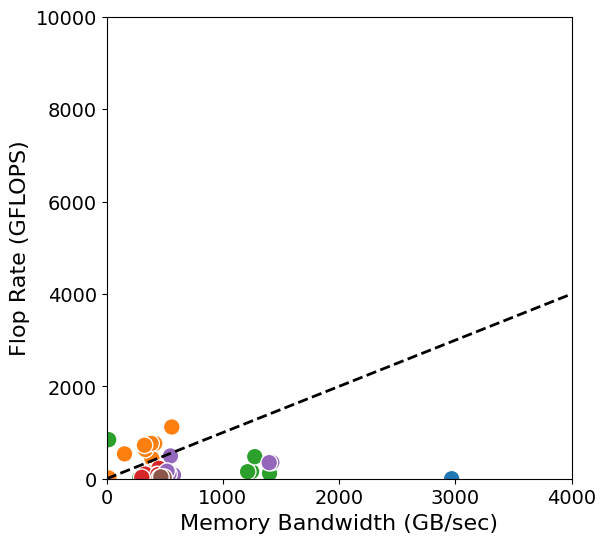

<Figure size 800x200 with 0 Axes>

In [19]:
# DDR Plot
fig_mem_v_flop_ddr, ax_mem_v_flop_ddr = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[ddr_mem_bw_mean],
    y=mem_v_flop_df[ddr_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_ddr,
    s=4 * mpl.rcParams["lines.markersize"] ** 2,
)
ax_mem_v_flop_ddr.set_xlim(left=0, right=4000)
ax_mem_v_flop_ddr.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_ddr.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_ddr.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_ddr.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_ddr.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_ddr, [0, 0], [mem_v_flop_df[ddr_mem_bw_mean].max(), mem_v_flop_df[ddr_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
sns.move_legend(ax_mem_v_flop_ddr, "center", title="Category")

mem_v_flop_figlegend = plt.figure(figsize=(8,2))
mem_v_flop_patches, mem_v_flop_labels = ax_mem_v_flop_ddr.get_legend_handles_labels()
mem_v_flop_figlegend.legend(mem_v_flop_patches, mem_v_flop_labels, title="Kernel Group", ncols=7, fontsize=18, title_fontsize=18)
ax_mem_v_flop_ddr.get_legend().remove()

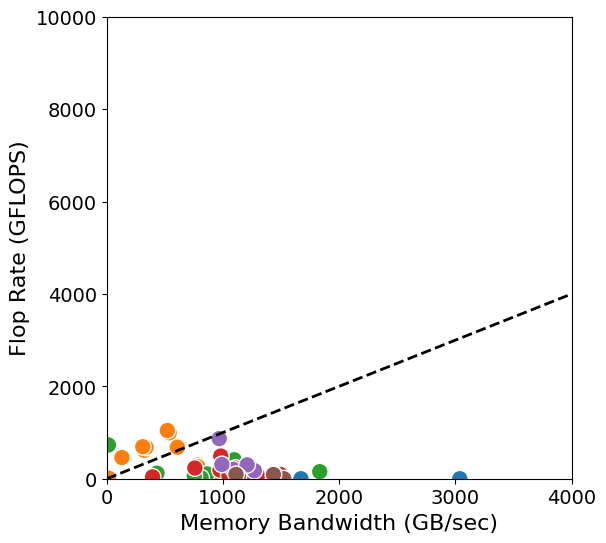

In [20]:
# HBM Plot
fig_mem_v_flop_hbm, ax_mem_v_flop_hbm = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[hbm_mem_bw_mean],
    y=mem_v_flop_df[hbm_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_hbm,
    s=4 * mpl.rcParams["lines.markersize"] ** 2,
)
ax_mem_v_flop_hbm.set_xlim(left=0, right=4000)
ax_mem_v_flop_hbm.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_hbm.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_hbm.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_hbm.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_hbm.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_hbm, [0, 0], [mem_v_flop_df[hbm_mem_bw_mean].max(), mem_v_flop_df[hbm_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
ax_mem_v_flop_hbm.get_legend().remove()

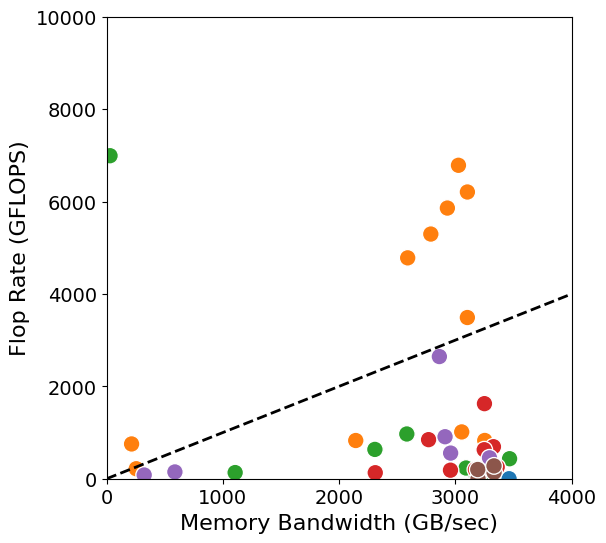

In [21]:
# V100 Plot
fig_mem_v_flop_v100, ax_mem_v_flop_v100 = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[v100_mem_bw_mean],
    y=mem_v_flop_df[v100_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_v100,
    s=4 * mpl.rcParams["lines.markersize"] ** 2,
)
ax_mem_v_flop_v100.set_xlim(left=0, right=4000)
ax_mem_v_flop_v100.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_v100.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_v100.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_v100.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_v100.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_v100, [0, 0], [mem_v_flop_df[v100_mem_bw_mean].max(), mem_v_flop_df[v100_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
ax_mem_v_flop_v100.get_legend().remove()

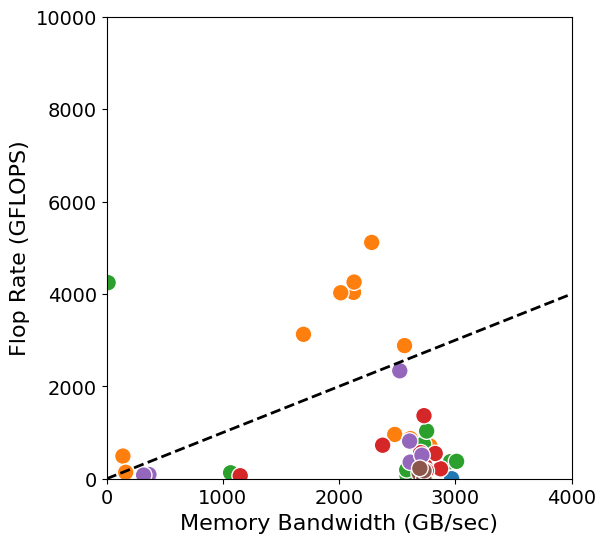

In [22]:
# a100 Plot
fig_mem_v_flop_a100, ax_mem_v_flop_a100 = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[a100_mem_bw_mean],
    y=mem_v_flop_df[a100_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_a100,
    s=4 * mpl.rcParams["lines.markersize"] ** 2,
)
ax_mem_v_flop_a100.set_xlim(left=0, right=4000)
ax_mem_v_flop_a100.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_a100.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_a100.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_a100.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_a100.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_a100, [0, 0], [mem_v_flop_df[a100_mem_bw_mean].max(), mem_v_flop_df[a100_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
ax_mem_v_flop_a100.get_legend().remove()

[78.08415154702564, 5027.180709278552, 7884.638183530316]
[13326.385238341536, 11259.015340240285, 14974.466514869282]
['Basic_MAT_MAT_SHARED', 'Apps_VOL3D', 'Apps_DIFFUSION3DPA']


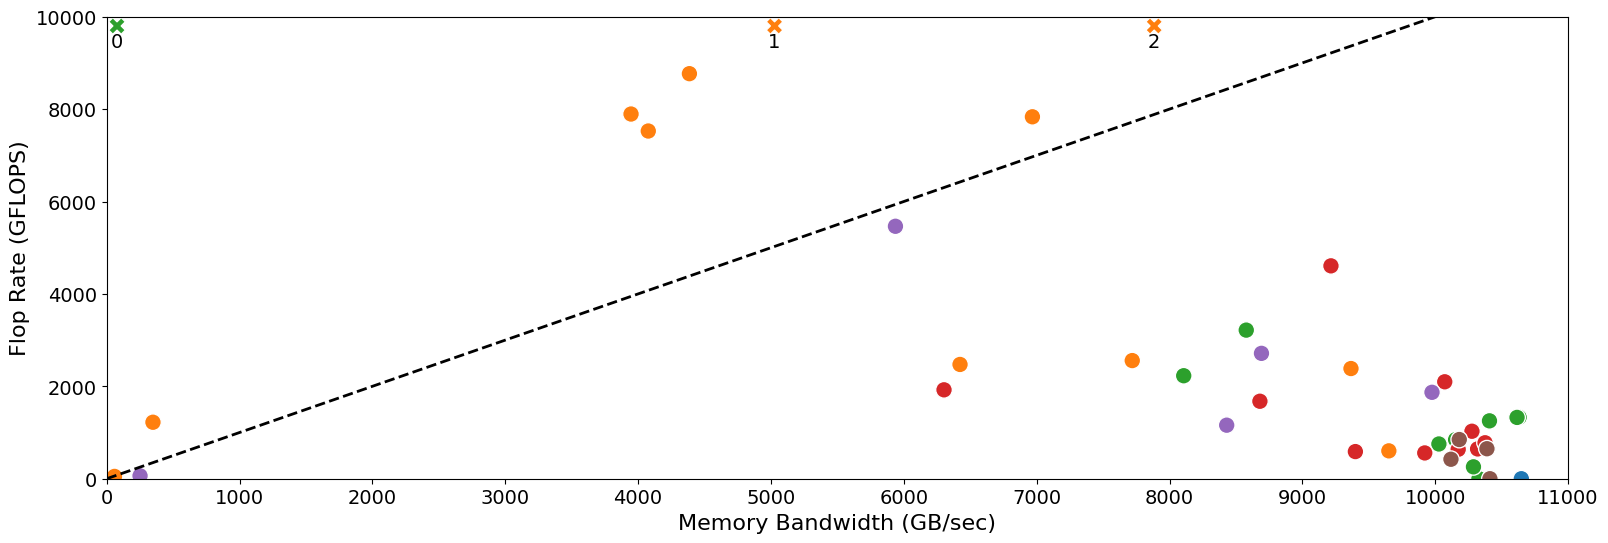

In [23]:
# MI250X Plot
fig_mem_v_flop_mi250x, ax_mem_v_flop_mi250x = plt.subplots(figsize=(6*(11000 / 3500), 6))

mi250x_ylim = 10000
mi250x_ylim_pad = 200

new_mi250x_x = mem_v_flop_df[mi250x_mem_bw_mean].tolist()
new_mi250x_y = mem_v_flop_df[mi250x_flop_rate_mean].tolist()
label_mi250x_markers = [0 for _ in range(len(new_mi250x_x))]
labels_mi250x = []
for i in range(len(new_mi250x_x)):
    y = new_mi250x_y[i]
    if y > mi250x_ylim:
        labels_mi250x.append((new_mi250x_x[i], new_mi250x_y[i], i))
        new_mi250x_y[i] = mi250x_ylim - mi250x_ylim_pad
        label_mi250x_markers[i] = 1
        
labels_mi250x = list(sorted(labels_mi250x, key=lambda tup: tup[0]))
label_mi250x_x = [tup[0] for tup in labels_mi250x]
label_mi250x_y = [tup[1] for tup in labels_mi250x]
label_mi250x_names = [tup[2] for tup in labels_mi250x]
        
label_mi250x_names = [mem_v_flop_df["name"].iloc[i] for i in label_mi250x_names]
print(label_mi250x_x)
print(label_mi250x_y)
print(label_mi250x_names)

sns.scatterplot(
    x=np.array(new_mi250x_x),  # mem_v_flop_df[mi250x_mem_bw_mean],
    y=np.array(new_mi250x_y),  # mem_v_flop_df[mi250x_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    style=label_mi250x_markers,
    ax=ax_mem_v_flop_mi250x,
    s=4 * mpl.rcParams["lines.markersize"] ** 2,
)
ax_mem_v_flop_mi250x.set_xlim(left=0, right=11000)
ax_mem_v_flop_mi250x.set_ylim(bottom=0, top=mi250x_ylim) # 90000
ax_mem_v_flop_mi250x.set_xticks(list(range(0, 11001, 1000)), list(range(0, 11001, 1000)))
ax_mem_v_flop_mi250x.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_mi250x.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_mi250x.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_mi250x, [0, 0], [mem_v_flop_df[mi250x_mem_bw_mean].max(), mem_v_flop_df[mi250x_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)

for i in range(len(label_mi250x_x)):
    label_pt = (label_mi250x_x[i], mi250x_ylim - 2.75*mi250x_ylim_pad)
    ax_mem_v_flop_mi250x.annotate(
        "{}".format(i),
        xy=label_pt,
        xytext=(0,0),
        fontsize=14,
        textcoords="offset points",
        ha="center",
        va="center",
    )

ax_mem_v_flop_mi250x.get_legend().remove()

## Performance Portability Metric

In [24]:
# Architectural Efficiency Scores = Average FLOP or BW rate / peak theoretical

peak_gflops = {"mi250x": 191500, "mi300a": 248000, "v100": 31200, "a100": 19400, "gh200": 34000, "ddr": 4700, "hbm": 4700}
peak_bw_gb = {"mi250x": 12800, "mi300a": 21200, "v100": 3600, "a100": 3200, "gh200": 4000, "ddr": 600, "hbm": 3300}

mem_v_flop_df[("ddr", "arch_eff_gflops")] = mem_v_flop_df[ddr_flop_rate_mean] / peak_gflops["ddr"] * 100
mem_v_flop_df[("hbm", "arch_eff_gflops")] = mem_v_flop_df[hbm_flop_rate_mean] / peak_gflops["hbm"] * 100
mem_v_flop_df[("v100", "arch_eff_gflops")] = mem_v_flop_df[v100_flop_rate_mean] / peak_gflops["v100"] * 100
mem_v_flop_df[("a100", "arch_eff_gflops")] = mem_v_flop_df[a100_flop_rate_mean] / peak_gflops["a100"] * 100
mem_v_flop_df[("mi250x", "arch_eff_gflops")] = mem_v_flop_df[mi250x_flop_rate_mean] / peak_gflops["mi250x"] * 100
mem_v_flop_df[("gh200", "arch_eff_gflops")] = mem_v_flop_df[gh200_flop_rate_mean] / peak_gflops["gh200"] * 100
mem_v_flop_df[("mi300a", "arch_eff_gflops")] = mem_v_flop_df[mi300a_flop_rate_mean] / peak_gflops["mi300a"] * 100

mem_v_flop_df[("ddr", "arch_eff_bw_gb")] = mem_v_flop_df[ddr_mem_bw_mean] / peak_bw_gb["ddr"] * 100
mem_v_flop_df[("hbm", "arch_eff_bw_gb")] = mem_v_flop_df[hbm_mem_bw_mean] / peak_bw_gb["hbm"] * 100
mem_v_flop_df[("v100", "arch_eff_bw_gb")] = mem_v_flop_df[v100_mem_bw_mean] / peak_bw_gb["v100"] * 100
mem_v_flop_df[("a100", "arch_eff_bw_gb")] = mem_v_flop_df[a100_mem_bw_mean] / peak_bw_gb["a100"] * 100
mem_v_flop_df[("mi250x", "arch_eff_bw_gb")] = mem_v_flop_df[mi250x_mem_bw_mean] / peak_bw_gb["mi250x"] * 100
mem_v_flop_df[("gh200", "arch_eff_bw_gb")] = mem_v_flop_df[gh200_mem_bw_mean] / peak_bw_gb["gh200"] * 100
mem_v_flop_df[("mi300a", "arch_eff_bw_gb")] = mem_v_flop_df[mi300a_mem_bw_mean] / peak_bw_gb["mi300a"] * 100

mem_v_flop_df.head()

,node,name,"(ddr, Memory Bandwidth (GB/sec)_mean)","(ddr, FLOP rate (GFLOPS)_mean)","(hbm, Memory Bandwidth (GB/sec)_mean)","(hbm, FLOP rate (GFLOPS)_mean)","(v100, Memory Bandwidth (GB/sec)_mean)","(v100, FLOP rate (GFLOPS)_mean)","(mi250x, Memory Bandwidth (GB/sec)_mean)","(mi250x, FLOP rate (GFLOPS)_mean)",...,"(mi250x, arch_eff_gflops)","(gh200, arch_eff_gflops)","(mi300a, arch_eff_gflops)","(ddr, arch_eff_bw_gb)","(hbm, arch_eff_bw_gb)","(v100, arch_eff_bw_gb)","(a100, arch_eff_bw_gb)","(mi250x, arch_eff_bw_gb)","(gh200, arch_eff_bw_gb)","(mi300a, arch_eff_bw_gb)"
0,"{'name': 'Algorithm_MEMCPY', 'type': 'function'}",Algorithm_MEMCPY,492.139527,0.000000,1671.308905,0.000000,3186.034348,0.000000,10343.428157,3.429483e-312,...,1.790853e-315,0.000000,0.000000,82.023255,50.645724,88.500954,82.428978,80.808032,83.020432,70.886053
1,"{'name': 'Algorithm_MEMSET', 'type': 'function'}",Algorithm_MEMSET,2967.769980,0.000000,3037.671182,0.000000,3461.603152,0.000000,10648.219932,7.061081e-312,...,3.687249e-315,0.000000,0.000000,494.628330,92.050642,96.155643,92.754491,83.189218,81.417729,56.869014
2,"{'name': 'Apps_CONVECTION3DPA', 'type': 'funct...",Apps_CONVECTION3DPA,413.507972,763.359194,538.333090,993.793449,2589.548521,4780.599702,4076.772730,7.526181e+03,...,3.930120e+00,8.156379,3.580374,68.917995,16.313124,71.931903,52.906789,31.849787,37.554123,22.687472
3,"{'name': 'Apps_DEL_DOT_VEC_2D', 'type': 'funct...",Apps_DEL_DOT_VEC_2D,389.174360,436.755574,608.116778,682.466317,3102.874034,3489.126599,6968.047870,7.833950e+03,...,4.090835e+00,10.645389,3.449004,64.862393,18.427781,86.190945,80.074143,54.437874,80.450339,35.880371
4,"{'name': 'Apps_DIFFUSION3DPA', 'type': 'functi...",Apps_DIFFUSION3DPA,333.120336,632.653018,323.971713,615.278203,2788.528017,5295.952335,7884.638184,1.497447e+04,...,7.819565e+00,10.952314,5.677786,55.520056,9.817325,77.459112,66.362109,61.598736,49.018003,34.972386


In [25]:
mem_v_flop_df.reset_index()[mem_v_flop_df["name"] == "Basic_MAT_MAT_SHARED"][[
    ("ddr", "FLOP rate (GFLOPS)_mean"), ("ddr", "arch_eff_gflops"),
    ("hbm", "FLOP rate (GFLOPS)_mean"), ("hbm", "arch_eff_gflops"),
    ("v100", "FLOP rate (GFLOPS)_mean"), ("v100", "arch_eff_gflops"),
    ("a100", "FLOP rate (GFLOPS)_mean"), ("a100", "arch_eff_gflops"),
    ("gh200", "FLOP rate (GFLOPS)_mean"), ("gh200", "arch_eff_gflops"),
    ("mi250x", "FLOP rate (GFLOPS)_mean"), ("mi250x", "arch_eff_gflops"),
    ("mi300a", "FLOP rate (GFLOPS)_mean"), ("mi300a", "arch_eff_gflops"),
    ]]

,"(ddr, FLOP rate (GFLOPS)_mean)","(ddr, arch_eff_gflops)","(hbm, FLOP rate (GFLOPS)_mean)","(hbm, arch_eff_gflops)","(v100, FLOP rate (GFLOPS)_mean)","(v100, arch_eff_gflops)","(a100, FLOP rate (GFLOPS)_mean)","(a100, arch_eff_gflops)","(gh200, FLOP rate (GFLOPS)_mean)","(gh200, arch_eff_gflops)","(mi250x, FLOP rate (GFLOPS)_mean)","(mi250x, arch_eff_gflops)","(mi300a, FLOP rate (GFLOPS)_mean)","(mi300a, arch_eff_gflops)"
22,845.450183,17.988302,730.537849,15.543358,6991.627316,22.409062,4243.669206,21.874584,3882.011139,11.41768,13326.385238,6.958948,17212.73369,6.940618


In [26]:
mem_v_flop_df.reset_index()[mem_v_flop_df["name"] == "Stream_TRIAD"][[
    ("ddr", "Memory Bandwidth (GB/sec)_mean"), ("ddr", "arch_eff_bw_gb"),
    ("hbm", "Memory Bandwidth (GB/sec)_mean"), ("hbm", "arch_eff_bw_gb"),
    ("v100", "Memory Bandwidth (GB/sec)_mean"), ("v100", "arch_eff_bw_gb"),
    ("a100", "Memory Bandwidth (GB/sec)_mean"), ("a100", "arch_eff_bw_gb"),
    ("gh200", "Memory Bandwidth (GB/sec)_mean"), ("gh200", "arch_eff_bw_gb"),
    ("mi250x", "Memory Bandwidth (GB/sec)_mean"), ("mi250x", "arch_eff_bw_gb"),
    ("mi300a", "Memory Bandwidth (GB/sec)_mean"), ("mi300a", "arch_eff_bw_gb"),
]]

,"(ddr, Memory Bandwidth (GB/sec)_mean)","(ddr, arch_eff_bw_gb)","(hbm, Memory Bandwidth (GB/sec)_mean)","(hbm, arch_eff_bw_gb)","(v100, Memory Bandwidth (GB/sec)_mean)","(v100, arch_eff_bw_gb)","(a100, Memory Bandwidth (GB/sec)_mean)","(a100, arch_eff_bw_gb)","(gh200, Memory Bandwidth (GB/sec)_mean)","(gh200, arch_eff_bw_gb)","(mi250x, Memory Bandwidth (GB/sec)_mean)","(mi250x, arch_eff_bw_gb)","(mi300a, Memory Bandwidth (GB/sec)_mean)","(mi300a, arch_eff_bw_gb)"
44,466.066593,77.677765,1112.878205,33.723582,3332.09939,92.558316,2694.142161,84.191943,3684.0865,92.102162,10180.987161,79.538962,15335.336639,72.336494


In [27]:
mem_v_flop_df[[
    "name",
    ("ddr", "Memory Bandwidth (GB/sec)_mean"), ("ddr", "arch_eff_bw_gb"),
    ("hbm", "Memory Bandwidth (GB/sec)_mean"), ("hbm", "arch_eff_bw_gb"),
    ("v100", "Memory Bandwidth (GB/sec)_mean"), ("v100", "arch_eff_bw_gb"),
    ("a100", "Memory Bandwidth (GB/sec)_mean"), ("a100", "arch_eff_bw_gb"),
    ("gh200", "Memory Bandwidth (GB/sec)_mean"), ("gh200", "arch_eff_bw_gb"),
    ("mi250x", "Memory Bandwidth (GB/sec)_mean"), ("mi250x", "arch_eff_bw_gb"),
    ("mi300a", "Memory Bandwidth (GB/sec)_mean"), ("mi300a", "arch_eff_bw_gb"),
]]

,name,"(ddr, Memory Bandwidth (GB/sec)_mean)","(ddr, arch_eff_bw_gb)","(hbm, Memory Bandwidth (GB/sec)_mean)","(hbm, arch_eff_bw_gb)","(v100, Memory Bandwidth (GB/sec)_mean)","(v100, arch_eff_bw_gb)","(a100, Memory Bandwidth (GB/sec)_mean)","(a100, arch_eff_bw_gb)","(gh200, Memory Bandwidth (GB/sec)_mean)","(gh200, arch_eff_bw_gb)","(mi250x, Memory Bandwidth (GB/sec)_mean)","(mi250x, arch_eff_bw_gb)","(mi300a, Memory Bandwidth (GB/sec)_mean)","(mi300a, arch_eff_bw_gb)"
0,Algorithm_MEMCPY,492.139527,82.023255,1671.308905,50.645724,3186.034348,88.500954,2637.727285,82.428978,3320.817266,83.020432,10343.428157,80.808032,15027.843169,70.886053
1,Algorithm_MEMSET,2967.769980,494.628330,3037.671182,92.050642,3461.603152,96.155643,2968.143727,92.754491,3256.709167,81.417729,10648.219932,83.189218,12056.230996,56.869014
2,Apps_CONVECTION3DPA,413.507972,68.917995,538.333090,16.313124,2589.548521,71.931903,1693.017237,52.906789,1502.164939,37.554123,4076.772730,31.849787,4809.744052,22.687472
3,Apps_DEL_DOT_VEC_2D,389.174360,64.862393,608.116778,18.427781,3102.874034,86.190945,2562.372588,80.074143,3218.013546,80.450339,6968.047870,54.437874,7606.638651,35.880371
4,Apps_DIFFUSION3DPA,333.120336,55.520056,323.971713,9.817325,2788.528017,77.459112,2123.587496,66.362109,1960.720114,49.018003,7884.638184,61.598736,7414.145930,34.972386
5,Apps_ENERGY,456.613871,76.102312,1013.775265,30.720463,3252.354602,90.343183,2781.434316,86.919822,3672.493530,91.812338,9365.868528,73.170848,12290.952257,57.976190
6,Apps_FIR,382.457605,63.742934,339.444609,10.286200,3103.118936,86.197748,2128.346898,66.510841,2524.810353,63.120259,3946.939766,30.835467,4804.089371,22.660799
7,Apps_LTIMES,151.899371,25.316562,130.389079,3.951184,214.330574,5.953627,139.669739,4.364679,120.675394,3.016885,348.445595,2.722231,518.203137,2.444354
8,Apps_LTIMES_NOVIEW,153.676686,25.612781,131.323967,3.979514,214.488809,5.958022,139.658858,4.364339,120.642783,3.016070,348.479252,2.722494,518.255928,2.444603
9,Apps_MASS3DEA,18.179991,3.029998,15.687428,0.475377,254.654857,7.073746,163.778422,5.118076,215.844772,5.396119,59.082297,0.461580,1.523342,0.007186


In [28]:
assert len(mem_v_flop_df) == 45

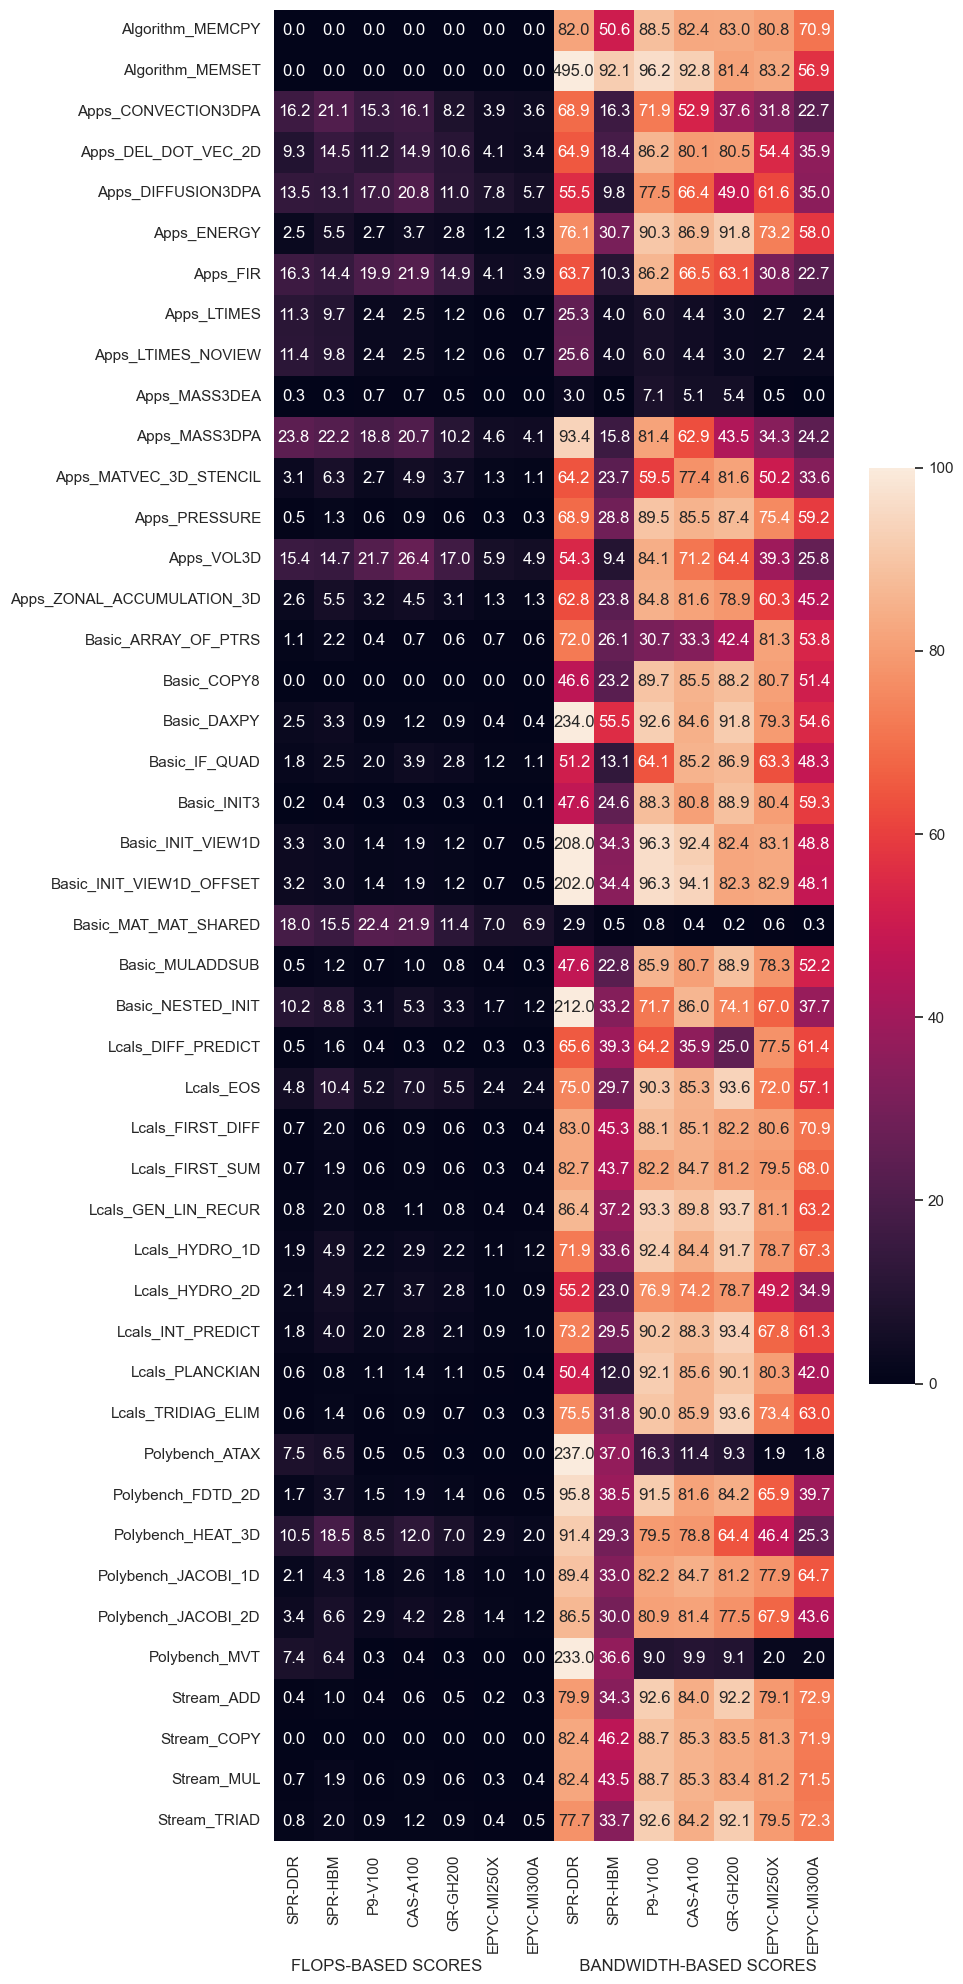

In [29]:
arch_eff_df = mem_v_flop_df[['name', ("ddr", "arch_eff_gflops"), ("hbm", "arch_eff_gflops"), ("v100", "arch_eff_gflops"), ("a100", "arch_eff_gflops"), ("gh200", "arch_eff_gflops"), ("mi250x", "arch_eff_gflops"),
                            ("mi300a", "arch_eff_gflops"), ("ddr", "arch_eff_bw_gb"), ("hbm", "arch_eff_bw_gb"), ("v100", "arch_eff_bw_gb"), ("a100", "arch_eff_bw_gb"), ("gh200", "arch_eff_bw_gb"), ("mi250x", "arch_eff_bw_gb"), ("mi300a", "arch_eff_bw_gb") ]]
arch_eff_df.set_index("name", inplace=True)
arch_eff_df[arch_eff_df < 1e-3] = 0
arch_eff_df = arch_eff_df.applymap(lambda x: round(x) if x > 100 else x)
sns.set_theme(rc={'figure.figsize':(10,20)})
xticklabels= ["SPR-DDR", "SPR-HBM", "P9-V100", "CAS-A100", "GR-GH200", "EPYC-MI250X", "EPYC-MI300A", "SPR-DDR", "SPR-HBM", "P9-V100", "CAS-A100", "GR-GH200", "EPYC-MI250X", "EPYC-MI300A"]
arch_eff_heatmap = sns.heatmap(arch_eff_df, annot=True, vmin=0, vmax=100, fmt=".1f", cbar_kws={"shrink": 0.5}, xticklabels=xticklabels).get_figure()
arch_eff_heatmap.gca().set(xlabel="FLOPS-BASED SCORES                     BANDWIDTH-BASED SCORES", ylabel="")
arch_eff_heatmap.tight_layout()
arch_eff_heatmap.savefig("arch_eff_heatmap.svg") 
arch_eff_heatmap.show()

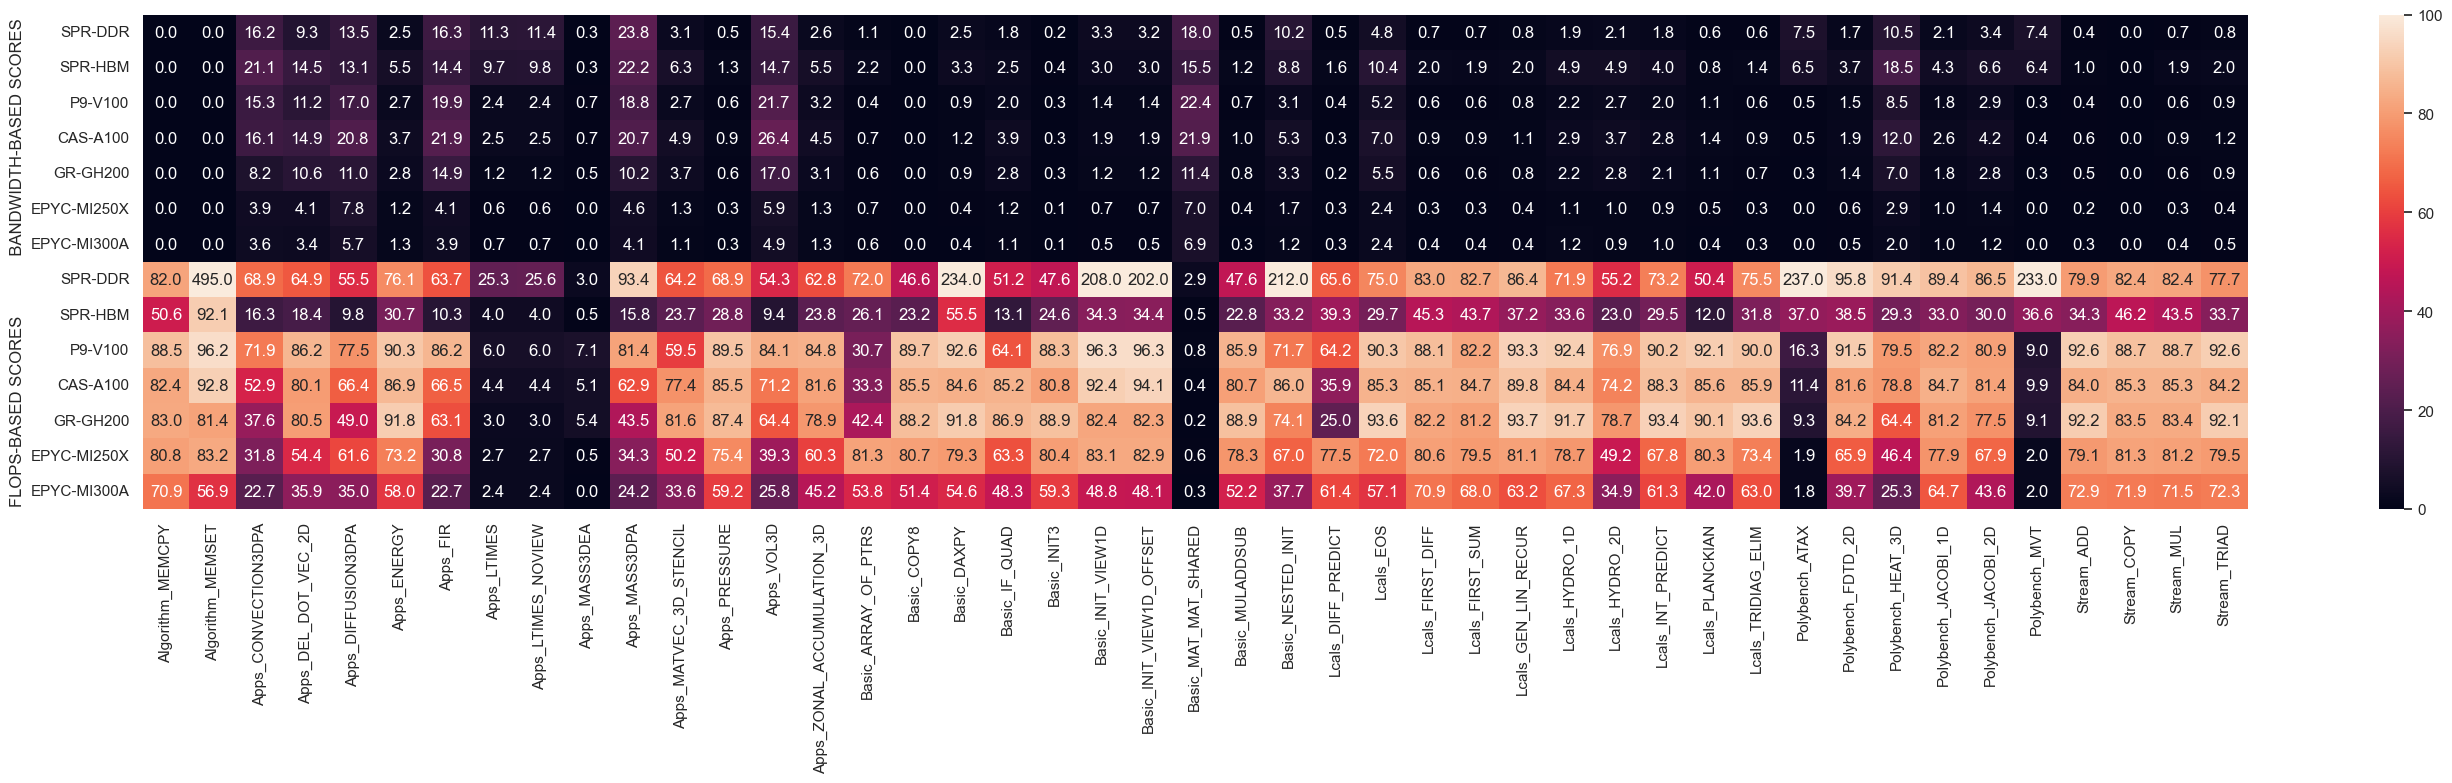

In [30]:
arch_eff_df = mem_v_flop_df[['name', ("ddr", "arch_eff_gflops"), ("hbm", "arch_eff_gflops"), ("v100", "arch_eff_gflops"), ("a100", "arch_eff_gflops"), ("gh200", "arch_eff_gflops"), ("mi250x", "arch_eff_gflops"),
                            ("mi300a", "arch_eff_gflops"), ("ddr", "arch_eff_bw_gb"), ("hbm", "arch_eff_bw_gb"), ("v100", "arch_eff_bw_gb"), ("a100", "arch_eff_bw_gb"), ("gh200", "arch_eff_bw_gb"), ("mi250x", "arch_eff_bw_gb"), ("mi300a", "arch_eff_bw_gb") ]]
arch_eff_df.set_index("name", inplace=True)
arch_eff_df[arch_eff_df < 1e-3] = 0
arch_eff_df = arch_eff_df.applymap(lambda x: round(x) if x > 100 else x)
sns.set_theme(rc={'figure.figsize':(28,8)})
# Custom formatting function
def custom_format(x):
    if x > 1:
        return int(x)  # Remove decimals for values greater than 1
    else:
        return f"{x:.1f}"  # Show one decimal place for values <= 1
xticklabels= ["SPR-DDR", "SPR-HBM", "P9-V100", "CAS-A100", "GR-GH200", "EPYC-MI250X", "EPYC-MI300A", "SPR-DDR", "SPR-HBM", "P9-V100", "CAS-A100", "GR-GH200", "EPYC-MI250X", "EPYC-MI300A"]
arch_eff_heatmap = sns.heatmap(arch_eff_df.T, annot=True, vmin=0, vmax=100, fmt=".1f", #cbar_kws={"shrink": 0.5},
                                yticklabels=xticklabels,
                               ).get_figure()
arch_eff_heatmap.gca().set(ylabel="FLOPS-BASED SCORES             BANDWIDTH-BASED SCORES", xlabel="")
arch_eff_heatmap.tight_layout()
arch_eff_heatmap.savefig("arch_eff_heatmap-horizontal.svg") 
arch_eff_heatmap.show()

In [31]:
for name in list(arch_eff_df.reset_index()["name"]):
    if name not in Memory_bound+retiring_bound:
        print(name)

In [32]:
# Harmonic Mean

for index, row in mem_v_flop_df.iterrows():
    #Flops-based
    mem_v_flop_df.at[index,'CPU FLOPS'] = stats.hmean([row[("ddr", "arch_eff_gflops")], row[("hbm", "arch_eff_gflops")],])
    mem_v_flop_df.at[index,'GPU-Prev FLOPs'] = stats.hmean([row[("v100", "arch_eff_gflops")], row[("a100", "arch_eff_gflops")], row[("mi250x", "arch_eff_gflops")],]) 
    mem_v_flop_df.at[index,'GPU-New FLOPs'] = stats.hmean([row[("gh200", "arch_eff_gflops")], row[("mi300a", "arch_eff_gflops")],]) 
    mem_v_flop_df.at[index,'GPU-NV FLOPs'] = stats.hmean([row[("v100", "arch_eff_gflops")], row[("a100", "arch_eff_gflops")], row[("gh200", "arch_eff_gflops")],]) 
    mem_v_flop_df.at[index,'GPU-AMD FLOPs'] = stats.hmean([row[("mi250x", "arch_eff_gflops")], row[("mi300a", "arch_eff_gflops")],]) 
    mem_v_flop_df.at[index,'GPU FLOPs'] = stats.hmean([row[("v100", "arch_eff_gflops")], row[("a100", "arch_eff_gflops")], 
                                                                row[("mi250x", "arch_eff_gflops")], row[("gh200", "arch_eff_gflops")], row[("mi300a", "arch_eff_gflops")],]) 
    mem_v_flop_df.at[index,'All FLOPs'] = stats.hmean([row[("ddr", "arch_eff_gflops")], row[("hbm", "arch_eff_gflops")], row[("v100", "arch_eff_gflops")], row[("a100", "arch_eff_gflops")], 
                                                                row[("mi250x", "arch_eff_gflops")], row[("gh200", "arch_eff_gflops")], row[("mi300a", "arch_eff_gflops")],])
    # Bandwidth-based
    mem_v_flop_df.at[index,'CPU BW'] = stats.hmean([row[("ddr", "arch_eff_bw_gb")], row[("hbm", "arch_eff_bw_gb")], ])
    mem_v_flop_df.at[index,'GPU-Prev BW'] = stats.hmean([row[("v100", "arch_eff_bw_gb")], row[("a100", "arch_eff_bw_gb")], row[("mi250x", "arch_eff_bw_gb")],])
    mem_v_flop_df.at[index,'GPU-New BW'] = stats.hmean([row[("gh200", "arch_eff_bw_gb")], row[("mi300a", "arch_eff_bw_gb")],])
    mem_v_flop_df.at[index,'GPU-NV BW'] = stats.hmean([row[("v100", "arch_eff_bw_gb")], row[("a100", "arch_eff_bw_gb")], row[("gh200", "arch_eff_bw_gb")],])
    mem_v_flop_df.at[index,'GPU-AMD BW'] = stats.hmean([row[("mi250x", "arch_eff_bw_gb")], row[("mi300a", "arch_eff_bw_gb")],])
    mem_v_flop_df.at[index,'GPU BW'] = stats.hmean([row[("v100", "arch_eff_bw_gb")], row[("a100", "arch_eff_bw_gb")], 
                                                                row[("mi250x", "arch_eff_bw_gb")], row[("gh200", "arch_eff_bw_gb")], row[("mi300a", "arch_eff_bw_gb")],])
    mem_v_flop_df.at[index,'All BW'] = stats.hmean([row[("ddr", "arch_eff_bw_gb")], row[("hbm", "arch_eff_bw_gb")], row[("v100", "arch_eff_bw_gb")], row[("a100", "arch_eff_bw_gb")], 
                                                                row[("mi250x", "arch_eff_bw_gb")], row[("gh200", "arch_eff_bw_gb")], row[("mi300a", "arch_eff_bw_gb")],])
    
perf_port_df = mem_v_flop_df[['name', 'CPU FLOPS', 'GPU-Prev FLOPs', 'GPU-New FLOPs','GPU-NV FLOPs', 'GPU-AMD FLOPs', 'GPU FLOPs', 'All FLOPs', 
                              'CPU BW', 'GPU-Prev BW', 'GPU-New BW', 'GPU-NV BW', 'GPU-AMD BW', 'GPU BW','All BW', ]]
perf_port_df.set_index("name", inplace=True)
perf_port_df.head()

,CPU FLOPS,GPU-Prev FLOPs,GPU-New FLOPs,GPU-NV FLOPs,GPU-AMD FLOPs,GPU FLOPs,All FLOPs,CPU BW,GPU-Prev BW,GPU-New BW,GPU-NV BW,GPU-AMD BW,GPU BW,All BW
name,,,,,,,,,,,,,,
Algorithm_MEMCPY,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,62.623941,83.784895,76.474890,84.563743,75.522555,80.699371,74.551345
Algorithm_MEMSET,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,155.215569,90.356701,66.964423,89.650475,67.556026,79.279070,92.161465
Apps_CONVECTION3DPA,18.371631,7.857950,4.976315,12.003012,3.747104,6.380132,7.842730,26.381627,46.728544,28.286373,50.478335,26.498990,37.062841,33.220014
Apps_DEL_DOT_VEC_2D,11.332758,7.477750,5.210013,11.967510,3.742601,6.368888,7.279944,28.701344,70.654507,49.627274,82.145417,43.252637,60.415253,45.918590
Apps_DIFFUSION3DPA,13.273291,12.771439,7.478596,15.127091,6.578745,9.953635,10.719631,16.684428,67.853383,40.820779,62.009678,44.614886,53.643676,32.851529


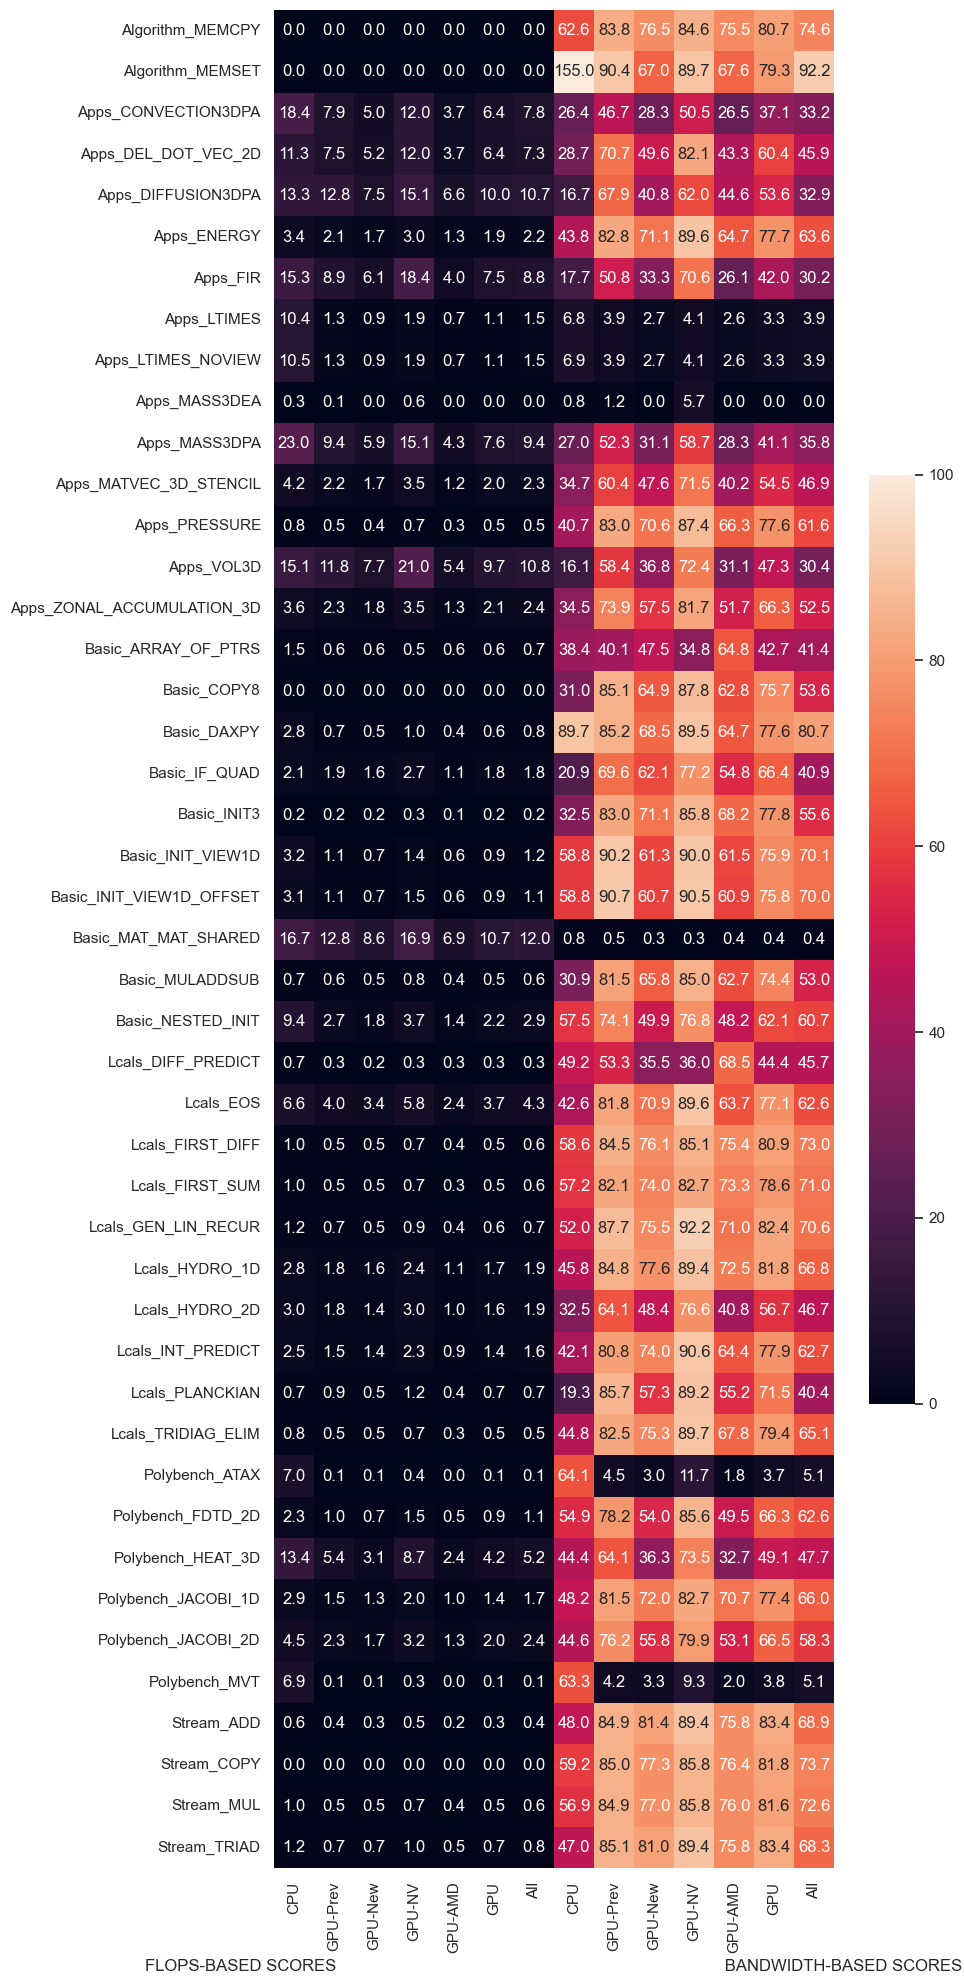

In [33]:
sns.set_theme(rc={'figure.figsize':(10,20)})
xticklabels = ["CPU",'GPU-Prev', 'GPU-New','GPU-NV', 'GPU-AMD', 'GPU', 'All',"CPU",'GPU-Prev', 'GPU-New','GPU-NV', 'GPU-AMD', 'GPU', 'All',]
perf_port_df[perf_port_df < 1e-3] = 0
perf_port_df = perf_port_df.applymap(lambda x: round(x) if x > 100 else x)
perf_port_heatmap = sns.heatmap(perf_port_df, annot=True, vmin=0, vmax=100, fmt=".1f", cbar_kws={"shrink": 0.5}, xticklabels=xticklabels).get_figure()
perf_port_heatmap.gca().set(xlabel="FLOPS-BASED SCORES                                                                                    BANDWIDTH-BASED SCORES", ylabel="")
perf_port_heatmap.tight_layout()
perf_port_heatmap.savefig("perf_port_heatmap.svg") 
perf_port_heatmap.show()

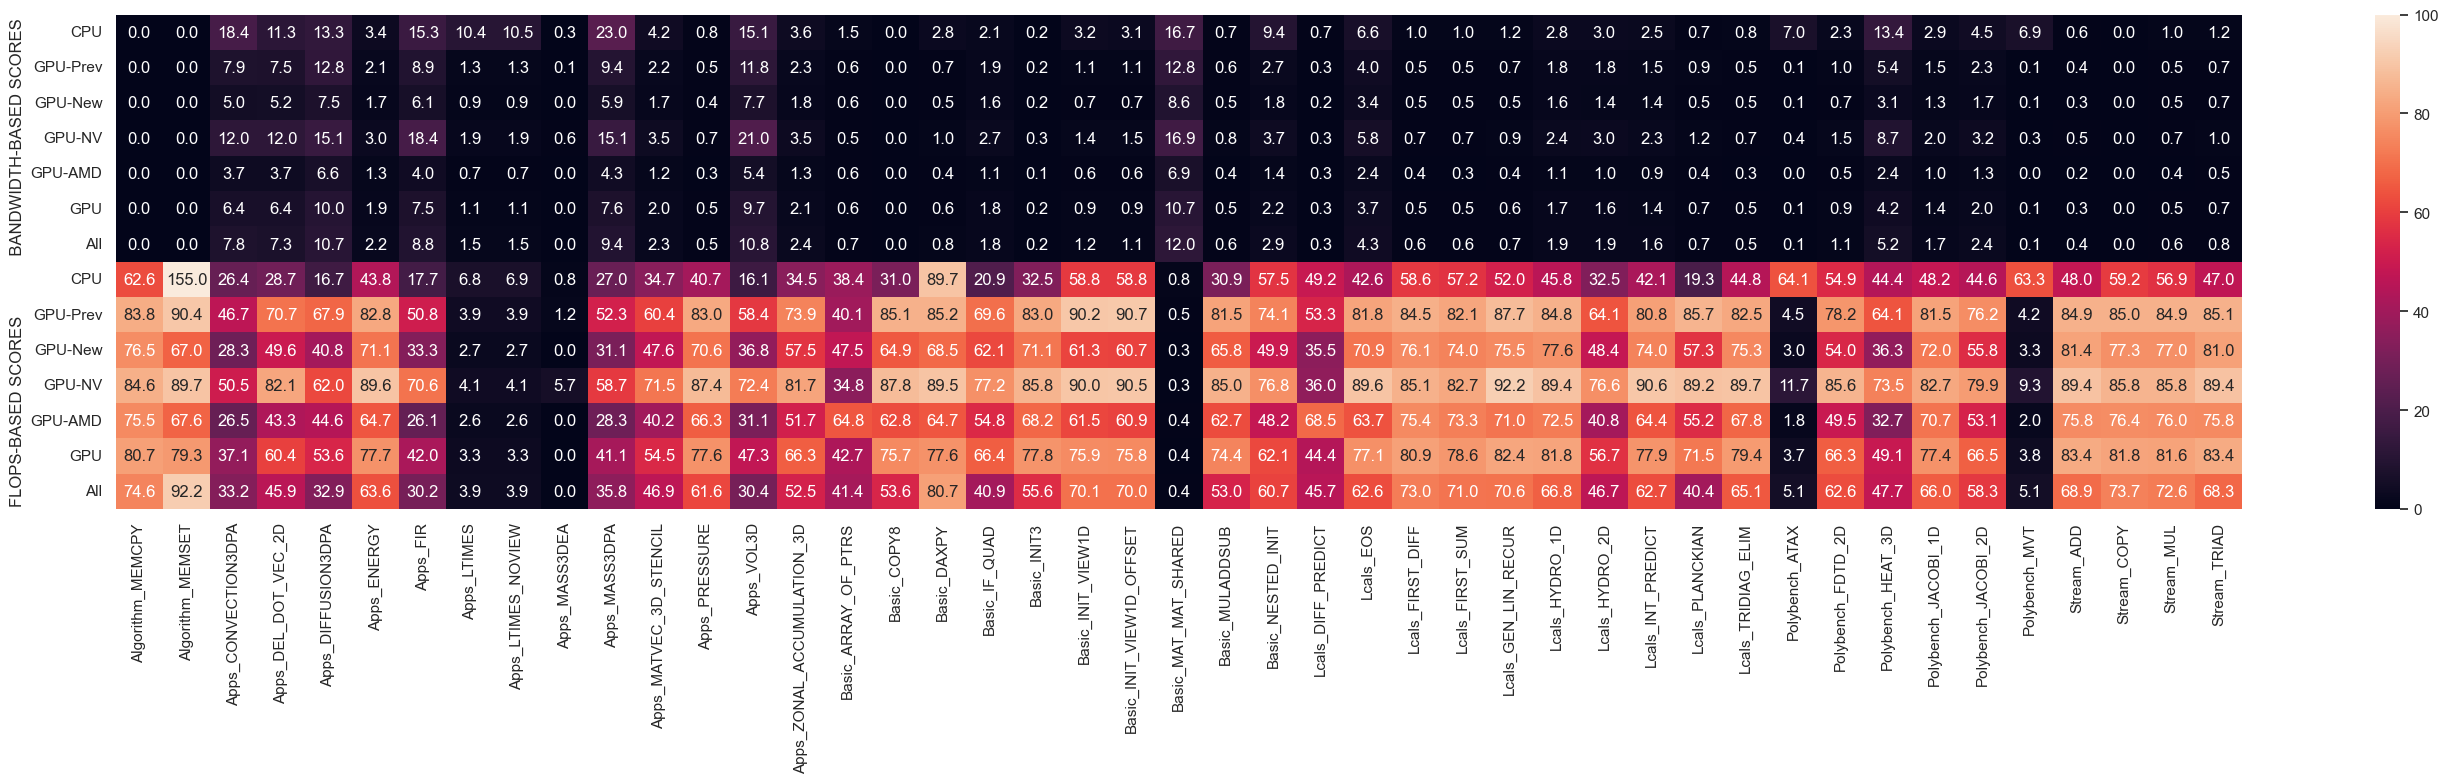

In [34]:
sns.set_theme(rc={'figure.figsize':(28,8)})
xticklabels = ["CPU",'GPU-Prev', 'GPU-New','GPU-NV', 'GPU-AMD', 'GPU', 'All',"CPU",'GPU-Prev', 'GPU-New','GPU-NV', 'GPU-AMD', 'GPU', 'All',]
perf_port_df[perf_port_df < 1e-3] = 0
perf_port_df = perf_port_df.applymap(lambda x: round(x) if x > 100 else x)
perf_port_heatmap = sns.heatmap(perf_port_df.T, annot=True, vmin=0, vmax=100, fmt=".1f", 
                                #cbar_kws={"shrink": 0.5},
                                  yticklabels=xticklabels).get_figure()
perf_port_heatmap.gca().set(ylabel="FLOPS-BASED SCORES             BANDWIDTH-BASED SCORES", xlabel="")
perf_port_heatmap.tight_layout()
perf_port_heatmap.savefig("perf_port_heatmap-horizontal.svg") 
perf_port_heatmap.show()

### 6.2 Metric bar charts for each kernel

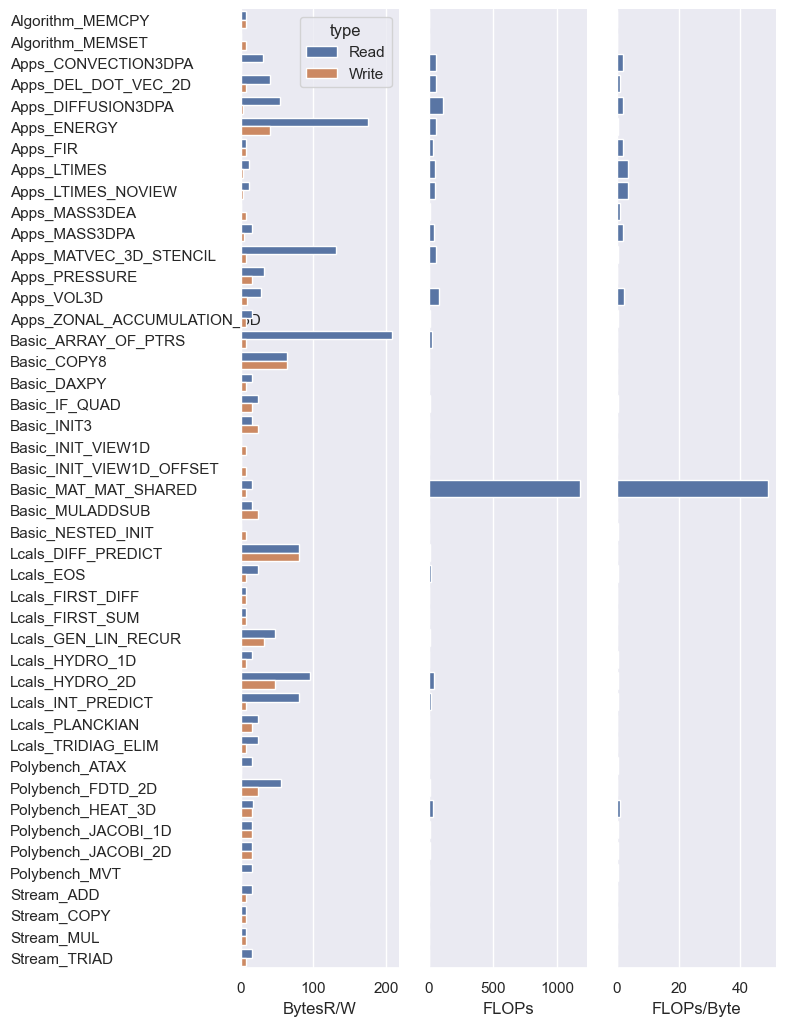

In [35]:
#analytic_metric_color_map = sns.color_palette("colorblind")

analytic_met_read_df = th.statsframe.dataframe[[
    "name",
    ddr_bytes_read_per_rep_scaled_mean,
    ddr_flops_per_rep_scaled_mean,
    ddr_flops_per_byte_mean,
]]
analytic_met_write_df = th.statsframe.dataframe[[
    "name",
    ddr_bytes_write_per_rep_scaled_mean,
    ddr_flops_per_rep_scaled_mean,
    ddr_flops_per_byte_mean,
]]
analytic_met_read_df.columns = analytic_met_read_df.columns.to_flat_index()
analytic_met_read_df.rename(
    columns={
        "name": "Kernel",
        ddr_bytes_read_per_rep_scaled_mean: "BytesR/W",
        ddr_flops_per_rep_scaled_mean: "FLOPs",
        ddr_flops_per_byte_mean: "FLOPs/Byte",
    },
    inplace=True
)
analytic_met_read_df["FLOPs/Byte"] = analytic_met_read_df["FLOPs/Byte"].apply(lambda x: x if x < 1000 else 0.0)
analytic_met_write_df.columns = analytic_met_write_df.columns.to_flat_index()
analytic_met_write_df.rename(
    columns={
        "name": "Kernel",
        ddr_bytes_write_per_rep_scaled_mean: "BytesR/W",
        ddr_flops_per_rep_scaled_mean: "FLOPs",
        ddr_flops_per_byte_mean: "FLOPs/Byte",
    },
    inplace=True
)
analytic_met_read_df["type"] = "Read"
analytic_met_write_df["type"] = "Write"
analytic_met_df = pd.concat([analytic_met_read_df, analytic_met_write_df]).reset_index(drop=True)

analytic_met_read_df["color"] = 1

pg_analytic = sns.PairGrid(
    data=analytic_met_read_df,
    y_vars=["Kernel"],
    x_vars=["BytesR/W", "FLOPs", "FLOPs/Byte"],
    despine=True,
    height=10.5,
    aspect=0.2,
    hue="color"
)
pg_analytic.tight_layout()
pg_analytic.map(sns.barplot)

pg_analytic.figure.axes[0].clear()
sns.barplot(
    data=analytic_met_df,
    y="Kernel",
    x="BytesR/W",
    hue="type",
    ax=pg_analytic.figure.axes[0],
)
pg_analytic.figure.axes[0].get_yaxis().get_label().set_visible(False)

pg_analytic_y_ax = pg_analytic.figure.axes[0].get_yaxis()
pg_analytic_y_ax.set_tick_params(pad=160)
for tick in pg_analytic_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")

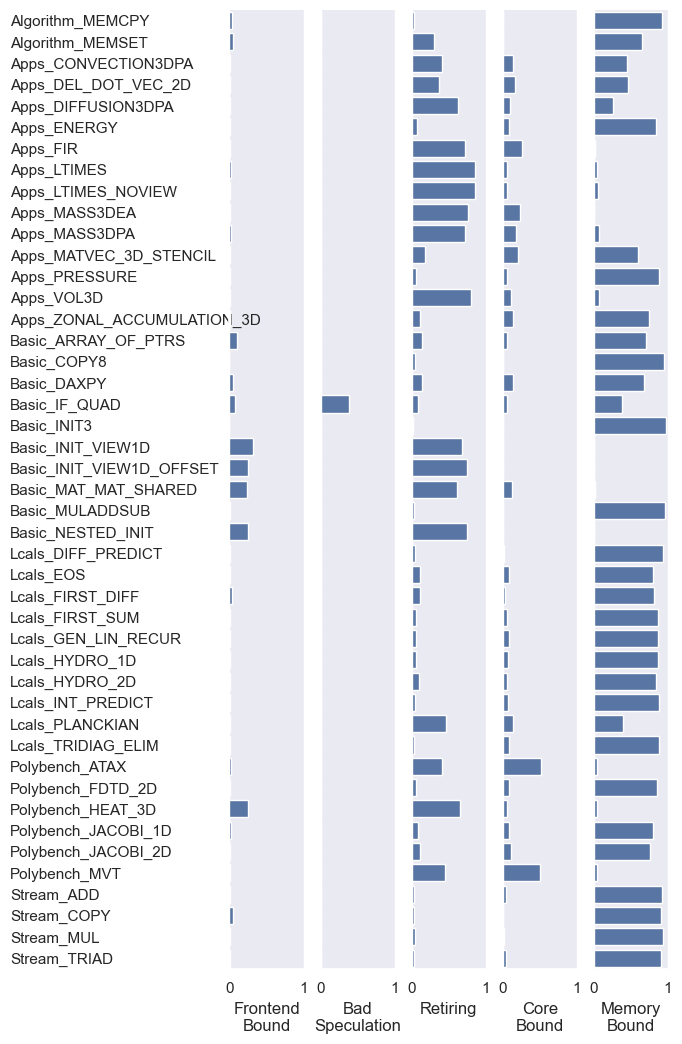

In [36]:
ddr_tma_df = th.statsframe.dataframe[[
    "name",
    ddr_fe_bound_mean,
    ddr_bad_spec_mean,
    ddr_retiring_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean
]]
ddr_tma_df.columns = ddr_tma_df.columns.to_flat_index()
ddr_tma_df.rename(
    columns={
        "name": "Kernel",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
    },
    inplace=True
)

ddr_tma_df["color"] = 1

pg_ddr_tma = sns.PairGrid(
    data=ddr_tma_df,
    y_vars=["Kernel"],
    x_vars=[
        "Frontend Bound",
        "Bad Speculation",
        "Retiring",
        "Core Bound",
        "Memory Bound"
    ],
    despine=True,
    height=10.5,
    aspect=0.1,
    hue="color"
)
pg_ddr_tma.tight_layout()
pg_ddr_tma.map(sns.barplot)
pg_ddr_tma.figure.axes[0].get_yaxis().get_label().set_visible(False)
for ax in pg_ddr_tma.figure.axes:
    ax.set_xlim(0, 1)
    ax.set_xlabel(ax.get_xlabel().replace(" ", "\n"))
pg_ddr_tma_y_ax = pg_ddr_tma.figure.axes[0].get_yaxis()
pg_ddr_tma_y_ax.set_tick_params(pad=152)
for tick in pg_ddr_tma_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")
#pg_ddr_tma.figure.savefig("figures/ddr_topdown_per_kernel.png", bbox_inches="tight", dpi=200)

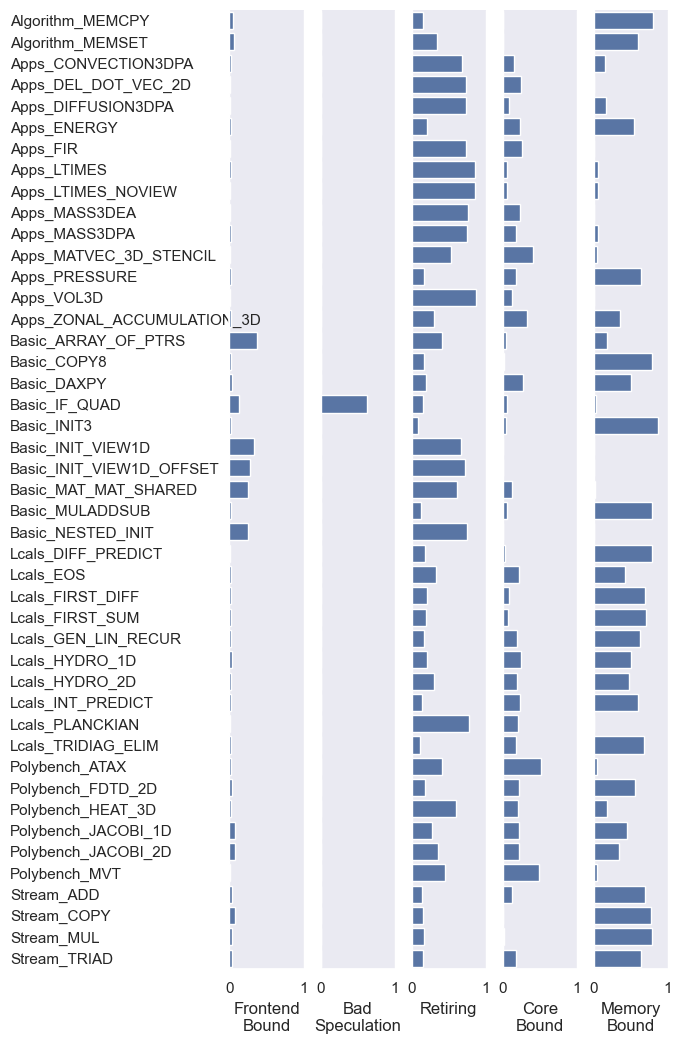

In [37]:
hbm_tma_df = th.statsframe.dataframe[[
    "name",
    # hbm_mem_bw_mean,
    # hbm_flop_rate_mean,
    hbm_fe_bound_mean,
    hbm_bad_spec_mean,
    hbm_retiring_mean,
    hbm_core_bound_mean,
    hbm_mem_bound_mean
]]
hbm_tma_df.columns = hbm_tma_df.columns.to_flat_index()
hbm_tma_df.rename(
    columns={
        "name": "Kernel",
        # hbm_mem_bw_mean: "Memory Bandwidth (GiB/s)",
        # hbm_flop_rate_mean: "FLOP Rate (GiFLOPS/s)",
        hbm_fe_bound_mean: "Frontend Bound",
        hbm_bad_spec_mean: "Bad Speculation",
        hbm_retiring_mean: "Retiring",
        hbm_core_bound_mean: "Core Bound",
        hbm_mem_bound_mean: "Memory Bound",
    },
    inplace=True
)

hbm_tma_df["color"] = 1

pg_hbm_tma = sns.PairGrid(
    data=hbm_tma_df,
    y_vars=["Kernel"],
    x_vars=[
        # "Memory Bandwidth (GiB/s)",
        # "FLOP Rate (GiFLOPS/s)",
        "Frontend Bound",
        "Bad Speculation",
        "Retiring",
        "Core Bound",
        "Memory Bound"
    ],
    despine=True,
    height=10.5,
    aspect=0.1,
    hue="color"
)
pg_hbm_tma.tight_layout()
pg_hbm_tma.map(sns.barplot)
pg_hbm_tma.figure.axes[0].get_yaxis().get_label().set_visible(False)
for ax in pg_hbm_tma.figure.axes:
    ax.set_xlim(0, 1)
    ax.set_xlabel(ax.get_xlabel().replace(" ", "\n"))
pg_hbm_tma_y_ax = pg_hbm_tma.figure.axes[0].get_yaxis()
pg_hbm_tma_y_ax.set_tick_params(pad=152)
for tick in pg_hbm_tma_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")
#pg_hbm_tma.figure.savefig("figures/hbm_topdown_per_kernel.png", bbox_inches="tight", dpi=200)

# Speedup over SPR-DDR Plot

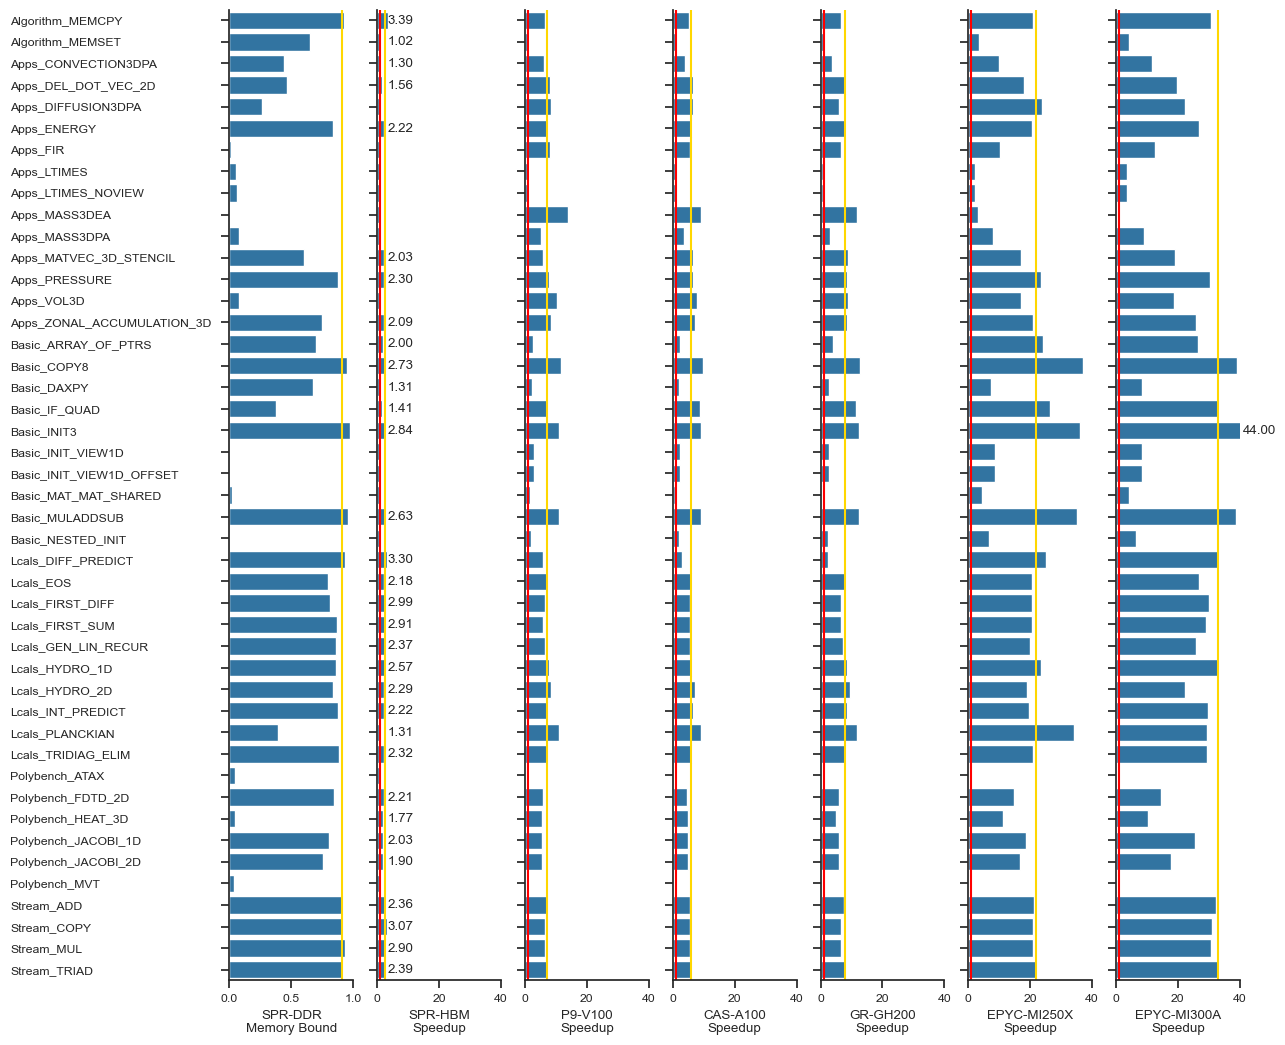

In [38]:

triple_plot_df = th.statsframe.dataframe[["name", ddr_mem_bound_mean, ddr_to_hbm_speedup, ddr_to_v100_speedup, ddr_to_a100_speedup, ddr_to_gh200_speedup, ddr_to_mi250x_speedup, ddr_to_mi300a_speedup]].reset_index(drop=True)
triple_plot_df.reset_index(inplace=True)

triple_plot_df.columns = triple_plot_df.columns.to_flat_index()
triple_plot_df.rename(
    columns={
        "name": "Kernel",
        ddr_mem_bound_mean: "DDR Memory Bound",
        ddr_to_hbm_speedup: "SPR-HBM Speedup",
        ddr_to_v100_speedup: "V100 Speedup",
        ddr_to_a100_speedup: "A100 Speedup",
        ddr_to_gh200_speedup: "GH200 Speedup",
        ddr_to_mi250x_speedup: "MI250X Speedup",
        ddr_to_mi300a_speedup: "MI300A Speedup",
    },
    inplace=True
)

ddr_stream_copy_mem_bound = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["DDR Memory Bound"].iloc[0]
hbm_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["SPR-HBM Speedup"].iloc[0]
v100_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["V100 Speedup"].iloc[0]
mi250x_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["MI250X Speedup"].iloc[0]
mi300a_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["MI300A Speedup"].iloc[0]
a100_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["A100 Speedup"].iloc[0]
gh200_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["GH200 Speedup"].iloc[0]

sns.set_theme(palette="tab10", font_scale=0.8)
sns.set_style("ticks")
triple_plot_df["color"] = 1

pg_triple = sns.PairGrid(
    data=triple_plot_df,
    y_vars=["Kernel"],
    x_vars=["DDR Memory Bound", "SPR-HBM Speedup", "V100 Speedup", "A100 Speedup", "GH200 Speedup", "MI250X Speedup", "MI300A Speedup"],
    despine=True,
    height=10.5,
    aspect=0.15,
    hue="color"
)
pg_triple.tight_layout()
pg_triple.map(sns.barplot)
pg_triple.figure.axes[0].set_xlim(0, 1)
pg_triple.figure.axes[0].set_xlabel("SPR-DDR\nMemory Bound")
pg_triple.figure.axes[0].get_yaxis().get_label().set_visible(False)
pg_triple.figure.axes[0].axvline(ddr_stream_copy_mem_bound, color="gold")
pg_triple.figure.axes[1].axvline(1.0, color="red")
pg_triple.figure.axes[1].axvline(hbm_stream_copy_spdup, color="gold")
pg_triple.figure.axes[1].set_xlim(0, 40)
pg_triple.figure.axes[1].set_xlabel("SPR-HBM\nSpeedup")
pg_triple.figure.axes[2].axvline(1.0, color="red")
pg_triple.figure.axes[2].axvline(v100_stream_copy_spdup, color="gold")
pg_triple.figure.axes[2].set_xlim(0, 40)
pg_triple.figure.axes[2].set_xlabel("P9-V100\nSpeedup")
pg_triple.figure.axes[3].axvline(1.0, color="red")
pg_triple.figure.axes[3].axvline(a100_stream_copy_spdup, color="gold")
pg_triple.figure.axes[3].set_xlim(0, 40)
pg_triple.figure.axes[3].set_xlabel("CAS-A100\nSpeedup")
pg_triple.figure.axes[4].axvline(1.0, color="red")
pg_triple.figure.axes[4].axvline(gh200_stream_copy_spdup, color="gold")
pg_triple.figure.axes[4].set_xlim(0, 40)
pg_triple.figure.axes[4].set_xlabel("GR-GH200\nSpeedup")
pg_triple.figure.axes[5].axvline(1.0, color="red")
pg_triple.figure.axes[5].axvline(mi250x_stream_copy_spdup, color="gold")
pg_triple.figure.axes[5].set_xlim(0, 40)
pg_triple.figure.axes[5].set_xlabel("EPYC-MI250X\nSpeedup")
pg_triple.figure.axes[6].axvline(1.0, color="red")
pg_triple.figure.axes[6].axvline(mi300a_stream_copy_spdup, color="gold")
pg_triple.figure.axes[6].set_xlim(0, 40)
pg_triple.figure.axes[6].set_xlabel("EPYC-MI300A\nSpeedup")

gpu_stream_copy_spdups = {
    "V100": v100_stream_copy_spdup,
    "A100": a100_stream_copy_spdup,
    "GH200": gh200_stream_copy_spdup,
    "MI250X": mi250x_stream_copy_spdup,
    "MI300A": mi300a_stream_copy_spdup,
}

starting_subplot_idx = 2
for i, gpu_type in enumerate(["V100", "A100", "GH200", "MI250X", "MI300A"]):
    for label in pg_triple.figure.axes[0].get_yticklabels():
        _, label_y = label.get_position()
        min_x, max_x = pg_triple.figure.axes[starting_subplot_idx+i].get_xlim()
        curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["{} Speedup".format(gpu_type)].iloc[0]
        if curr_kernel_speedup > max_x:
            pg_triple.figure.axes[starting_subplot_idx+i].annotate(
                "{:.2f}".format(curr_kernel_speedup),
                xy=(max_x, label_y),
                xytext=(2, 0),
                textcoords="offset points",
                ha="left",
                va="center",
            )
starting_subplot_idx = 1         
for label in pg_triple.figure.axes[0].get_yticklabels():
    _, label_y = label.get_position()
    curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["SPR-HBM Speedup"].iloc[0]
    if curr_kernel_speedup > 1:
        pg_triple.figure.axes[starting_subplot_idx].annotate(
            "{:.2f}".format(curr_kernel_speedup),
            xy=(2, label_y),
            xytext=(3, 0),
            textcoords="offset points",
            ha="left",
            va="center",
        )

pg_triple_y_ax = pg_triple.figure.axes[0].get_yaxis()
pg_triple_y_ax.set_tick_params(pad=152)
for tick in pg_triple_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")

### 6.3 Analysis of kernel performance using clustering

#### 6.3A Agglomerative hierarchical clustering

In [39]:
# Try bytes/rep, flops/rep, and flops/bytes (divide by problem size first)
clustering_metrics = [
    ddr_retiring_mean,
    ddr_fe_bound_mean,
    ddr_bad_spec_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean,
]
clustering_data = th.statsframe.dataframe.loc[:, clustering_metrics].copy(deep=True)

In [40]:
# Determine outliers based on speedup
speedup_cols = [ddr_to_mi250x_speedup, ddr_to_v100_speedup, ddr_to_hbm_speedup]

for spdp in speedup_cols:
    # calculate z score for that column
    z = np.abs(stats.zscore(th.statsframe.dataframe[spdp]))
    # 3 is the typical z score threshold 
    outlier_indices = np.where(z > 3)[0]
    # if there is at least one outlier print the name
    if len(outlier_indices) > 0:    
        print(th.statsframe.dataframe.iloc[[outlier_indices[0]]].name.unique())

In [41]:
# We need to filter non O(n) complexity kernels (listed in the table 1 in the paper) as well as outliers based on speedup identified in cell above
Non_On_kernels = [
    "Algorithm_SORT",
    "Algorithm_SORTPAIRS",
    "Comm_HALO_EXCHANGE",
    "Comm_HALO_EXCHANGE_FUSED",
    "Comm_HALO_PACKING",
    "Comm_HALO_PACKING_FUSED",
    "Comm_HALO_SENDRECV",
    "Polybench_2MM",
    "Polybench_3MM" ,
    "Polybench_FLOYD_WARSHALL",
    "Polybench_GEMM",
    "Apps_EDGE3D",
    "Basic_PI_REDUCE",
]

clustering_data["name"] = [n.frame["name"] for n in clustering_data.index]
clustering_data = clustering_data[~clustering_data["name"].isin(Non_On_kernels)]
clustering_data = clustering_data.drop(columns=["name"])
# Filter from statsframe
th.statsframe.dataframe = th.statsframe.dataframe[~th.statsframe.dataframe["name"].isin(Non_On_kernels)]

In [42]:
clustering_data

,"(ddr_topdown, Retiring_mean)","(ddr_topdown, Frontend bound_mean)","(ddr_topdown, Bad speculation_mean)","(ddr_topdown, Core bound_mean)","(ddr_topdown, Memory bound_mean)"
node,,,,,
"{'name': 'Algorithm_MEMCPY', 'type': 'function'}",0.034130,0.036830,0.000045,0.006275,0.922720
"{'name': 'Algorithm_MEMSET', 'type': 'function'}",0.299764,0.052811,0.000090,0.000392,0.646944
"{'name': 'Apps_CONVECTION3DPA', 'type': 'function'}",0.408572,0.007797,0.000067,0.139597,0.443966
"{'name': 'Apps_DEL_DOT_VEC_2D', 'type': 'function'}",0.363637,0.007751,0.000086,0.165752,0.462774
"{'name': 'Apps_DIFFUSION3DPA', 'type': 'function'}",0.628482,0.008966,0.000057,0.098862,0.263633
"{'name': 'Apps_ENERGY', 'type': 'function'}",0.071007,0.004241,0.000072,0.091015,0.833665
"{'name': 'Apps_FIR', 'type': 'function'}",0.721853,0.007371,0.000081,0.259318,0.011377
"{'name': 'Apps_LTIMES', 'type': 'function'}",0.851766,0.022836,0.012065,0.061961,0.051372
"{'name': 'Apps_LTIMES_NOVIEW', 'type': 'function'}",0.857706,0.011555,0.008100,0.063678,0.058963


In [43]:
thresh = 1.4
cluster_op = sk.AgglomerativeClustering(linkage="ward", distance_threshold=thresh, n_clusters=None, compute_full_tree=True)
th.statsframe.dataframe[("label", "")] = cluster_op.fit_predict(clustering_data)

cluster_summary_df = th.statsframe.dataframe[["name", *clustering_metrics, ddr_to_hbm_speedup, ddr_to_v100_speedup, ddr_to_mi250x_speedup, ("label", "")]].reset_index(drop=True)
cluster_summary_df.columns = cluster_summary_df.columns.to_flat_index()
cluster_summary_df.rename(
    columns={
        "name": "Kernel",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
        ddr_to_hbm_speedup: "Speedup on SPR-HBM",
        ddr_to_v100_speedup: "Speedup on P9-V100",
        ddr_to_mi250x_speedup: "Speedup on EPYC-MI250X",
        ("label", ""): "Cluster ID",
    },
    inplace=True
)
cluster_summary_df

,Kernel,Retiring,Frontend Bound,Bad Speculation,Core Bound,Memory Bound,Speedup on SPR-HBM,Speedup on P9-V100,Speedup on EPYC-MI250X,Cluster ID
0,Algorithm_MEMCPY,0.034130,0.036830,0.000045,0.006275,0.922720,3.386796,6.473918,21.017597,1
1,Algorithm_MEMSET,0.299764,0.052811,0.000090,0.000392,0.646944,1.023321,1.166566,3.588471,1
2,Apps_CONVECTION3DPA,0.408572,0.007797,0.000067,0.139597,0.443966,1.301700,6.262460,9.859156,0
3,Apps_DEL_DOT_VEC_2D,0.363637,0.007751,0.000086,0.165752,0.462774,1.562515,7.980201,17.913766,0
4,Apps_DIFFUSION3DPA,0.628482,0.008966,0.000057,0.098862,0.263633,0.972539,8.371183,23.669824,0
5,Apps_ENERGY,0.071007,0.004241,0.000072,0.091015,0.833665,2.216925,7.122768,20.511563,1
6,Apps_FIR,0.721853,0.007371,0.000081,0.259318,0.011377,0.887608,8.114739,10.321326,0
7,Apps_LTIMES,0.851766,0.022836,0.012065,0.061961,0.051372,0.858390,1.412363,2.295889,0
8,Apps_LTIMES_NOVIEW,0.857706,0.011555,0.008100,0.063678,0.058963,0.854549,1.397028,2.269503,0
9,Apps_MASS3DEA,0.760391,0.005020,0.000078,0.234118,0.000392,0.862880,13.981073,3.243761,0


#### 6.3B Dendrogram Visualization of Clusters

In [44]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    return dendrogram(linkage_matrix, **kwargs)

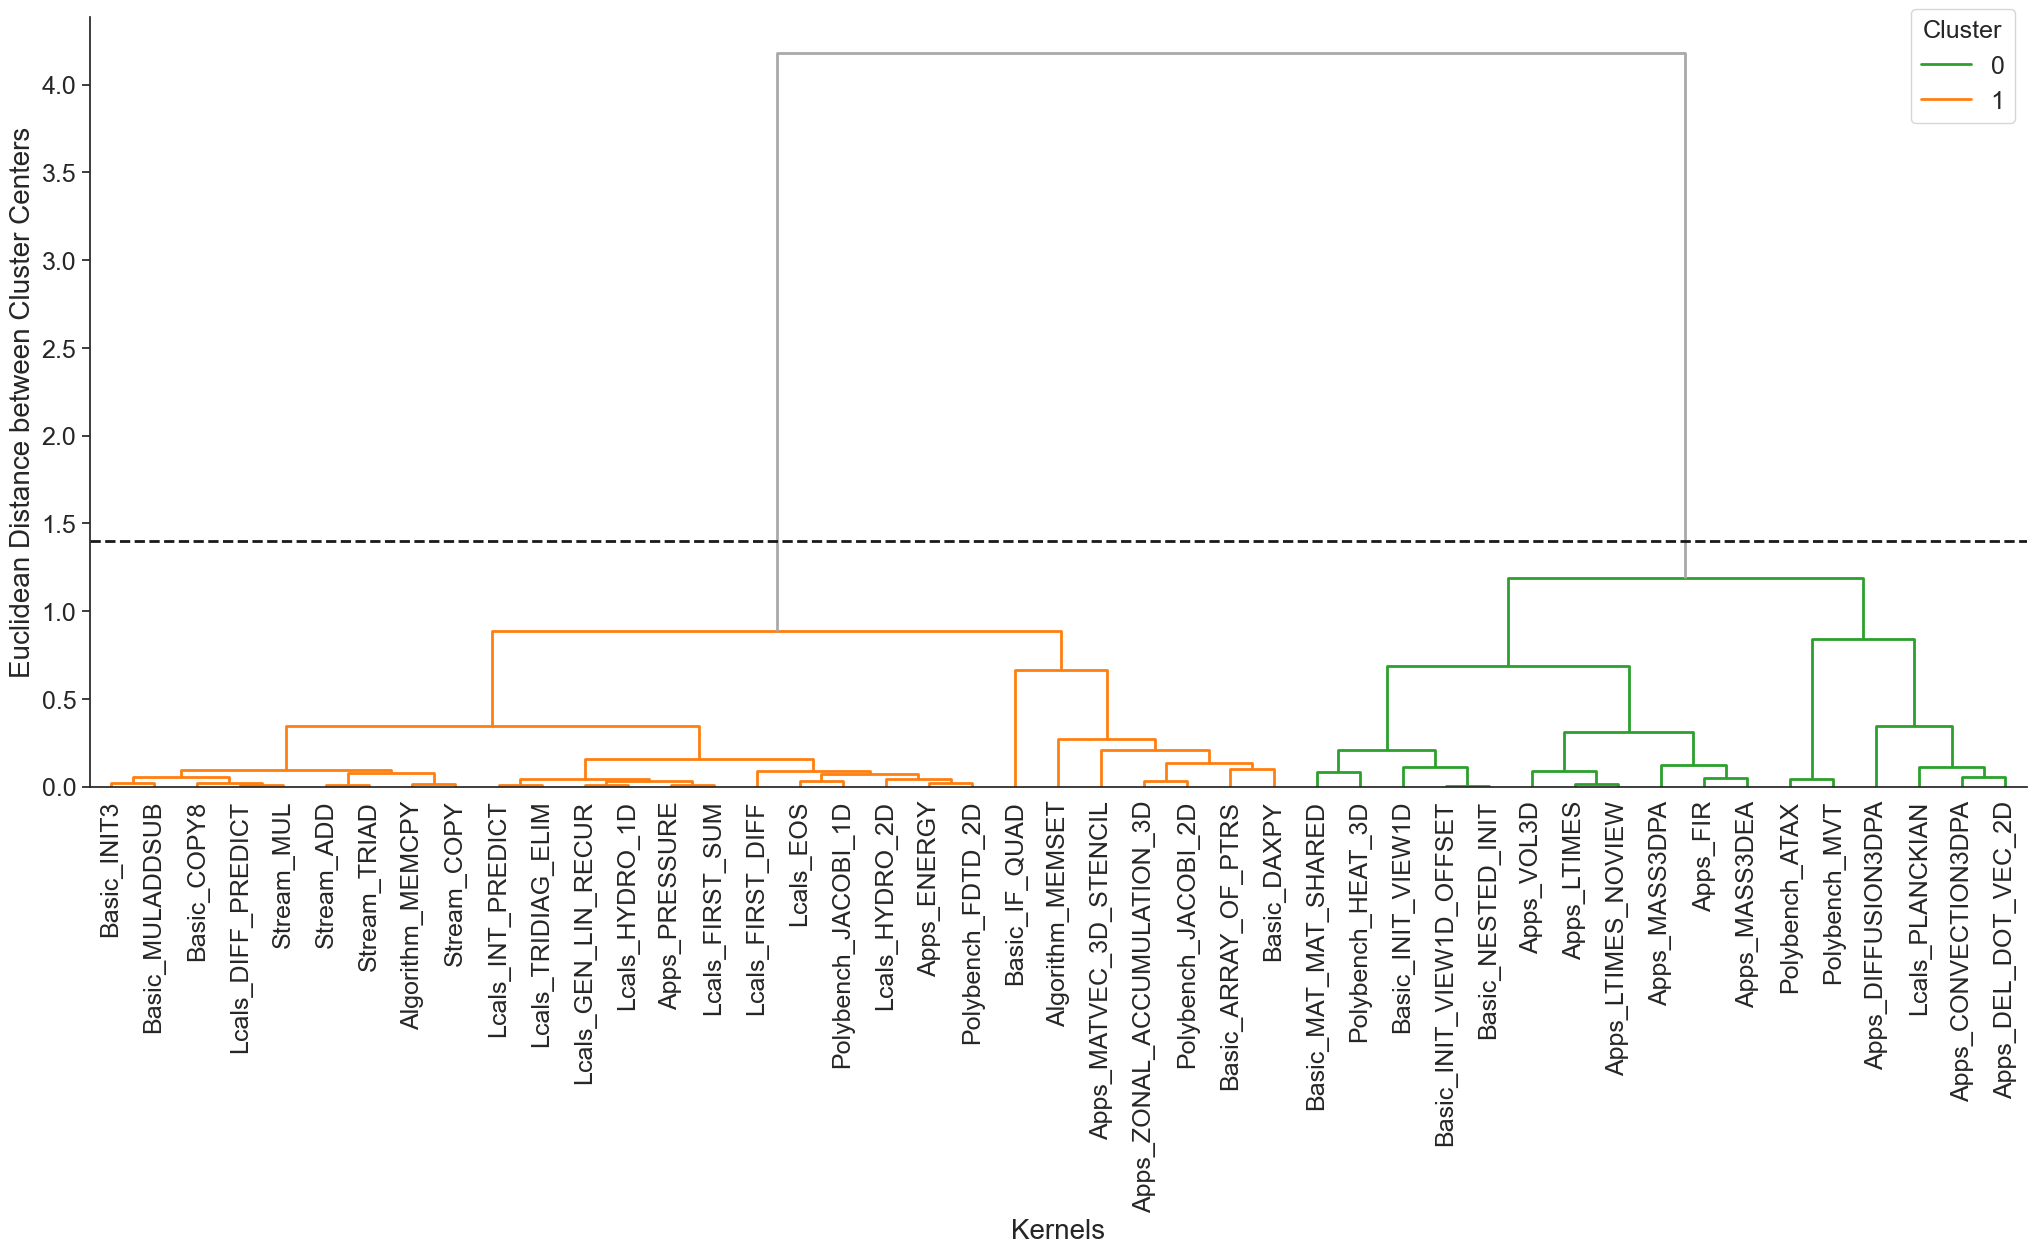

In [45]:
dendro_fig, dendro_ax = plt.subplots(figsize=(25, 10))

with plt.rc_context({"lines.linewidth": 2}):
    dendro_dict = plot_dendrogram(
        cluster_op,
        ax=dendro_ax,
        color_threshold=thresh,
        labels=th.statsframe.dataframe["name"],
        above_threshold_color="darkgray",
    )

    dendro_colors = {th.statsframe.dataframe[("label", "")].iloc[l]: c for l, c in zip(dendro_dict["leaves"], dendro_dict["leaves_color_list"])}
    dendro_labels = list(sorted([l for l in dendro_colors.keys()]))
    dendro_handles = []
    for label in dendro_labels:
        dendro_handles.append(plt.Line2D([0], [0], color=dendro_colors[label]))

    dendro_fig.legend(
        dendro_handles,
        dendro_labels,
        title="Cluster",
        loc="upper right",
        bbox_to_anchor=(0.9, 0.9),
        title_fontsize=18,
        fontsize=18,
    )
    dendro_ax.axhline(thresh, color="k", linestyle="--")

dendro_ax.spines[["right", "top"]].set_visible(False)
dendro_ax.set_ylabel("Euclidean Distance between Cluster Centers", fontsize=20)
dendro_ax.set_xlabel("Kernels", fontsize=20)
dendro_ax.tick_params(axis="both", which="major", labelsize=18)

#dendro_fig.savefig("figures/clustering_dendrogram.png", bbox_inches="tight", dpi=200)

#### 6.3C Categorical plot showing the makeup of each cluster

In [46]:
tma_metric_dfs = []
for m in ["Retiring", "Frontend Bound", "Bad Speculation", "Core Bound", "Memory Bound"]:
    single_tma_metric_df = cluster_summary_df[["Kernel", m, "Cluster ID"]]
    single_tma_metric_df.rename(columns={m: "TMA Metric"}, inplace=True)
    single_tma_metric_df["type"] = m
    tma_metric_dfs.append(single_tma_metric_df)

clustering_plotting_metric_df = pd.concat(tma_metric_dfs)

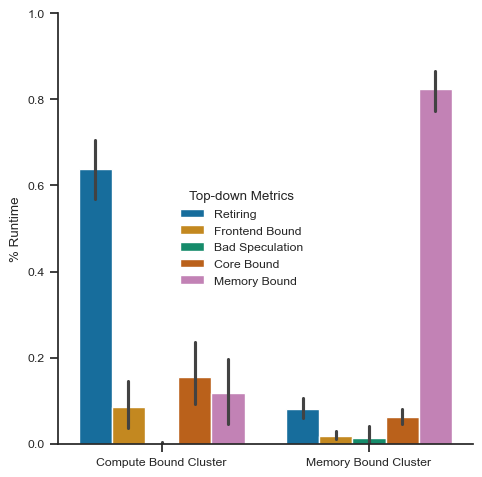

In [47]:
g = sns.catplot(
    data=clustering_plotting_metric_df,
    x="Cluster ID",
    y="TMA Metric",
    hue="type",
    kind="bar",
    palette="colorblind",
)
g.set_axis_labels("", "% Runtime")
g.set(ylim=(0, 1))
g.set_xticklabels(["Compute Bound Cluster", "Memory Bound Cluster"])
g.legend.set_loc("center")
g.legend.set_title("Top-down Metrics")

g.savefig("new_top_metrics_o_n.png")


In [48]:
# Grab just the relevant metrics from above  and flatten for parallel coordinate plots
relevant_metrics_df = th.statsframe.dataframe[[
    "name",
    ddr_fe_bound_mean,
    ddr_bad_spec_mean,
    ddr_retiring_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean,
    ddr_to_hbm_speedup,
    ddr_to_v100_speedup,
    ddr_to_a100_speedup,
    ddr_to_gh200_speedup,
    ddr_to_mi250x_speedup,
    ddr_to_mi300a_speedup,
    ("label", ""),
]].copy(deep=True)
relevant_metrics_df.columns = relevant_metrics_df.columns.to_flat_index()
relevant_metrics_df.rename(
    columns={
        "name": "Kernel",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
        ddr_to_hbm_speedup: "Speedup on SPR-HBM",
        ddr_to_v100_speedup: "Speedup on P9-V100",
        ddr_to_a100_speedup: "Speedup on CAS-A100",
        ddr_to_gh200_speedup: "Speedup on GR-GH200",
        ddr_to_mi250x_speedup: "Speedup on EPYC-MI250X",
        ddr_to_mi300a_speedup: "Speedup on MI300A",
        ("label", ""): "Cluster ID",
    },
    inplace=True,
)
relevant_metrics_df.reset_index(inplace=True, drop=True)
relevant_metrics_df.sort_values(by="Kernel", inplace=True)
relevant_metrics_df

,Kernel,Frontend Bound,Bad Speculation,Retiring,Core Bound,Memory Bound,Speedup on SPR-HBM,Speedup on P9-V100,Speedup on CAS-A100,Speedup on GR-GH200,Speedup on EPYC-MI250X,Speedup on MI300A,Cluster ID
0,Algorithm_MEMCPY,0.036830,0.000045,0.034130,0.006275,0.922720,3.386796,6.473918,5.359793,6.747813,21.017597,30.536256,1
1,Algorithm_MEMSET,0.052811,0.000090,0.299764,0.000392,0.646944,1.023321,1.166566,1.000265,1.097503,3.588471,4.062968,1
2,Apps_CONVECTION3DPA,0.007797,0.000067,0.408572,0.139597,0.443966,1.301700,6.262460,4.094343,3.632800,9.859156,11.631762,0
3,Apps_DEL_DOT_VEC_2D,0.007751,0.000086,0.363637,0.165752,0.462774,1.562515,7.980201,6.586540,8.275382,17.913766,19.563365,0
4,Apps_DIFFUSION3DPA,0.008966,0.000057,0.628482,0.098862,0.263633,0.972539,8.371183,6.375029,5.886129,23.669824,22.257460,0
5,Apps_ENERGY,0.004241,0.000072,0.071007,0.091015,0.833665,2.216925,7.122768,6.091414,8.042887,20.511563,26.917540,1
6,Apps_FIR,0.007371,0.000081,0.721853,0.259318,0.011377,0.887608,8.114739,5.538746,6.602458,10.321326,12.562827,0
7,Apps_LTIMES,0.022836,0.012065,0.851766,0.061961,0.051372,0.858390,1.412363,0.920424,0.795273,2.295889,3.414777,0
8,Apps_LTIMES_NOVIEW,0.011555,0.008100,0.857706,0.063678,0.058963,0.854549,1.397028,0.909689,0.785845,2.269503,3.375551,0
9,Apps_MASS3DEA,0.005020,0.000078,0.760391,0.234118,0.000392,0.862880,13.981073,8.991535,11.846833,3.243761,0.083636,0


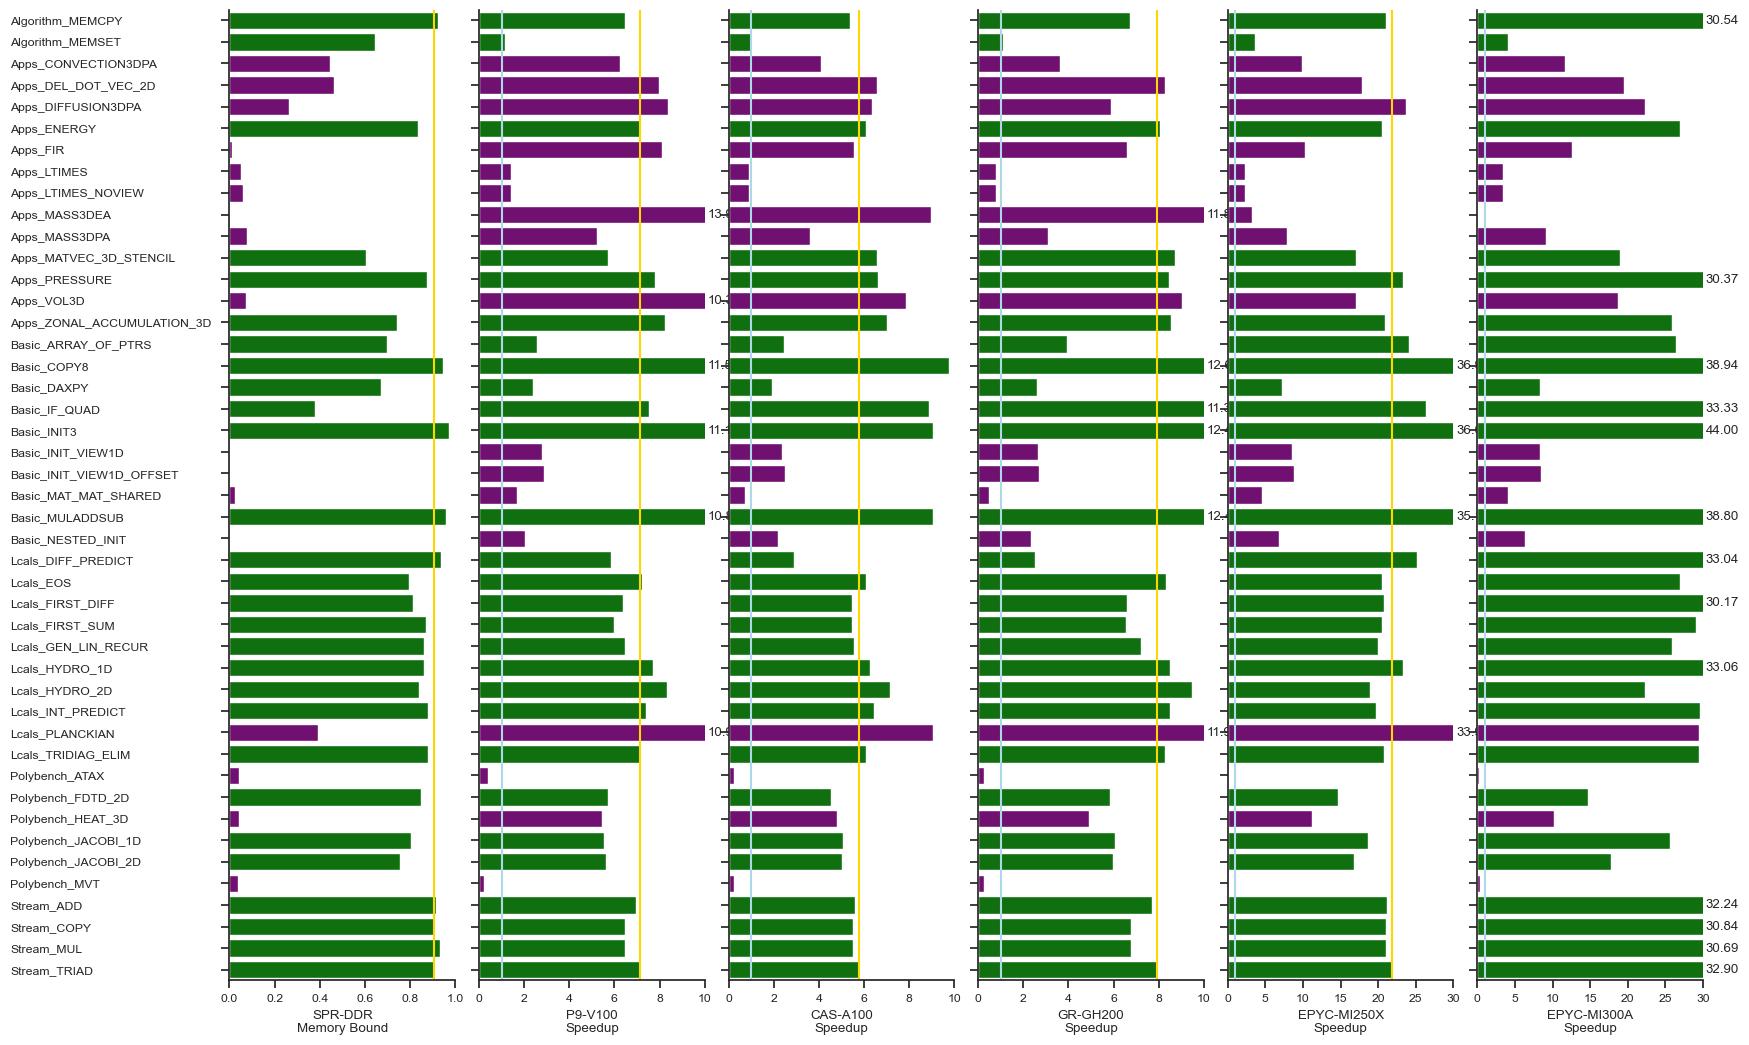

In [49]:
# 0 purple, 1 green, 2 red, 3 orange
triple_plot_df = th.statsframe.dataframe[["name", ddr_mem_bound_mean, ddr_to_v100_speedup, ddr_to_a100_speedup, ddr_to_gh200_speedup, ddr_to_mi250x_speedup, ddr_to_mi300a_speedup]].reset_index(drop=True)
triple_plot_df.reset_index(inplace=True)

triple_plot_df.columns = triple_plot_df.columns.to_flat_index()
triple_plot_df.rename(
    columns={
        "name": "Kernel",
        ddr_mem_bound_mean: "DDR Memory Bound",
        ddr_to_v100_speedup: "V100 Speedup",
        ddr_to_a100_speedup: "A100 Speedup",
        ddr_to_gh200_speedup: "GH200 Speedup",
        ddr_to_mi250x_speedup: "MI250X Speedup",
        ddr_to_mi300a_speedup: "MI300A Speedup",
    },
    inplace=True
)

ddr_stream_copy_mem_bound = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["DDR Memory Bound"].iloc[0]
v100_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["V100 Speedup"].iloc[0]
a100_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["A100 Speedup"].iloc[0]
gh200_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["GH200 Speedup"].iloc[0]
mi250x_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["MI250X Speedup"].iloc[0]
mi300a_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["MI300A Speedup"].iloc[0]

# Set a color palette
sns.set_theme(palette="tab10", font_scale=0.8)
sns.set_style("ticks")
triple_plot_df["color"] = 1
triple_plot_df["Cluster ID"] = relevant_metrics_df["Cluster ID"]

pg_triple = sns.PairGrid(
    data=triple_plot_df,
    y_vars=["Kernel"],
    x_vars=["DDR Memory Bound", "V100 Speedup", "A100 Speedup", "GH200 Speedup", "MI250X Speedup", "MI300A Speedup"],
    despine=True,
    height=10.5,
    aspect=0.25,
    hue="Cluster ID",
    palette=['purple', 'green', 'red', 'darkorange']
)
pg_triple.tight_layout()
pg_triple.map(sns.barplot)
pg_triple.figure.axes[0].set_xlim(0, 1)
pg_triple.figure.axes[0].set_xlabel("SPR-DDR\nMemory Bound")
pg_triple.figure.axes[0].get_yaxis().get_label().set_visible(False)
pg_triple.figure.axes[0].axvline(ddr_stream_copy_mem_bound, color="gold")
pg_triple.figure.axes[1].axvline(1.0, color="lightblue")
pg_triple.figure.axes[1].axvline(v100_stream_copy_spdup, color="gold")
pg_triple.figure.axes[1].set_xlim(0, 10)
pg_triple.figure.axes[1].set_xlabel("P9-V100\nSpeedup")
pg_triple.figure.axes[2].axvline(1.0, color="lightblue")
pg_triple.figure.axes[2].axvline(a100_stream_copy_spdup, color="gold")
pg_triple.figure.axes[2].set_xlim(0, 10)
pg_triple.figure.axes[2].set_xlabel("CAS-A100\nSpeedup")
pg_triple.figure.axes[3].axvline(1.0, color="lightblue")
pg_triple.figure.axes[3].axvline(gh200_stream_copy_spdup, color="gold")
pg_triple.figure.axes[3].set_xlim(0, 10)
pg_triple.figure.axes[3].set_xlabel("GR-GH200\nSpeedup")
pg_triple.figure.axes[4].axvline(1.0, color="lightblue")
pg_triple.figure.axes[4].axvline(mi250x_stream_copy_spdup, color="gold")
pg_triple.figure.axes[4].set_xlim(0, 30)
pg_triple.figure.axes[4].set_xlabel("EPYC-MI250X\nSpeedup")
pg_triple.figure.axes[5].axvline(1.0, color="lightblue")
pg_triple.figure.axes[5].axvline(mi300a_stream_copy_spdup, color="gold")
pg_triple.figure.axes[5].set_xlim(0, 30)
pg_triple.figure.axes[5].set_xlabel("EPYC-MI300A\nSpeedup")

gpu_stream_copy_spdups = {
    "V100": v100_stream_copy_spdup,
    "A100": a100_stream_copy_spdup,
    "GH200": gh200_stream_copy_spdup,
    "MI250X": mi250x_stream_copy_spdup,
    "MI300A": mi300a_stream_copy_spdup,
}

starting_subplot_idx = 1

for i, gpu_type in enumerate(["V100", "A100", "GH200", "MI250X", "MI300A"]):
    for label in pg_triple.figure.axes[0].get_yticklabels():
        _, label_y = label.get_position()
        min_x, max_x = pg_triple.figure.axes[starting_subplot_idx].get_xlim()
        curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["{} Speedup".format(gpu_type)].iloc[0]
        if curr_kernel_speedup > max_x:
            pg_triple.figure.axes[starting_subplot_idx].annotate(
                "{:.2f}".format(curr_kernel_speedup),
                xy=(max_x, label_y),
                xytext=(2, 0),
                textcoords="offset points",
                ha="left",
                va="center",
            )
    starting_subplot_idx+=1

pg_triple_y_ax = pg_triple.figure.axes[0].get_yaxis()
pg_triple_y_ax.set_tick_params(pad=152)
for tick in pg_triple_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")
    
pg_triple.savefig("mi300a_diffX.png") 

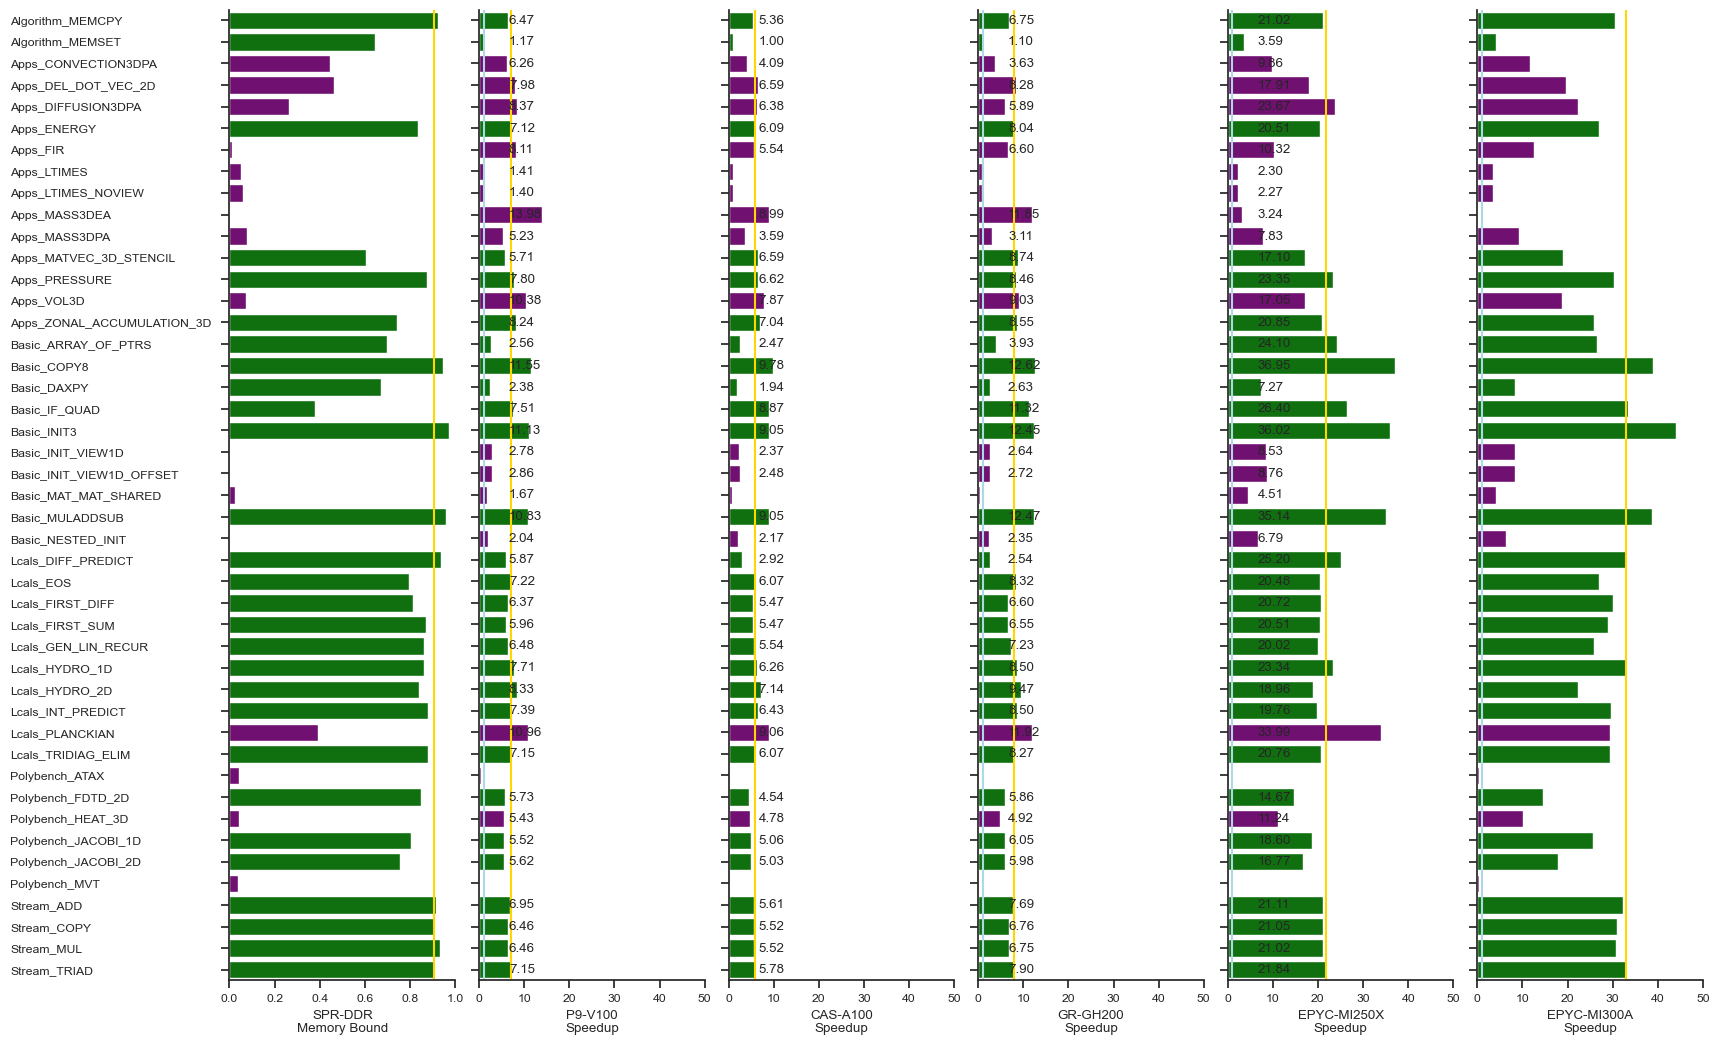

In [50]:
# 0 purple, 1 green, 2 red, 3 orange
triple_plot_df = th.statsframe.dataframe[["name", ddr_mem_bound_mean, ddr_to_hbm_speedup, ddr_to_v100_speedup, ddr_to_a100_speedup, ddr_to_gh200_speedup, ddr_to_mi250x_speedup, ddr_to_mi300a_speedup]].reset_index(drop=True)
triple_plot_df.reset_index(inplace=True)

triple_plot_df.columns = triple_plot_df.columns.to_flat_index()
triple_plot_df.rename(
    columns={
        "name": "Kernel",
        ddr_mem_bound_mean: "DDR Memory Bound",
        ddr_to_hbm_speedup: "SPR-HBM Speedup",
        ddr_to_v100_speedup: "V100 Speedup",
        ddr_to_a100_speedup: "A100 Speedup",
        ddr_to_gh200_speedup: "GH200 Speedup",
        ddr_to_mi250x_speedup: "MI250X Speedup",
        ddr_to_mi300a_speedup: "MI300A Speedup",
    },
    inplace=True
)

ddr_stream_copy_mem_bound = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["DDR Memory Bound"].iloc[0]
v100_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["V100 Speedup"].iloc[0]
a100_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["A100 Speedup"].iloc[0]
gh200_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["GH200 Speedup"].iloc[0]
mi250x_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["MI250X Speedup"].iloc[0]
mi300a_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["MI300A Speedup"].iloc[0]

# Set a color palette
sns.set_theme(palette="tab10", font_scale=0.8)
sns.set_style("ticks")
triple_plot_df["color"] = 1
triple_plot_df["Cluster ID"] = relevant_metrics_df["Cluster ID"]

pg_triple = sns.PairGrid(
    data=triple_plot_df,
    y_vars=["Kernel"],
    x_vars=["DDR Memory Bound", "V100 Speedup", "A100 Speedup", "GH200 Speedup", "MI250X Speedup", "MI300A Speedup"],
    despine=True,
    height=10.5,
    aspect=0.25,
    hue="Cluster ID",
    palette=['purple', 'green', 'red', 'darkorange']
)
pg_triple.tight_layout()
pg_triple.map(sns.barplot)
pg_triple.figure.axes[0].set_xlim(0, 1)
pg_triple.figure.axes[0].set_xlabel("SPR-DDR\nMemory Bound")
pg_triple.figure.axes[0].get_yaxis().get_label().set_visible(False)
pg_triple.figure.axes[0].axvline(ddr_stream_copy_mem_bound, color="gold")
pg_triple.figure.axes[1].axvline(1.0, color="lightblue")
pg_triple.figure.axes[1].axvline(v100_stream_copy_spdup, color="gold")
pg_triple.figure.axes[1].set_xlim(0, 50)
pg_triple.figure.axes[1].set_xlabel("P9-V100\nSpeedup")
pg_triple.figure.axes[2].axvline(a100_stream_copy_spdup, color="gold")
pg_triple.figure.axes[2].set_xlim(0, 50)
pg_triple.figure.axes[2].set_xlabel("CAS-A100\nSpeedup")
pg_triple.figure.axes[3].axvline(1.0, color="lightblue")
pg_triple.figure.axes[3].axvline(gh200_stream_copy_spdup, color="gold")
pg_triple.figure.axes[3].set_xlim(0, 50)
pg_triple.figure.axes[3].set_xlabel("GR-GH200\nSpeedup")
pg_triple.figure.axes[4].axvline(1.0, color="lightblue")
pg_triple.figure.axes[4].axvline(mi250x_stream_copy_spdup, color="gold")
pg_triple.figure.axes[4].set_xlim(0, 50)
pg_triple.figure.axes[4].set_xlabel("EPYC-MI250X\nSpeedup")
pg_triple.figure.axes[5].axvline(1.0, color="lightblue")
pg_triple.figure.axes[5].axvline(mi300a_stream_copy_spdup, color="gold")
pg_triple.figure.axes[5].set_xlim(0, 50)
pg_triple.figure.axes[5].set_xlabel("EPYC-MI300A\nSpeedup")

gpu_stream_copy_spdups = {
    "V100": v100_stream_copy_spdup,
    "A100": a100_stream_copy_spdup,
    "GH200": gh200_stream_copy_spdup,
    "MI250X": mi250x_stream_copy_spdup,
    "MI300A": mi300a_stream_copy_spdup,
}

starting_subplot_idx = 1

for i, gpu_type in enumerate(["V100", "A100", "GH200", "MI250X"]):
    for label in pg_triple.figure.axes[0].get_yticklabels():
        _, label_y = label.get_position()
        curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["{} Speedup".format(gpu_type)].iloc[0]
        if curr_kernel_speedup > 1:
            pg_triple.figure.axes[starting_subplot_idx].annotate(
                "{:.2f}".format(curr_kernel_speedup),
                xy=(2, label_y),
                xytext=(15, 0),
                textcoords="offset points",
                ha="left",
                va="center",
            )
    starting_subplot_idx+=1

# starting_subplot_idx = 3
for label in pg_triple.figure.axes[0].get_yticklabels():
    _, label_y = label.get_position()
    min_x, max_x = pg_triple.figure.axes[starting_subplot_idx].get_xlim()
    curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["MI300A Speedup"].iloc[0]
    if curr_kernel_speedup > max_x:
        pg_triple.figure.axes[starting_subplot_idx].annotate(
            "{:.2f}".format(curr_kernel_speedup),
            xy=(max_x, label_y),
            xytext=(2, 0),
            textcoords="offset points",
            ha="left",
            va="center",
        )

pg_triple_y_ax = pg_triple.figure.axes[0].get_yaxis()
pg_triple_y_ax.set_tick_params(pad=152)
for tick in pg_triple_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")
    
pg_triple.savefig("mi300a_sameX.png") 

# Boxplots of heatmap summary for FLOPS and Bandwidth

In [51]:
baseline_bw_df = mem_v_flop_df.reset_index()[mem_v_flop_df["name"].isin(["Basic_MAT_MAT_SHARED", "Stream_TRIAD"])][[
    "name",
    ("ddr", "Memory Bandwidth (GB/sec)_mean"), 
    ("hbm", "Memory Bandwidth (GB/sec)_mean"),
    ("v100", "Memory Bandwidth (GB/sec)_mean"),
    ("a100", "Memory Bandwidth (GB/sec)_mean"), 
    ("gh200", "Memory Bandwidth (GB/sec)_mean"), 
    ("mi250x", "Memory Bandwidth (GB/sec)_mean"),
    ("mi300a", "Memory Bandwidth (GB/sec)_mean"), 
    ]]

baseline_bw_df.columns = [' '.join(col).strip() for col in baseline_bw_df.columns.values]
baseline_bw_df.rename(columns={"n a m e": "name", "ddr Memory Bandwidth (GB/sec)_mean": "SPR-DDR", "hbm Memory Bandwidth (GB/sec)_mean": "SPR-HBM",
                              "v100 Memory Bandwidth (GB/sec)_mean": "4xV100", "a100 Memory Bandwidth (GB/sec)_mean": "2xA100",
                             "gh200 Memory Bandwidth (GB/sec)_mean": "1xGH200", "mi250x Memory Bandwidth (GB/sec)_mean": "8xMI250X",
                             "mi300a Memory Bandwidth (GB/sec)_mean": "4xMI300A"}, inplace=True)
baseline_bw_df = baseline_bw_df.melt(id_vars=["name"], var_name="Architecture", value_name="Achieved Memory Bandwidth (GB/s)")
baseline_bw_df

,name,Architecture,Achieved Memory Bandwidth (GB/s)
0,Basic_MAT_MAT_SHARED,SPR-DDR,17.285416
1,Stream_TRIAD,SPR-DDR,466.066593
2,Basic_MAT_MAT_SHARED,SPR-HBM,14.936008
3,Stream_TRIAD,SPR-HBM,1112.878205
4,Basic_MAT_MAT_SHARED,4xV100,28.970831
5,Stream_TRIAD,4xV100,3332.099390
6,Basic_MAT_MAT_SHARED,2xA100,12.432615
7,Stream_TRIAD,2xA100,2694.142161
8,Basic_MAT_MAT_SHARED,1xGH200,7.979309
9,Stream_TRIAD,1xGH200,3684.086500


In [52]:
#sns.set_theme(style='white')
sns.set(font_scale=2, style='white')

In [53]:
temp_df = mem_v_flop_df[[
    "name",
    ("ddr", "Memory Bandwidth (GB/sec)_mean"),
    ("hbm", "Memory Bandwidth (GB/sec)_mean"),
    ("v100", "Memory Bandwidth (GB/sec)_mean"),
    ("a100", "Memory Bandwidth (GB/sec)_mean"), 
    ("gh200", "Memory Bandwidth (GB/sec)_mean"),
    ("mi250x", "Memory Bandwidth (GB/sec)_mean"),
    ("mi300a", "Memory Bandwidth (GB/sec)_mean"),
]]
temp_df.set_index("name", inplace=True)
bw_boxplot_df = relevant_metrics_df[["Kernel", "Cluster ID"]].join(temp_df, on="Kernel").drop(columns=["Kernel"])
bw_boxplot_df.columns = [' '.join(col).strip() for col in bw_boxplot_df.columns.values]
bw_boxplot_df.rename(columns={"C l u s t e r   I D": "Cluster ID", "ddr Memory Bandwidth (GB/sec)_mean": "SPR-DDR", "hbm Memory Bandwidth (GB/sec)_mean": "SPR-HBM",
                              "v100 Memory Bandwidth (GB/sec)_mean": "4xV100", "a100 Memory Bandwidth (GB/sec)_mean": "2xA100",
                             "gh200 Memory Bandwidth (GB/sec)_mean": "1xGH200", "mi250x Memory Bandwidth (GB/sec)_mean": "8xMI250X",
                             "mi300a Memory Bandwidth (GB/sec)_mean": "4xMI300A"}, inplace=True)
bw_boxplot_df = bw_boxplot_df.melt(id_vars=["Cluster ID"], var_name="Architecture", value_name="Achieved Memory Bandwidth (GB/s)")
bw_boxplot_df

,Cluster ID,Architecture,Achieved Memory Bandwidth (GB/s)
0,1,SPR-DDR,492.139527
1,1,SPR-DDR,2967.769980
2,0,SPR-DDR,413.507972
3,0,SPR-DDR,389.174360
4,0,SPR-DDR,333.120336
...,...,...,...
310,0,4xMI300A,426.334270
311,1,4xMI300A,15452.392191
312,1,4xMI300A,15253.346803
313,1,4xMI300A,15165.115319


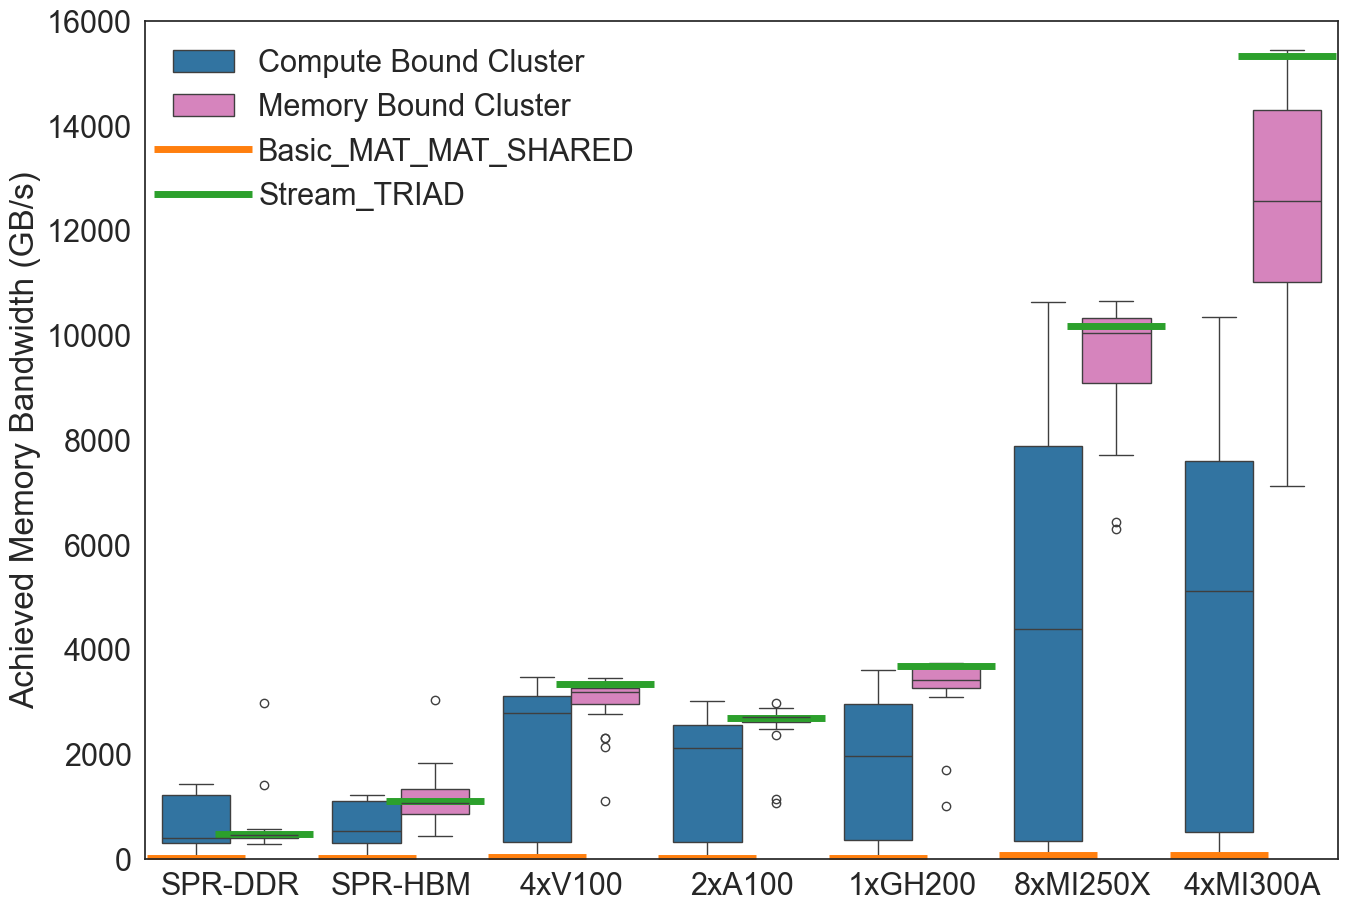

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

sns.boxplot(
    data=bw_boxplot_df,
    x="Architecture",
    y="Achieved Memory Bandwidth (GB/s)",
    hue="Cluster ID",
    ax=ax,
    palette=["tab:blue", "tab:pink"]
)
sns.pointplot(
    data=baseline_bw_df, 
    x="Architecture", 
    y="Achieved Memory Bandwidth (GB/s)",
    hue="name",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=70, markeredgewidth=5,
    palette=["tab:orange", "tab:green"],
    legend=True
)
#plt.axhline(1.0, linestyle="--", color="red", label="y = 1")
handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Compute Bound Cluster", "Memory Bound Cluster", "Basic_MAT_MAT_SHARED", "Stream_TRIAD"], title="", loc="upper left", frameon=False)
plt.ylim(0,16000)
plt.tight_layout()
plt.xlabel("")
plt.savefig("bw_clusters.png")
plt.show()

In [55]:
baseline_flops_df = mem_v_flop_df.reset_index()[mem_v_flop_df["name"].isin(["Basic_MAT_MAT_SHARED", "Stream_TRIAD"])][[
    "name",
    ("ddr", "FLOP rate (GFLOPS)_mean"),
    ("hbm", "FLOP rate (GFLOPS)_mean"),
    ("v100", "FLOP rate (GFLOPS)_mean"),
    ("a100", "FLOP rate (GFLOPS)_mean"),
    ("gh200", "FLOP rate (GFLOPS)_mean"),
    ("mi250x", "FLOP rate (GFLOPS)_mean"), 
    ("mi300a", "FLOP rate (GFLOPS)_mean"), 
    ]]
baseline_flops_df.columns = [' '.join(col).strip() for col in baseline_flops_df.columns.values]
baseline_flops_df.rename(columns={"n a m e": "name", "ddr FLOP rate (GFLOPS)_mean": "SPR-DDR", "hbm FLOP rate (GFLOPS)_mean": "SPR-HBM",
                              "v100 FLOP rate (GFLOPS)_mean": "4xV100", "a100 FLOP rate (GFLOPS)_mean": "2xA100",
                             "gh200 FLOP rate (GFLOPS)_mean": "1xGH200", "mi250x FLOP rate (GFLOPS)_mean": "8xMI250X",
                             "mi300a FLOP rate (GFLOPS)_mean": "4xMI300A"}, inplace=True)
baseline_flops_df = baseline_flops_df.melt(id_vars=["name"], var_name="Architecture", value_name="Achieved FLOP Rate (GFLOPS)")
baseline_flops_df

,name,Architecture,Achieved FLOP Rate (GFLOPS)
0,Basic_MAT_MAT_SHARED,SPR-DDR,845.450183
1,Stream_TRIAD,SPR-DDR,38.838883
2,Basic_MAT_MAT_SHARED,SPR-HBM,730.537849
3,Stream_TRIAD,SPR-HBM,92.739850
4,Basic_MAT_MAT_SHARED,4xV100,6991.627316
5,Stream_TRIAD,4xV100,277.674949
6,Basic_MAT_MAT_SHARED,2xA100,4243.669206
7,Stream_TRIAD,2xA100,224.511735
8,Basic_MAT_MAT_SHARED,1xGH200,3882.011139
9,Stream_TRIAD,1xGH200,307.007208


In [56]:
temp_df = mem_v_flop_df[[
    "name",
    ("ddr", "FLOP rate (GFLOPS)_mean"),
    ("hbm", "FLOP rate (GFLOPS)_mean"),
    ("v100", "FLOP rate (GFLOPS)_mean"),
    ("a100", "FLOP rate (GFLOPS)_mean"),
    ("gh200", "FLOP rate (GFLOPS)_mean"),
    ("mi250x", "FLOP rate (GFLOPS)_mean"),
    ("mi300a", "FLOP rate (GFLOPS)_mean"),
    ]]
temp_df.set_index("name", inplace=True)
flops_boxplot_df = relevant_metrics_df[["Kernel", "Cluster ID"]].join(temp_df, on="Kernel").drop(columns=["Kernel"])
flops_boxplot_df.columns = [' '.join(col).strip() for col in flops_boxplot_df.columns.values]
flops_boxplot_df.rename(columns={"C l u s t e r   I D": "Cluster ID", "ddr FLOP rate (GFLOPS)_mean": "SPR-DDR", "hbm FLOP rate (GFLOPS)_mean": "SPR-HBM",
                              "v100 FLOP rate (GFLOPS)_mean": "4xV100", "a100 FLOP rate (GFLOPS)_mean": "2xA100",
                             "gh200 FLOP rate (GFLOPS)_mean": "1xGH200", "mi250x FLOP rate (GFLOPS)_mean": "8xMI250X",
                             "mi300a FLOP rate (GFLOPS)_mean": "4xMI300A"}, inplace=True)
flops_boxplot_df = flops_boxplot_df.melt(id_vars=["Cluster ID"], var_name="Architecture", value_name="Achieved FLOP Rate (GFLOPS)")
flops_boxplot_df

,Cluster ID,Architecture,Achieved FLOP Rate (GFLOPS)
0,1,SPR-DDR,0.000000
1,1,SPR-DDR,0.000000
2,0,SPR-DDR,763.359194
3,0,SPR-DDR,436.755574
4,0,SPR-DDR,632.653018
...,...,...,...
310,0,4xMI300A,106.473169
311,1,4xMI300A,643.848843
312,1,4xMI300A,0.000000
313,1,4xMI300A,947.819425


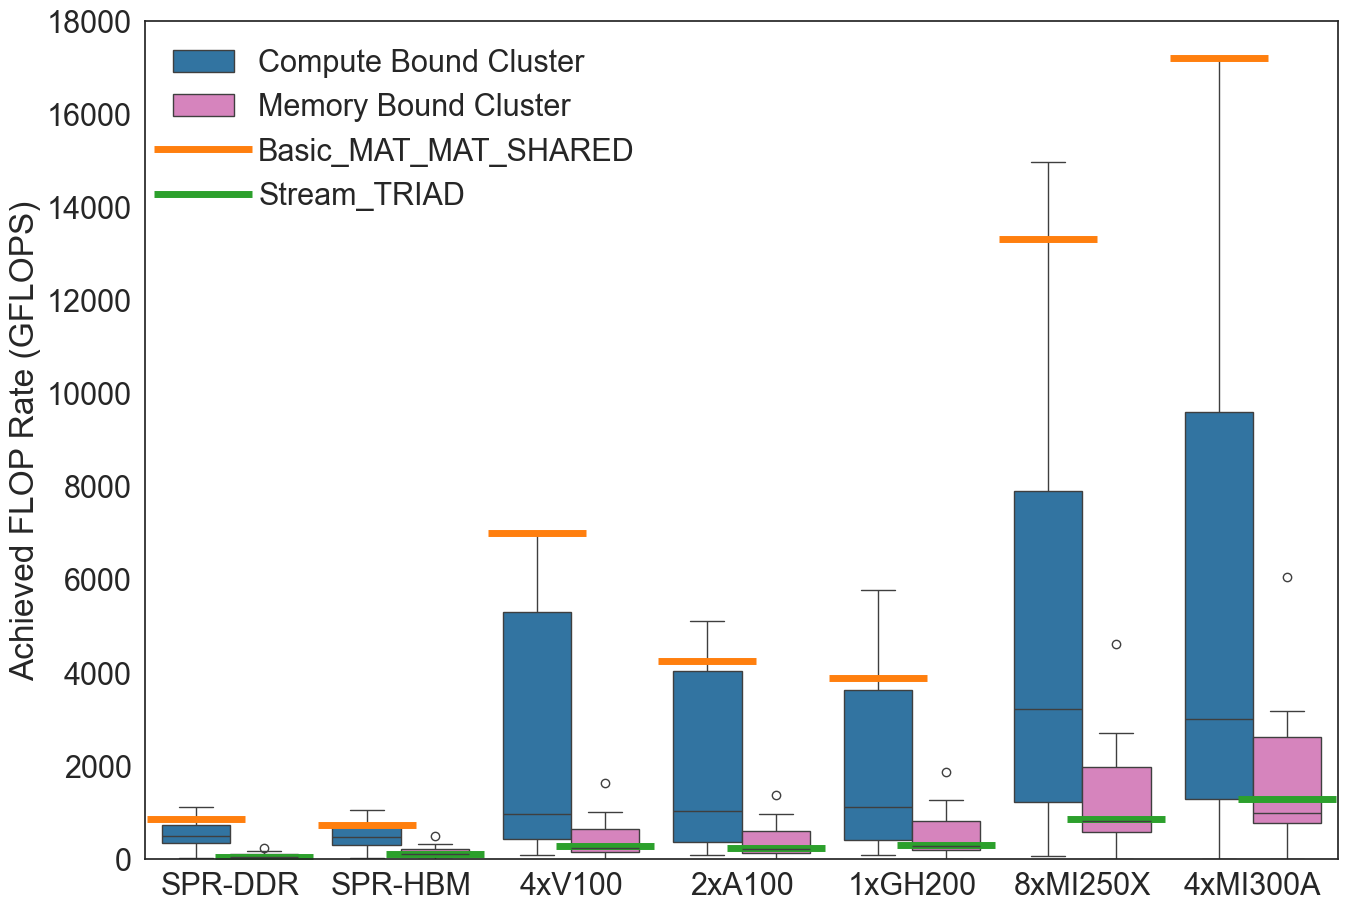

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
sns.boxplot(
    data=flops_boxplot_df,
    x="Architecture",
    y="Achieved FLOP Rate (GFLOPS)",
    hue="Cluster ID",
    ax=ax,
    palette=["tab:blue", "tab:pink"]
)
sns.pointplot(
    data=baseline_flops_df, 
    x="Architecture", 
    y="Achieved FLOP Rate (GFLOPS)",
    hue="name",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=70, markeredgewidth=5,
    palette=["tab:orange", "tab:green"],
    legend=True
)
#plt.axhline(1.0, linestyle="--", color="red", label="y = 1")
handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Compute Bound Cluster", "Memory Bound Cluster", "Basic_MAT_MAT_SHARED", "Stream_TRIAD"], title="", loc="upper left", frameon=False)
plt.ylim(0,18000)
plt.tight_layout()
plt.xlabel("")
plt.savefig("flops_clusters.png")
plt.show()

In [58]:
baseline_arch_eff_df_flops = arch_eff_df.reset_index()[arch_eff_df.index.isin(["Basic_MAT_MAT_SHARED", "Stream_TRIAD"])][[
    "name",
    ("ddr", "arch_eff_gflops"),
    ("hbm", "arch_eff_gflops"),
    ("v100", "arch_eff_gflops"),
    ("a100", "arch_eff_gflops"),
    ("gh200", "arch_eff_gflops"),
    ("mi250x", "arch_eff_gflops"), 
    ("mi300a", "arch_eff_gflops"), 
    ]]
baseline_arch_eff_df_flops.columns = [' '.join(col).strip() for col in baseline_arch_eff_df_flops.columns.values]
baseline_arch_eff_df_flops.rename(columns={"n a m e": "name", "ddr arch_eff_gflops": "SPR-DDR", "hbm arch_eff_gflops": "SPR-HBM",
                              "v100 arch_eff_gflops": "4xV100", "a100 arch_eff_gflops": "2xA100",
                             "gh200 arch_eff_gflops": "1xGH200", "mi250x arch_eff_gflops": "8xMI250X",
                             "mi300a arch_eff_gflops": "4xMI300A"}, inplace=True)
baseline_arch_eff_df_flops = baseline_arch_eff_df_flops.melt(id_vars=["name"], var_name="Architecture", value_name="Architectural Efficiency Score")
baseline_arch_eff_df_flops

,name,Architecture,Architectural Efficiency Score
0,Basic_MAT_MAT_SHARED,SPR-DDR,17.988302
1,Stream_TRIAD,SPR-DDR,0.826359
2,Basic_MAT_MAT_SHARED,SPR-HBM,15.543358
3,Stream_TRIAD,SPR-HBM,1.973188
4,Basic_MAT_MAT_SHARED,4xV100,22.409062
5,Stream_TRIAD,4xV100,0.889984
6,Basic_MAT_MAT_SHARED,2xA100,21.874584
7,Stream_TRIAD,2xA100,1.157277
8,Basic_MAT_MAT_SHARED,1xGH200,11.417680
9,Stream_TRIAD,1xGH200,0.902962


In [59]:
baseline_arch_eff_df_bw = arch_eff_df.reset_index()[arch_eff_df.index.isin(["Basic_MAT_MAT_SHARED", "Stream_TRIAD"])][[
    "name",
    ("ddr", "arch_eff_bw_gb"),
    ("hbm", "arch_eff_bw_gb"),
    ("v100", "arch_eff_bw_gb"),
    ("a100", "arch_eff_bw_gb"),
    ("gh200", "arch_eff_bw_gb"),
    ("mi250x", "arch_eff_bw_gb"), 
    ("mi300a", "arch_eff_bw_gb"), 
    ]]
baseline_arch_eff_df_bw.columns = [' '.join(col).strip() for col in baseline_arch_eff_df_bw.columns.values]
baseline_arch_eff_df_bw.rename(columns={"n a m e": "name", "ddr arch_eff_bw_gb": "SPR-DDR", "hbm arch_eff_bw_gb": "SPR-HBM",
                              "v100 arch_eff_bw_gb": "4xV100", "a100 arch_eff_bw_gb": "2xA100",
                             "gh200 arch_eff_bw_gb": "1xGH200", "mi250x arch_eff_bw_gb": "8xMI250X",
                             "mi300a arch_eff_bw_gb": "4xMI300A"}, inplace=True)
baseline_arch_eff_df_bw = baseline_arch_eff_df_bw.melt(id_vars=["name"], var_name="Architecture", value_name="Architectural Efficiency Score")
baseline_arch_eff_df_bw

,name,Architecture,Architectural Efficiency Score
0,Basic_MAT_MAT_SHARED,SPR-DDR,2.880903
1,Stream_TRIAD,SPR-DDR,77.677765
2,Basic_MAT_MAT_SHARED,SPR-HBM,0.452606
3,Stream_TRIAD,SPR-HBM,33.723582
4,Basic_MAT_MAT_SHARED,4xV100,0.804745
5,Stream_TRIAD,4xV100,92.558316
6,Basic_MAT_MAT_SHARED,2xA100,0.388519
7,Stream_TRIAD,2xA100,84.191943
8,Basic_MAT_MAT_SHARED,1xGH200,0.199483
9,Stream_TRIAD,1xGH200,92.102162


In [60]:
arch_eff_boxplot_df = relevant_metrics_df[["Kernel", "Cluster ID"]].join(arch_eff_df, on="Kernel").drop(columns=["Kernel"])
arch_eff_boxplot_df.columns = [' '.join(col).strip() for col in arch_eff_boxplot_df.columns.values]
arch_eff_boxplot_df.rename(columns={"C l u s t e r   I D": "Cluster ID", "ddr arch_eff_gflops": "SPR-DDR", "hbm arch_eff_gflops": "SPR-HBM",
                              "v100 arch_eff_gflops": "4xV100", "a100 arch_eff_gflops": "2xA100",
                             "gh200 arch_eff_gflops": "1xGH200", "mi250x arch_eff_gflops": "8xMI250X",
                             "mi300a arch_eff_gflops": "4xMI300A", "ddr arch_eff_bw_gb": "SPR-DDR", "hbm arch_eff_bw_gb": "SPR-HBM",
                              "v100 arch_eff_bw_gb": "4xV100", "a100 arch_eff_bw_gb": "2xA100",
                             "gh200 arch_eff_bw_gb": "1xGH200", "mi250x arch_eff_bw_gb": "8xMI250X",
                             "mi300a arch_eff_bw_gb": "4xMI300A"}, inplace=True)
arch_eff_boxplot_df = arch_eff_boxplot_df.melt(id_vars=["Cluster ID"], var_name="Architecture", value_name="Architectural Efficiency Score")
arch_eff_boxplot_df

,Cluster ID,Architecture,Architectural Efficiency Score
0,1,SPR-DDR,0.000000
1,1,SPR-DDR,0.000000
2,0,SPR-DDR,16.241685
3,0,SPR-DDR,9.292672
4,0,SPR-DDR,13.460703
...,...,...,...
625,0,4xMI300A,2.011011
626,1,4xMI300A,72.888642
627,1,4xMI300A,71.949749
628,1,4xMI300A,71.533563


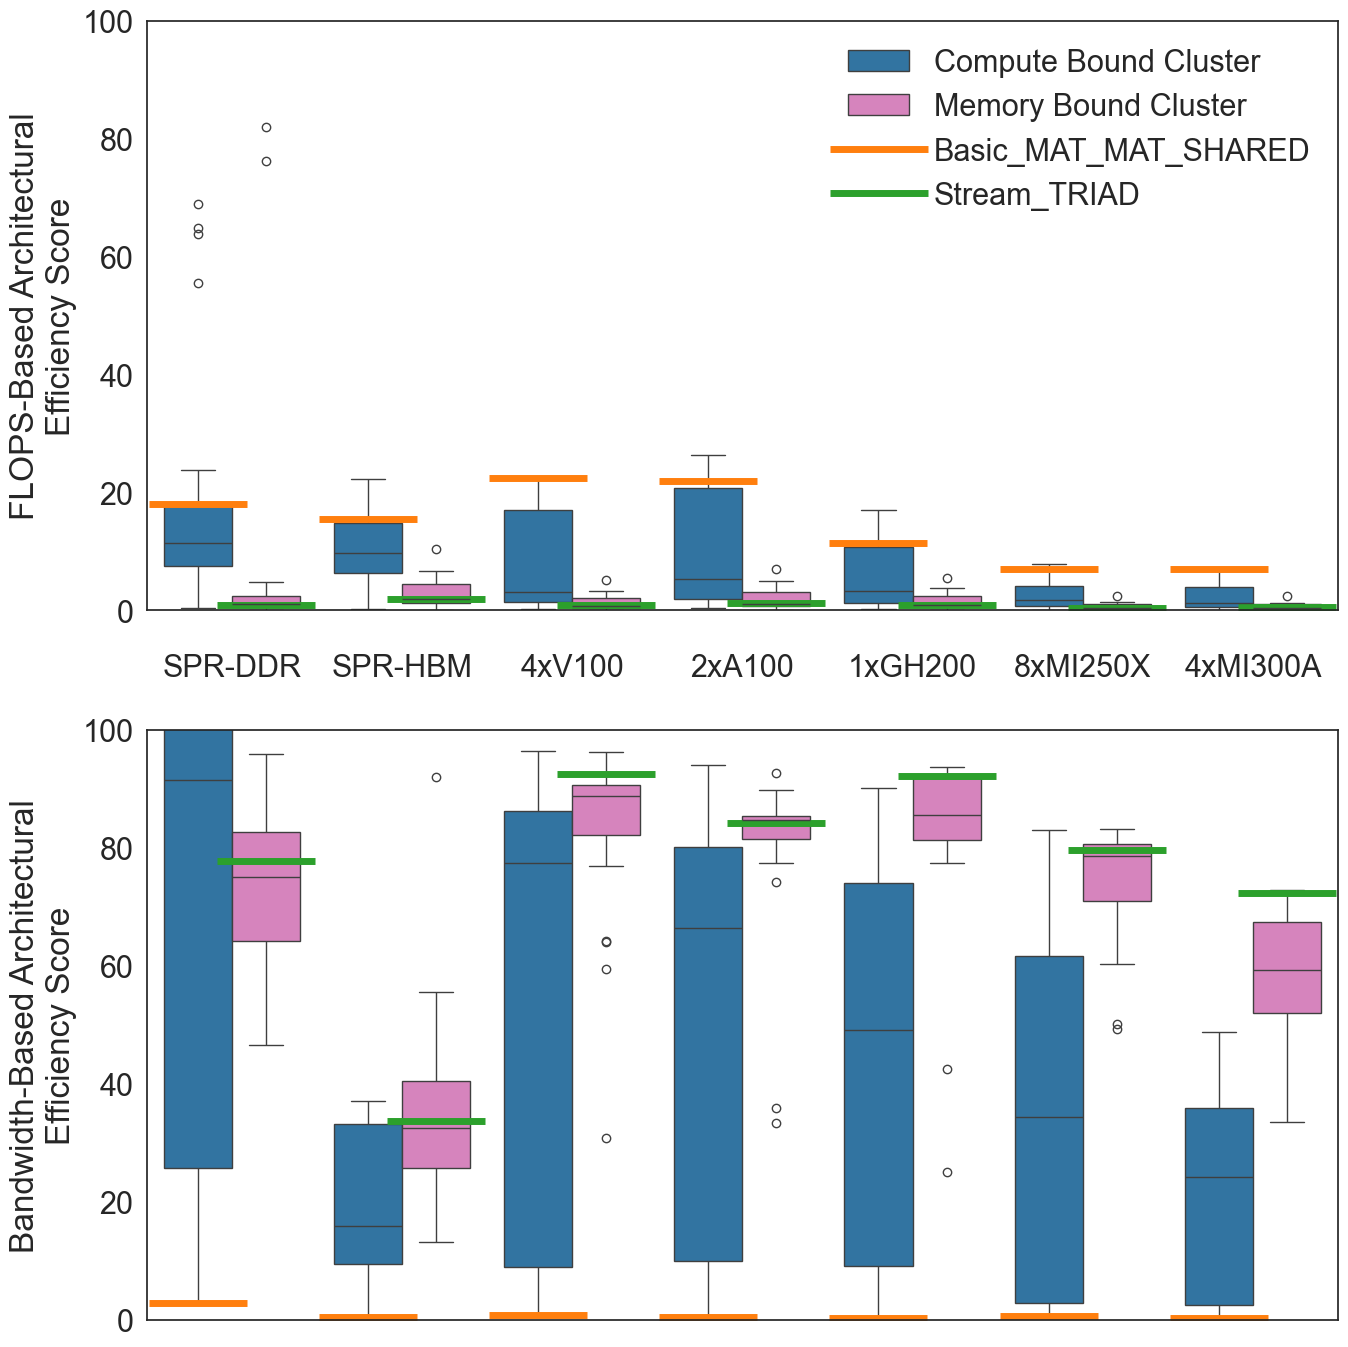

In [61]:
fig, ax = plt.subplots(2, 1, figsize=(14, 14))

xticklabels = ["SPR-DDR", "SPR-HBM", "4xV100", "2xA100", "1xGH200", "8xMI250X", "4xMI300A",]
ax0 = sns.boxplot(
    data=arch_eff_boxplot_df[0:322],
    x="Architecture",
    y="Architectural Efficiency Score",
    hue="Cluster ID",
    ax=ax[0],
    palette=["tab:blue", "tab:pink"]
)
sns.pointplot(
    ax=ax0,
    data=baseline_arch_eff_df_flops, 
    x="Architecture", 
    y="Architectural Efficiency Score",
    hue="name",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=70, markeredgewidth=5,
    palette=["tab:orange", "tab:green"],
    legend=True
)
ax1 = sns.boxplot(
    data=arch_eff_boxplot_df[322:644],
    x="Architecture",
    y="Architectural Efficiency Score",
    hue="Cluster ID",
    ax=ax[1],
    palette=["tab:blue", "tab:pink"],
)
sns.pointplot(
    ax=ax1,
    data=baseline_arch_eff_df_bw, 
    x="Architecture", 
    y="Architectural Efficiency Score",
    hue="name",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=70, markeredgewidth=5,
    palette=["tab:orange", "tab:green"],
    legend=True
)
#plt.axhline(1.0, linestyle="--", color="red", label="y = 1")
ax[0].set_xticklabels(xticklabels)#, rotation=90)
ax[1].set_xticks([])
ax[0].set_xlabel("")
ax[1].set_xlabel("")
ax[0].set_ylabel("FLOPS-Based Architectural\nEfficiency Score", size=24)
ax[1].set_ylabel("Bandwidth-Based Architectural\nEfficiency Score", size=24)
handles, previous_labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles=handles, labels=["Compute Bound Cluster", "Memory Bound Cluster", "Basic_MAT_MAT_SHARED", "Stream_TRIAD"], title="", frameon=False)
ax[1].get_legend().remove()
ax[0].set_ylim([0,100])
ax[1].set_ylim([0,100])
ax[0].xaxis.set_tick_params(pad=25)
#plt.ylim(0,100)
#plt.xticks(rotation=90)
plt.xlabel("")
plt.tight_layout()
plt.savefig("arch_eff_clusters.png")
plt.show()

In [62]:
baseline_perf_port_df = perf_port_df.reset_index()[perf_port_df.index.isin(["Basic_MAT_MAT_SHARED", "Stream_TRIAD"])][[
    "name",
    "CPU FLOPS", 
    "GPU-Prev FLOPs", 
    "GPU-New FLOPs", 
    "GPU-NV FLOPs", 
    "GPU-AMD FLOPs", 
    "GPU FLOPs", 
    "All FLOPs",
    "CPU BW", 
    "GPU-Prev BW", 
    "GPU-New BW", 
    "GPU-NV BW", 
    "GPU-AMD BW", 
    "GPU BW", 
    "All BW"
    ]]
#baseline_perf_port_df.columns = [' '.join(col).strip() for col in baseline_perf_port_df.columns.values]
#baseline_perf_port_df.rename(columns={"n a m e": "name", "ddr arch_eff_bw_gb": "SPR-DDR", "hbm perf_port_bw_gb": "SPR-HBM",
#                              "v100 perf_port_bw_gb": "4xV100", "a100 perf_port_bw_gb": "2xA100",
#                             "gh200 perf_port_bw_gb": "1xGH200", "mi250x perf_port_bw_gb": "8xMI250X",
#                             "mi300a perf_port_bw_gb": "4xMI300A"}, inplace=True)
baseline_perf_port_df = baseline_perf_port_df.melt(id_vars=["name"], var_name="System Set", value_name="Performance Portability Score")
baseline_perf_port_df

,name,System Set,Performance Portability Score
0,Basic_MAT_MAT_SHARED,CPU FLOPS,16.676694
1,Stream_TRIAD,CPU FLOPS,1.164876
2,Basic_MAT_MAT_SHARED,GPU-Prev FLOPs,12.818330
3,Stream_TRIAD,GPU-Prev FLOPs,0.706737
4,Basic_MAT_MAT_SHARED,GPU-New FLOPs,8.633236
5,Stream_TRIAD,GPU-New FLOPs,0.656149
6,Basic_MAT_MAT_SHARED,GPU-NV FLOPs,16.861186
7,Stream_TRIAD,GPU-NV FLOPs,0.969249
8,Basic_MAT_MAT_SHARED,GPU-AMD FLOPs,6.949771
9,Stream_TRIAD,GPU-AMD FLOPs,0.476444


In [63]:
heatmap_boxplot_df = relevant_metrics_df[["Kernel", "Cluster ID"]].join(perf_port_df, on="Kernel").drop(columns=["Kernel"])
heatmap_boxplot_df = heatmap_boxplot_df.melt(id_vars=["Cluster ID"], var_name="System Set", value_name="Performance Portability Score")
heatmap_boxplot_df

,Cluster ID,System Set,Performance Portability Score
0,1,CPU FLOPS,0.000000
1,1,CPU FLOPS,0.000000
2,0,CPU FLOPS,18.371631
3,0,CPU FLOPS,11.332758
4,0,CPU FLOPS,13.273291
...,...,...,...
625,0,All BW,5.144702
626,1,All BW,68.916336
627,1,All BW,73.720207
628,1,All BW,72.595460


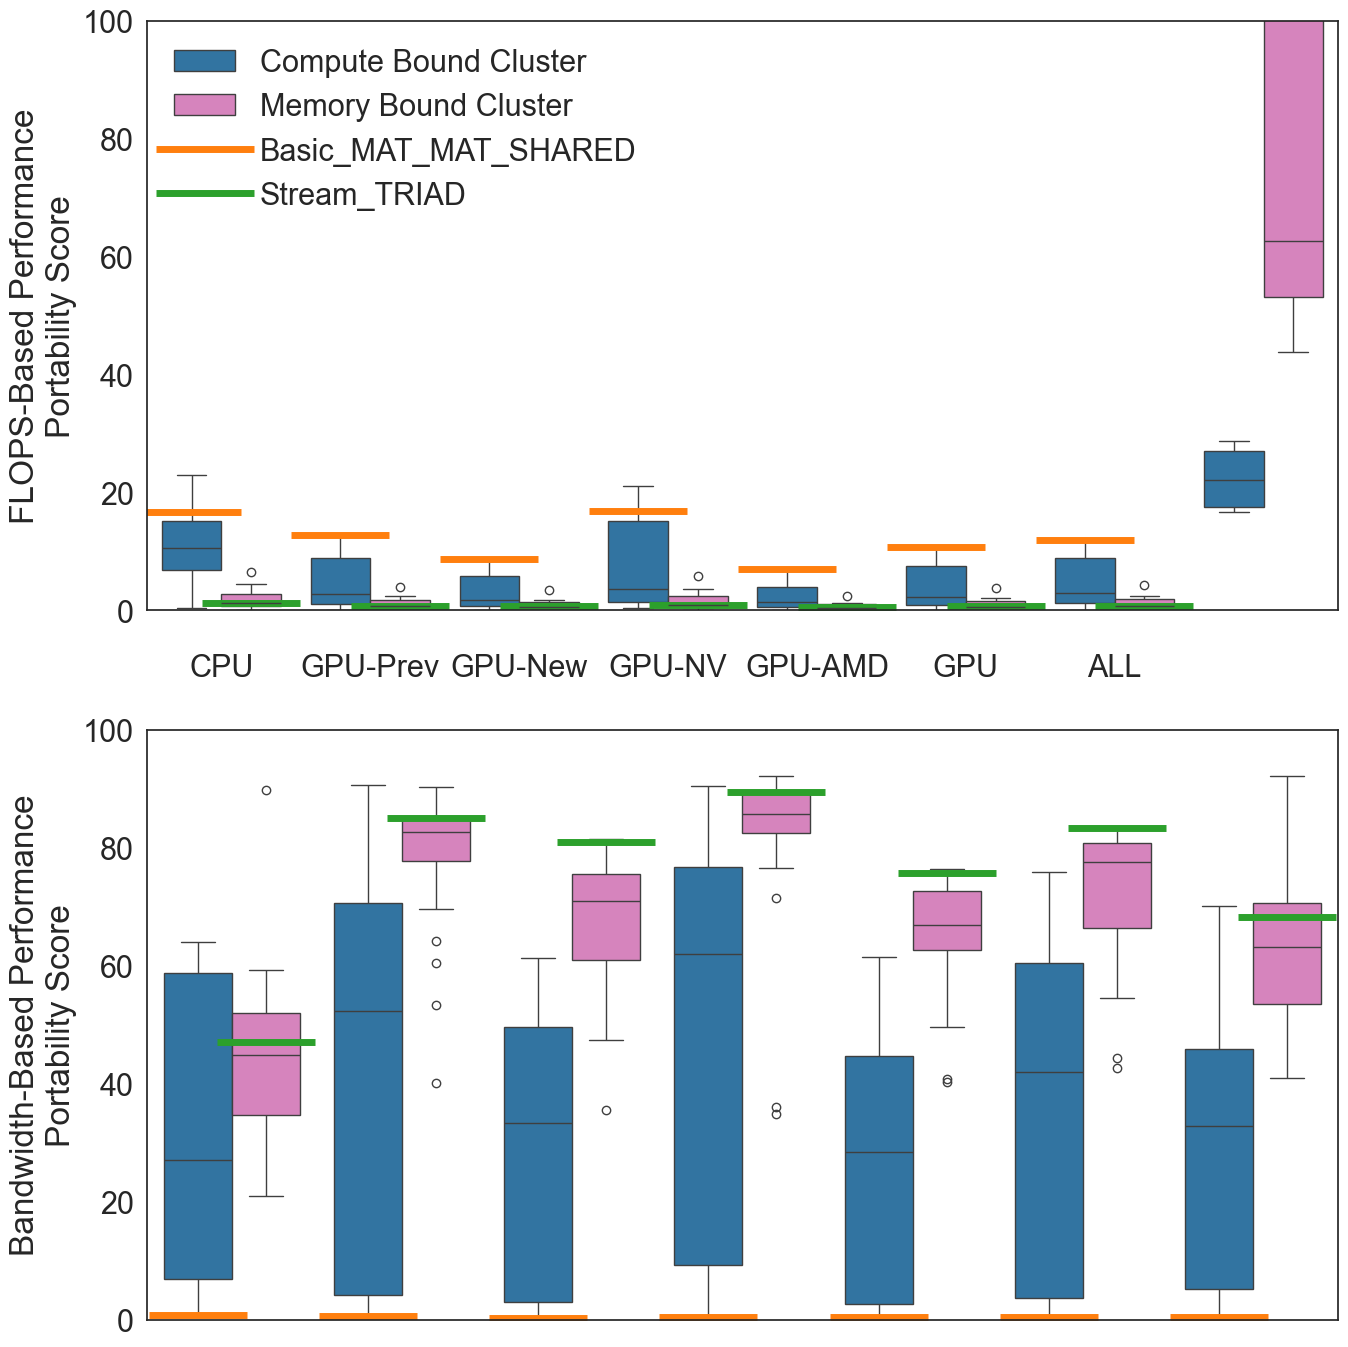

In [64]:
fig, ax = plt.subplots(2, 1, figsize=(14, 14))
xticklabels = ["CPU", "GPU-Prev", "GPU-New", "GPU-NV", "GPU-AMD", "GPU", "ALL",]

ax0 = sns.boxplot(
    data=heatmap_boxplot_df[0:322],
    x="System Set",
    y="Performance Portability Score",
    hue="Cluster ID",
    ax=ax[0],
    palette=["tab:blue", "tab:pink"]
)
sns.pointplot(
    ax=ax0,
    data=baseline_perf_port_df[0:14], 
    x="System Set", 
    y="Performance Portability Score",
    hue="name",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=70, markeredgewidth=5,
    palette=["tab:orange", "tab:green"],
    legend=True
)
ax1 = sns.boxplot(
    data=heatmap_boxplot_df[322:644],
    x="System Set",
    y="Performance Portability Score",
    hue="Cluster ID",
    ax=ax[1],
    palette=["tab:blue", "tab:pink"]
)
sns.pointplot(
    ax=ax1,
    data=baseline_perf_port_df[14:28], 
    x="System Set", 
    y="Performance Portability Score",
    hue="name",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=70, markeredgewidth=5,
    palette=["tab:orange", "tab:green"],
    legend=True
)
ax[0].set_xticklabels(xticklabels)#, rotation=90)
ax[1].set_xticks([])
ax[0].set_xlabel("")
ax[1].set_xlabel("")
ax[0].set_ylabel("FLOPS-Based Performance\nPortability Score", size=24)
ax[1].set_ylabel("Bandwidth-Based Performance\nPortability Score", size=24)
handles, previous_labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles=handles, labels=["Compute Bound Cluster", "Memory Bound Cluster", "Basic_MAT_MAT_SHARED", "Stream_TRIAD"], title="", frameon=False )
ax[1].get_legend().remove()
ax[0].set_ylim([0,100])
ax[1].set_ylim([0,100])
ax[0].xaxis.set_tick_params(pad=25)
plt.tight_layout()
plt.savefig("perf_port_clusters.png")
plt.show()

# Get Percentage of Stream_TRIAD Performance

In [65]:
flop_df = th.statsframe.dataframe.reset_index()[["name", ddr_flop_rate_mean, hbm_flop_rate_mean, v100_flop_rate_mean, a100_flop_rate_mean, gh200_flop_rate_mean, mi250x_flop_rate_mean, mi300a_flop_rate_mean, ("label", "")]]
flop_df = flop_df.rename({
    "name": "Kernel",
    ddr_flop_rate_mean: "SPR-DDR FLOP Rate",
    hbm_flop_rate_mean: "SPR-HBM FLOP Rate",
    v100_flop_rate_mean: "V100 FLOP Rate",
    a100_flop_rate_mean: "A100 FLOP Rate",
    gh200_flop_rate_mean: "GH200 FLOP Rate",
    mi250x_flop_rate_mean: "MI250X FLOP Rate",
    mi300a_flop_rate_mean: "MI300A FLOP Rate",
    ("label", ""): "Cluster ID"
}, axis=1)
for i, gpu_type in enumerate(["SPR-DDR", "SPR-HBM", "V100", "A100", "GH200", "MI250X", "MI300A"]):
    flop_df["{} Percent of Basic_MAT_MAT_SHARED".format(gpu_type)] = flop_df["{} FLOP Rate".format(gpu_type)] / flop_df[flop_df["Kernel"] == "Basic_MAT_MAT_SHARED"]["{} FLOP Rate".format(gpu_type)].iloc[0]
flop_df

,Kernel,SPR-DDR FLOP Rate,SPR-HBM FLOP Rate,V100 FLOP Rate,A100 FLOP Rate,GH200 FLOP Rate,MI250X FLOP Rate,MI300A FLOP Rate,Cluster ID,SPR-DDR Percent of Basic_MAT_MAT_SHARED,SPR-HBM Percent of Basic_MAT_MAT_SHARED,V100 Percent of Basic_MAT_MAT_SHARED,A100 Percent of Basic_MAT_MAT_SHARED,GH200 Percent of Basic_MAT_MAT_SHARED,MI250X Percent of Basic_MAT_MAT_SHARED,MI300A Percent of Basic_MAT_MAT_SHARED
0,Algorithm_MEMCPY,0.000000,0.000000,0.000000,0.000000,0.000000,3.429483e-312,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,2.573454e-316,0.000000
1,Algorithm_MEMSET,0.000000,0.000000,0.000000,0.000000,0.000000,7.061081e-312,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,5.298572e-316,0.000000
2,Apps_CONVECTION3DPA,763.359194,993.793449,4780.599702,3125.500160,2773.168875,7.526181e+03,8879.328263,0,0.902903,1.360359,0.683761,0.736509,0.714364,5.647578e-01,0.515858
3,Apps_DEL_DOT_VEC_2D,436.755574,682.466317,3489.126599,2881.730421,3619.432108,7.833950e+03,8553.529440,0,0.516595,0.934197,0.499044,0.679066,0.932360,5.878525e-01,0.496930
4,Apps_DIFFUSION3DPA,632.653018,615.278203,5295.952335,4033.107685,3723.786624,1.497447e+04,14080.909913,0,0.748303,0.842226,0.757471,0.950382,0.959242,1.123671e+00,0.818052
5,Apps_ENERGY,116.267421,258.137220,828.145848,708.235615,935.125667,2.384830e+03,3129.629567,1,0.137521,0.353352,0.118448,0.166892,0.240887,1.789555e-01,0.181821
6,Apps_FIR,764.875637,678.854095,6206.226404,4256.685868,5049.618373,7.893868e+03,9608.142949,0,0.904696,0.929252,0.887666,1.003067,1.300774,5.923488e-01,0.558200
7,Apps_LTIMES,531.383925,456.135271,751.956582,490.043812,423.411101,1.222354e+03,1818.059661,0,0.628522,0.624383,0.107551,0.115476,0.109070,9.172434e-02,0.105623
8,Apps_LTIMES_NOVIEW,537.601441,459.405756,752.511736,490.005634,423.296678,1.222472e+03,1818.244873,0,0.635876,0.628860,0.107630,0.115467,0.109041,9.173320e-02,0.105634
9,Apps_MASS3DEA,15.435408,13.319141,216.223856,139.062419,183.271077,5.016583e+01,1.293449,0,0.018257,0.018232,0.030926,0.032769,0.047210,3.764399e-03,0.000075


In [66]:
bandwidth_df = th.statsframe.dataframe.reset_index()[["name", ddr_mem_bw_mean, hbm_mem_bw_mean, v100_mem_bw_mean, a100_mem_bw_mean, gh200_mem_bw_mean, mi250x_mem_bw_mean, mi300a_mem_bw_mean, ("label", "")]]
bandwidth_df = bandwidth_df.rename({
    "name": "Kernel",
    ddr_mem_bw_mean: "SPR-DDR Memory Bandwidth",
    hbm_mem_bw_mean: "SPR-HBM Memory Bandwidth",
    v100_mem_bw_mean: "V100 Memory Bandwidth",
    a100_mem_bw_mean: "A100 Memory Bandwidth",
    gh200_mem_bw_mean: "GH200 Memory Bandwidth",
    mi250x_mem_bw_mean: "MI250X Memory Bandwidth",
    mi300a_mem_bw_mean: "MI300A Memory Bandwidth",
    ("label", ""): "Cluster ID"
}, axis=1)
for i, gpu_type in enumerate(["SPR-DDR", "SPR-HBM", "V100", "A100", "GH200", "MI250X", "MI300A"]):
    bandwidth_df["{} Percent of Stream_TRIAD".format(gpu_type)] = bandwidth_df["{} Memory Bandwidth".format(gpu_type)] / bandwidth_df[bandwidth_df["Kernel"] == "Stream_TRIAD"]["{} Memory Bandwidth".format(gpu_type)].iloc[0]
bandwidth_df

,Kernel,SPR-DDR Memory Bandwidth,SPR-HBM Memory Bandwidth,V100 Memory Bandwidth,A100 Memory Bandwidth,GH200 Memory Bandwidth,MI250X Memory Bandwidth,MI300A Memory Bandwidth,Cluster ID,SPR-DDR Percent of Stream_TRIAD,SPR-HBM Percent of Stream_TRIAD,V100 Percent of Stream_TRIAD,A100 Percent of Stream_TRIAD,GH200 Percent of Stream_TRIAD,MI250X Percent of Stream_TRIAD,MI300A Percent of Stream_TRIAD
0,Algorithm_MEMCPY,492.139527,1671.308905,3186.034348,2637.727285,3320.817266,10343.428157,15027.843169,1,1.055943,1.501790,0.956164,0.979060,0.901395,1.015955,0.979949
1,Algorithm_MEMSET,2967.769980,3037.671182,3461.603152,2968.143727,3256.709167,10648.219932,12056.230996,1,6.367695,2.729563,1.038866,1.101703,0.883994,1.045893,0.786173
2,Apps_CONVECTION3DPA,413.507972,538.333090,2589.548521,1693.017237,1502.164939,4076.772730,4809.744052,0,0.887229,0.483730,0.777152,0.628407,0.407744,0.400430,0.313638
3,Apps_DEL_DOT_VEC_2D,389.174360,608.116778,3102.874034,2562.372588,3218.013546,6968.047870,7606.638651,0,0.835019,0.546436,0.931207,0.951090,0.873490,0.684418,0.496020
4,Apps_DIFFUSION3DPA,333.120336,323.971713,2788.528017,2123.587496,1960.720114,7884.638184,7414.145930,0,0.714748,0.291112,0.836868,0.788224,0.532213,0.774447,0.483468
5,Apps_ENERGY,456.613871,1013.775265,3252.354602,2781.434316,3672.493530,9365.868528,12290.952257,1,0.979718,0.910949,0.976068,1.032401,0.996853,0.919937,0.801479
6,Apps_FIR,382.457605,339.444609,3103.118936,2128.346898,2524.810353,3946.939766,4804.089371,0,0.820607,0.305015,0.931280,0.789991,0.685329,0.387678,0.313269
7,Apps_LTIMES,151.899371,130.389079,214.330574,139.669739,120.675394,348.445595,518.203137,0,0.325918,0.117164,0.064323,0.051842,0.032756,0.034225,0.033791
8,Apps_LTIMES_NOVIEW,153.676686,131.323967,214.488809,139.658858,120.642783,348.479252,518.255928,0,0.329731,0.118004,0.064370,0.051838,0.032747,0.034228,0.033795
9,Apps_MASS3DEA,18.179991,15.687428,254.654857,163.778422,215.844772,59.082297,1.523342,0,0.039007,0.014096,0.076425,0.060791,0.058588,0.005803,0.000099


In [67]:
for i, gpu_type in enumerate(["SPR-HBM", "V100", "A100", "GH200", "MI250X", "MI300A"]):
    triple_plot_df["{} Percent of Stream_TRIAD".format(gpu_type)] = triple_plot_df["{} Speedup".format(gpu_type)] / triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["{} Speedup".format(gpu_type)].iloc[0]

triple_plot_df

,index,Kernel,DDR Memory Bound,SPR-HBM Speedup,V100 Speedup,A100 Speedup,GH200 Speedup,MI250X Speedup,MI300A Speedup,color,Cluster ID,SPR-HBM Percent of Stream_TRIAD,V100 Percent of Stream_TRIAD,A100 Percent of Stream_TRIAD,GH200 Percent of Stream_TRIAD,MI250X Percent of Stream_TRIAD,MI300A Percent of Stream_TRIAD
0,0,Algorithm_MEMCPY,0.922720,3.386796,6.473918,5.359793,6.747813,21.017597,30.536256,1,1,1.418409,0.905515,0.927200,0.853649,0.962142,0.928045
1,1,Algorithm_MEMSET,0.646944,1.023321,1.166566,1.000265,1.097503,3.588471,4.062968,1,1,0.428572,0.163169,0.173038,0.138842,0.164273,0.123480
2,2,Apps_CONVECTION3DPA,0.443966,1.301700,6.262460,4.094343,3.632800,9.859156,11.631762,1,0,0.545159,0.875938,0.708288,0.459577,0.451332,0.353508
3,3,Apps_DEL_DOT_VEC_2D,0.462774,1.562515,7.980201,6.586540,8.275382,17.913766,19.563365,1,0,0.654390,1.116200,1.139417,1.046898,0.820055,0.594562
4,4,Apps_DIFFUSION3DPA,0.263633,0.972539,8.371183,6.375029,5.886129,23.669824,22.257460,1,0,0.407305,1.170887,1.102827,0.744640,1.083556,0.676440
5,5,Apps_ENERGY,0.833665,2.216925,7.122768,6.091414,8.042887,20.511563,26.917540,1,1,0.928460,0.996270,1.053764,1.017486,0.938977,0.818067
6,6,Apps_FIR,0.011377,0.887608,8.114739,5.538746,6.602458,10.321326,12.562827,1,0,0.371735,1.135018,0.958157,0.835261,0.472489,0.381804
7,7,Apps_LTIMES,0.051372,0.858390,1.412363,0.920424,0.795273,2.295889,3.414777,1,0,0.359498,0.197549,0.159226,0.100608,0.105101,0.103781
8,8,Apps_LTIMES_NOVIEW,0.058963,0.854549,1.397028,0.909689,0.785845,2.269503,3.375551,1,0,0.357890,0.195404,0.157369,0.099415,0.103893,0.102588
9,9,Apps_MASS3DEA,0.000392,0.862880,13.981073,8.991535,11.846833,3.243761,0.083636,1,0,0.361379,1.955550,1.555461,1.498714,0.148493,0.002542


In [68]:
pd.set_option("display.max_columns", None)

In [69]:
speedup_df = triple_plot_df.drop(["Kernel", "index", "color"], axis="columns").groupby("Cluster ID").agg([np.min, np.mean, np.max])
speedup_df

DDR Memory Bound                     SPR-HBM Speedup            \
                        min      mean       max             min      mean   
Cluster ID                                                                  
0                  0.000000  0.116927  0.462774        0.854549  1.032833   
1                  0.379756  0.824238  0.974084        1.023321  2.356169   

                     V100 Speedup                      A100 Speedup            \
                 max          min      mean        max          min      mean   
Cluster ID                                                                      
0           1.772421     0.231620  5.265954  13.981073     0.228149  3.938533   
1           3.386796     1.166566  6.745077  11.551313     1.000265  5.796123   

                     GH200 Speedup                      MI250X Speedup  \
                 max           min      mean        max            min   
Cluster ID                                                               
0           9.059235      0.260527  4.440836  11.919954       0.173843   
1           9.783512      1.097503  7.501788  12.624646       3.588471   

                                 MI300A Speedup                        \
                 mean        max            min       mean        max   
Cluster ID                                                              
0            9.919347  33.989297       0.083636   9.892394  29.484457   
1           21.325774  36.947775       4.062968  27.520972  43.995407   

           SPR-HBM Percent of Stream_TRIAD                      \
                                       min      mean       max   
Cluster ID                                                       
0                                 0.357890  0.432556  0.742300   
1                                 0.428572  0.986776  1.418409   

           V100 Percent of Stream_TRIAD                      \
                                    min      mean       max   
Cluster ID                                                    
0                              0.032397  0.736555  1.955550   
1                              0.163169  0.943442  1.615696   

           A100 Percent of Stream_TRIAD                      \
                                    min      mean       max   
Cluster ID                                                    
0                              0.039468  0.681334  1.567173   
1                              0.173038  1.002681  1.692467   

           GH200 Percent of Stream_TRIAD                      \
                                     min      mean       max   
Cluster ID                                                     
0                               0.032959  0.561799  1.507964   
1                               0.138842  0.949033  1.597113   

           MI250X Percent of Stream_TRIAD                      \
                                      min      mean       max   
Cluster ID                                                      
0                                0.007958  0.454087  1.555960   
1                                0.164273  0.976250  1.691393   

           MI300A Percent of Stream_TRIAD                     
                                      min      mean      max  
Cluster ID                                                    
0                                0.002542  0.300646  0.89608  
1                                0.123480  0.836406  1.33709

In [70]:
size=20
plt.rcParams.update({
    'font.size': size,         # General font size
    'axes.titlesize': size,    # Title size of axes
    'axes.labelsize': size,    # Size of axis labels
    'xtick.labelsize': size,   # X-axis tick labels size
    'ytick.labelsize': size,   # Y-axis tick labels size
    'legend.fontsize': size,   # Legend font size
    'legend.title_fontsize': size,
    'figure.titlesize': size   # Figure title size
})

# min/max/ave speedup for each cluster, on each platform

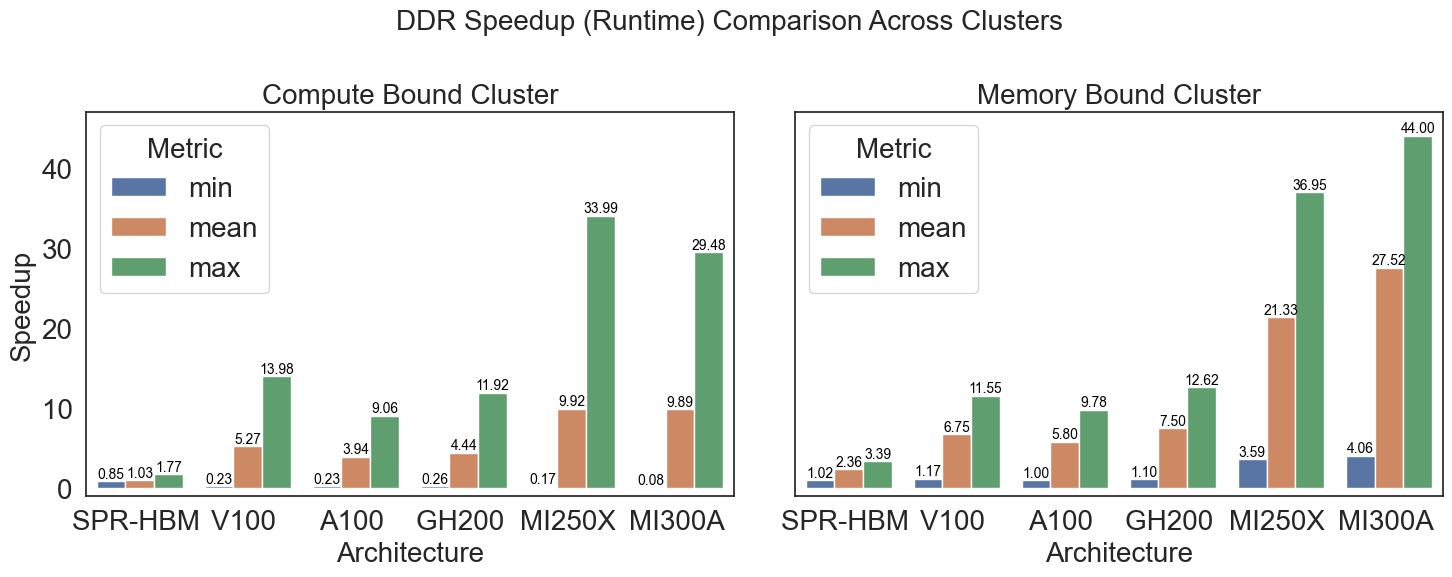

In [71]:
df = speedup_df.loc[:, ["SPR-HBM Speedup", "V100 Speedup", "A100 Speedup", "GH200 Speedup", "MI250X Speedup", "MI300A Speedup"]].T

# Reshape the dataframe for visualization
df = df.stack().reset_index()
df.columns = ['GPU', 'Metric', 'Cluster', 'Speedup']

df = df.replace("Speedup", "", regex=True)

# Create separate plots for each cluster
clusters = df['Cluster'].unique()
fig, axes = plt.subplots(1, len(clusters), figsize=(15, 6), sharey=True)

plt.ylim(bottom=-1, top=47)

for i, cluster in enumerate(clusters):
    cluster_data = df[df['Cluster'] == cluster]
    sns.barplot(x="GPU", y="Speedup", hue="Metric", data=cluster_data, ax=axes[i])
    if i == 0:
        axes[i].set_title(f"Compute Bound Cluster")
    elif i == 1:
        axes[i].set_title(f"Memory Bound Cluster")
    axes[i].set_ylabel("Speedup")
    axes[i].set_xlabel("Architecture")
    #axes[i].tick_params(axis='x', rotation=45)
    #axes[i].grid(axis="y", linestyle="--", alpha=0.7)
    axes[i].legend(title="Metric")

    ax = axes[i]
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            
            # If the bar height is less than 1, add the text above the bar
            #if height < 1:
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05,  # Adjust text position
                    f'{height:.2f}',  # Show the speedup value (you can format as needed)
                    ha='center', va='bottom', fontsize=10, color='black')

plt.suptitle("DDR Speedup (Runtime) Comparison Across Clusters")
plt.tight_layout()
plt.show()

In [72]:
box_data = triple_plot_df.drop(["Kernel", "index", "color"], axis="columns")
box_data = box_data.loc[:, ["SPR-HBM Speedup", "V100 Speedup", "A100 Speedup", "GH200 Speedup", "MI250X Speedup", "MI300A Speedup", "Cluster ID"]]
box_data = box_data.rename(columns={
    "SPR-HBM Speedup": "SPR-HBM",
    "V100 Speedup": "4xV100",
    "A100 Speedup": "2xA100",
    "GH200 Speedup": "1xGH200",
    "MI250X Speedup": "8xMI250X",
    "MI300A Speedup": "4xMI300A"
})
box_data = box_data.melt(id_vars=["Cluster ID"], var_name="Architecture", value_name="Speedup")
box_data

,Cluster ID,Architecture,Speedup
0,1,SPR-HBM,3.386796
1,1,SPR-HBM,1.023321
2,0,SPR-HBM,1.301700
3,0,SPR-HBM,1.562515
4,0,SPR-HBM,0.972539
...,...,...,...
265,0,4xMI300A,0.305927
266,1,4xMI300A,32.241824
267,1,4xMI300A,30.842388
268,1,4xMI300A,30.687266


In [73]:
baseline_speedup_df = triple_plot_df.drop(["index", "color"], axis="columns")[triple_plot_df["Kernel"].isin(["Basic_MAT_MAT_SHARED", "Stream_TRIAD"])]
baseline_speedup_df = baseline_speedup_df.loc[:, ["Kernel", "SPR-HBM Speedup", "V100 Speedup", "A100 Speedup", "GH200 Speedup", "MI250X Speedup", "MI300A Speedup", "Cluster ID"]]
baseline_speedup_df = baseline_speedup_df.rename(columns={
    "SPR-HBM Speedup": "SPR-HBM",
    "V100 Speedup": "4xV100",
    "A100 Speedup": "2xA100",
    "GH200 Speedup": "1xGH200",
    "MI250X Speedup": "8xMI250X",
    "MI300A Speedup": "4xMI300A"
})
baseline_speedup_df = baseline_speedup_df.melt(id_vars=["Kernel", "Cluster ID"], var_name="Architecture", value_name="Speedup")
baseline_speedup_df

,Kernel,Cluster ID,Architecture,Speedup
0,Basic_MAT_MAT_SHARED,0,SPR-HBM,0.864079
1,Stream_TRIAD,1,SPR-HBM,2.387743
2,Basic_MAT_MAT_SHARED,0,4xV100,1.674250
3,Stream_TRIAD,1,4xV100,7.149434
4,Basic_MAT_MAT_SHARED,0,2xA100,0.718326
5,Stream_TRIAD,1,2xA100,5.780622
6,Basic_MAT_MAT_SHARED,0,1xGH200,0.460972
7,Stream_TRIAD,1,1xGH200,7.904667
8,Basic_MAT_MAT_SHARED,0,8xMI250X,4.511582
9,Stream_TRIAD,1,8xMI250X,21.844581


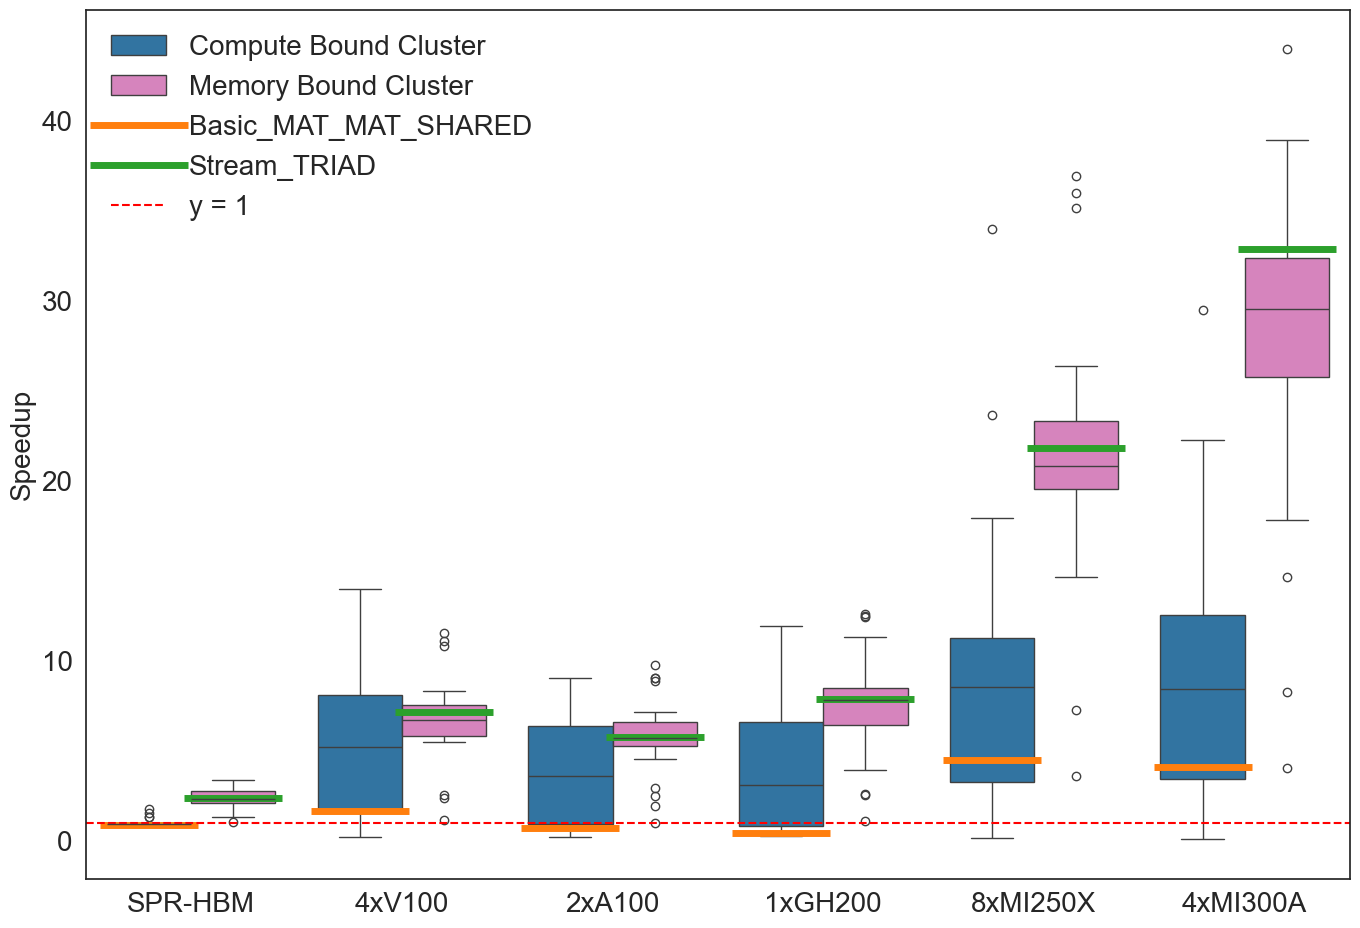

In [74]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
sns.boxplot(
    data=box_data,
    x="Architecture",
    y="Speedup",
    hue="Cluster ID",
    ax=ax,
    palette=["tab:blue", "tab:pink"]
)
sns.pointplot(
    data=baseline_speedup_df, 
    x="Architecture", 
    y="Speedup",
    hue="Kernel",
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=70, markeredgewidth=5,
    palette=["tab:orange", "tab:green"],
    legend=True
)
plt.axhline(1.0, linestyle="--", color="red", label="y = 1")
handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Compute Bound Cluster", "Memory Bound Cluster", "Basic_MAT_MAT_SHARED", "Stream_TRIAD", "y = 1"],frameon=False)
plt.tight_layout()
plt.xlabel("")
plt.savefig("speedup_stats.png")
plt.show()

# for the memory bound ones, what % of stream speedup does each one get on each platform?

In [75]:
raw_bw_df = bandwidth_df[bandwidth_df["Cluster ID"] == 1].loc[:, [
    "Kernel",
    "SPR-DDR Memory Bandwidth",
    "SPR-HBM Memory Bandwidth",
    "V100 Memory Bandwidth", 
    "A100 Memory Bandwidth", 
    "GH200 Memory Bandwidth", 
    "MI250X Memory Bandwidth", 
    "MI300A Memory Bandwidth"
    ]]
raw_bw_df

,Kernel,SPR-DDR Memory Bandwidth,SPR-HBM Memory Bandwidth,V100 Memory Bandwidth,A100 Memory Bandwidth,GH200 Memory Bandwidth,MI250X Memory Bandwidth,MI300A Memory Bandwidth
0,Algorithm_MEMCPY,492.139527,1671.308905,3186.034348,2637.727285,3320.817266,10343.428157,15027.843169
1,Algorithm_MEMSET,2967.769980,3037.671182,3461.603152,2968.143727,3256.709167,10648.219932,12056.230996
5,Apps_ENERGY,456.613871,1013.775265,3252.354602,2781.434316,3672.493530,9365.868528,12290.952257
11,Apps_MATVEC_3D_STENCIL,385.237381,783.737361,2142.690818,2478.162248,3263.825796,6423.167457,7113.807829
12,Apps_PRESSURE,413.290003,951.481404,3222.798621,2735.606986,3497.129055,9650.911893,12552.142294
14,Apps_ZONAL_ACCUMULATION_3D,376.814571,786.280113,3054.380537,2612.362706,3156.061734,7719.507640,9579.091298
15,Basic_ARRAY_OF_PTRS,431.879888,862.902199,1105.307075,1066.245563,1697.252747,10408.318392,11415.442237
16,Basic_COPY8,279.558042,766.238012,3229.284693,2735.065316,3529.323700,10329.031820,10886.290016
17,Basic_DAXPY,1401.090684,1833.026675,3332.548611,2706.794733,3670.172519,10153.366188,11572.972414
18,Basic_IF_QUAD,307.113936,432.964576,2307.384329,2725.826082,3477.089918,8106.893410,10235.795057


In [76]:
raw_bw_df_compbound = bandwidth_df[bandwidth_df["Cluster ID"] == 0].loc[:, [
    "Kernel",
    "SPR-DDR Memory Bandwidth",
    "SPR-HBM Memory Bandwidth",
    "V100 Memory Bandwidth", 
    "A100 Memory Bandwidth", 
    "GH200 Memory Bandwidth", 
    "MI250X Memory Bandwidth", 
    "MI300A Memory Bandwidth"
    ]]
raw_bw_df_compbound

,Kernel,SPR-DDR Memory Bandwidth,SPR-HBM Memory Bandwidth,V100 Memory Bandwidth,A100 Memory Bandwidth,GH200 Memory Bandwidth,MI250X Memory Bandwidth,MI300A Memory Bandwidth
2,Apps_CONVECTION3DPA,413.507972,538.333090,2589.548521,1693.017237,1502.164939,4076.772730,4809.744052
3,Apps_DEL_DOT_VEC_2D,389.174360,608.116778,3102.874034,2562.372588,3218.013546,6968.047870,7606.638651
4,Apps_DIFFUSION3DPA,333.120336,323.971713,2788.528017,2123.587496,1960.720114,7884.638184,7414.145930
6,Apps_FIR,382.457605,339.444609,3103.118936,2128.346898,2524.810353,3946.939766,4804.089371
7,Apps_LTIMES,151.899371,130.389079,214.330574,139.669739,120.675394,348.445595,518.203137
8,Apps_LTIMES_NOVIEW,153.676686,131.323967,214.488809,139.658858,120.642783,348.479252,518.255928
9,Apps_MASS3DEA,18.179991,15.687428,254.654857,163.778422,215.844772,59.082297,1.523342
10,Apps_MASS3DPA,560.373969,521.821747,2930.929695,2013.721027,1741.796733,4386.273824,5122.658419
13,Apps_VOL3D,325.511170,311.110644,3026.286867,2279.788849,2575.682592,5027.180709,5469.984876
20,Basic_INIT_VIEW1D,1246.942652,1131.089357,3467.407510,2957.435588,3294.916538,10631.367351,10350.449668


In [77]:
perc_triad_df = bandwidth_df[bandwidth_df["Cluster ID"] == 1].loc[:, [
    "Kernel",
    "SPR-DDR Percent of Stream_TRIAD",
    "SPR-HBM Percent of Stream_TRIAD",
    "V100 Percent of Stream_TRIAD", 
    "A100 Percent of Stream_TRIAD", 
    "GH200 Percent of Stream_TRIAD", 
    "MI250X Percent of Stream_TRIAD", 
    "MI300A Percent of Stream_TRIAD"
    ]]
perc_triad_df

,Kernel,SPR-DDR Percent of Stream_TRIAD,SPR-HBM Percent of Stream_TRIAD,V100 Percent of Stream_TRIAD,A100 Percent of Stream_TRIAD,GH200 Percent of Stream_TRIAD,MI250X Percent of Stream_TRIAD,MI300A Percent of Stream_TRIAD
0,Algorithm_MEMCPY,1.055943,1.501790,0.956164,0.979060,0.901395,1.015955,0.979949
1,Algorithm_MEMSET,6.367695,2.729563,1.038866,1.101703,0.883994,1.045893,0.786173
5,Apps_ENERGY,0.979718,0.910949,0.976068,1.032401,0.996853,0.919937,0.801479
11,Apps_MATVEC_3D_STENCIL,0.826572,0.704244,0.643045,0.919834,0.885925,0.630898,0.463883
12,Apps_PRESSURE,0.886762,0.854974,0.967198,1.015391,0.949253,0.947935,0.818511
14,Apps_ZONAL_ACCUMULATION_3D,0.808499,0.706528,0.916653,0.969645,0.856674,0.758228,0.624642
15,Basic_ARRAY_OF_PTRS,0.926648,0.775379,0.331715,0.395764,0.460698,1.022329,0.744388
16,Basic_COPY8,0.599824,0.688519,0.969144,1.015190,0.957992,1.014541,0.709883
17,Basic_DAXPY,3.006203,1.647104,1.000135,1.004696,0.996223,0.997287,0.754660
18,Basic_IF_QUAD,0.658949,0.389049,0.692472,1.011760,0.943813,0.796278,0.667465


In [78]:
size=20
plt.rcParams.update({
    'font.size': size,         # General font size
    'axes.titlesize': size,    # Title size of axes
    'axes.labelsize': 19,    # Size of axis labels
    'xtick.labelsize': size,   # X-axis tick labels size
    'ytick.labelsize': 15,   # Y-axis tick labels size
    'legend.fontsize': size,   # Legend font size
    'legend.title_fontsize': size,
    'figure.titlesize': size   # Figure title size
})

In [79]:
num_map = {
    "V100": "4xV100",
    "A100": "2xA100",
    "GH200": "1xGH200",
    "MI250X": "8xMI250X",
    "MI300A": "4xMI300A"
}

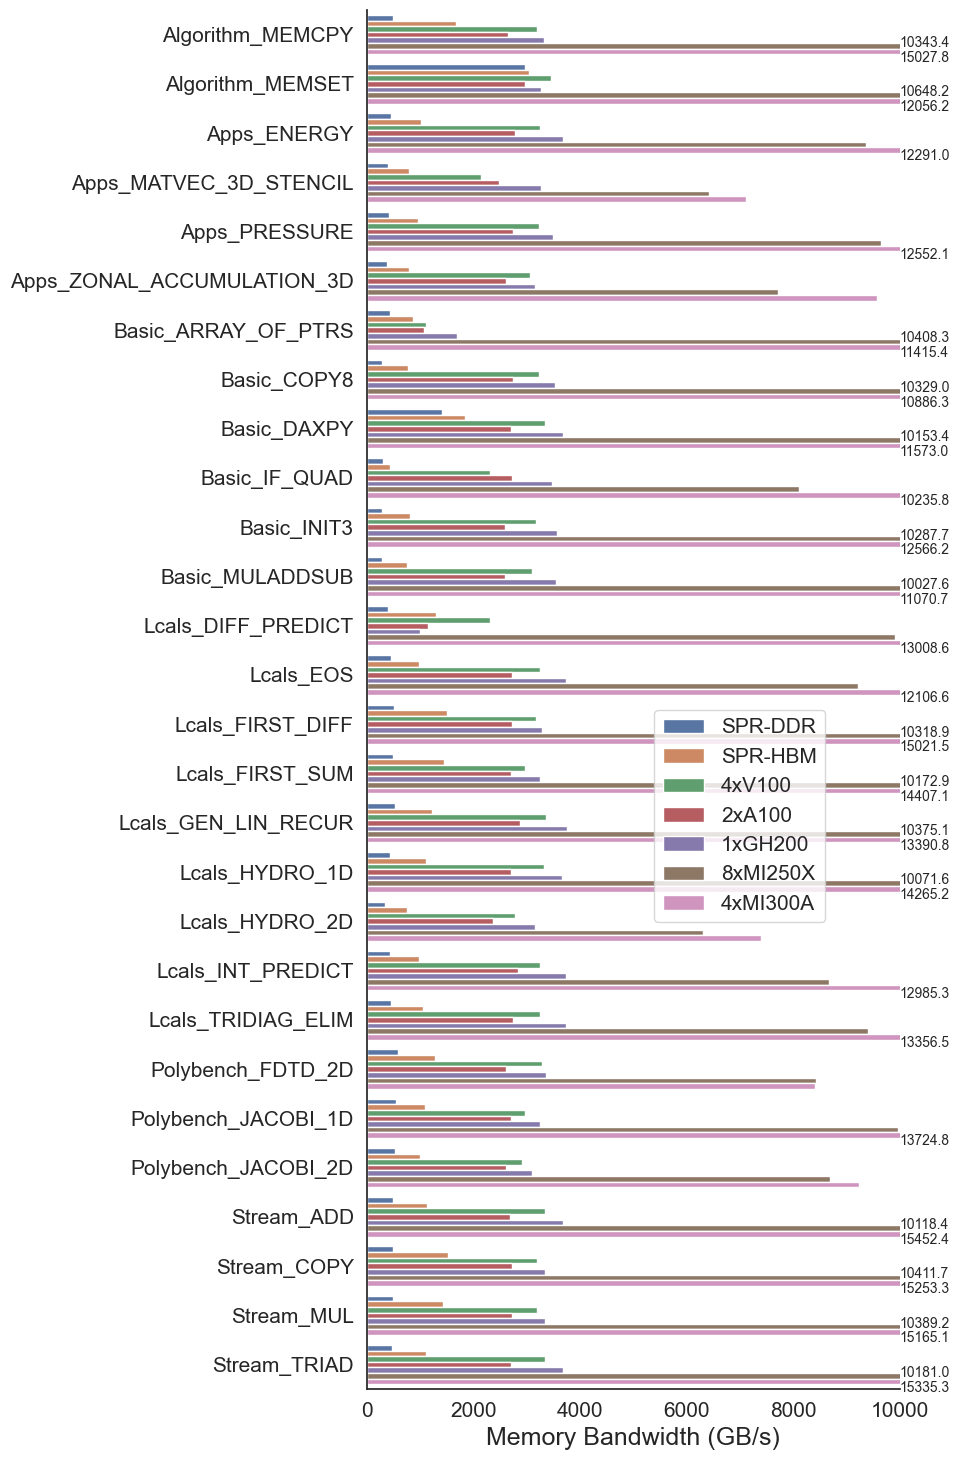

<Figure size 2800x800 with 0 Axes>

In [80]:
# Reshape the data to long format
df_long = pd.melt(raw_bw_df, id_vars=["Kernel"], var_name="Architecture", value_name="Memory Bandwidth")

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" Memory Bandwidth", "")

df_long = df_long.replace(num_map)

# Plot
plt.figure(figsize=(10, 15))
ax = sns.barplot(
    x="Memory Bandwidth", 
    y="Kernel", 
    hue="Architecture", 
    data=df_long, 
    orient="h"
)
plt.tick_params(axis="both", which="major", labelsize=15)
plt.xlabel("Memory Bandwidth (GB/s)", fontsize=18)
plt.ylabel("")

lim=10000
# Cap the x-axis at 200
plt.xlim(0, lim)

# Annotate values greater than lim
for i, row in df_long.iterrows():
    if row["Memory Bandwidth"] > lim:
        x_val = min(row["Memory Bandwidth"], lim)
        mod = len(set(df_long["Kernel"]))
        ax.text(
            x_val, i%mod+(i//mod*0.3)-1.25, 
            f"{row['Memory Bandwidth']:.1f}", 
            #color='red', 
            #va='bottom', 
            fontsize=10
        )
    
plt.legend(bbox_to_anchor=(.7, 0.5), fontsize=15)
#plt.axvline(x=100, color='black', linestyle='--', label="x = 100")
sns.despine()
plt.tight_layout()
plt.show()
plt.clf()


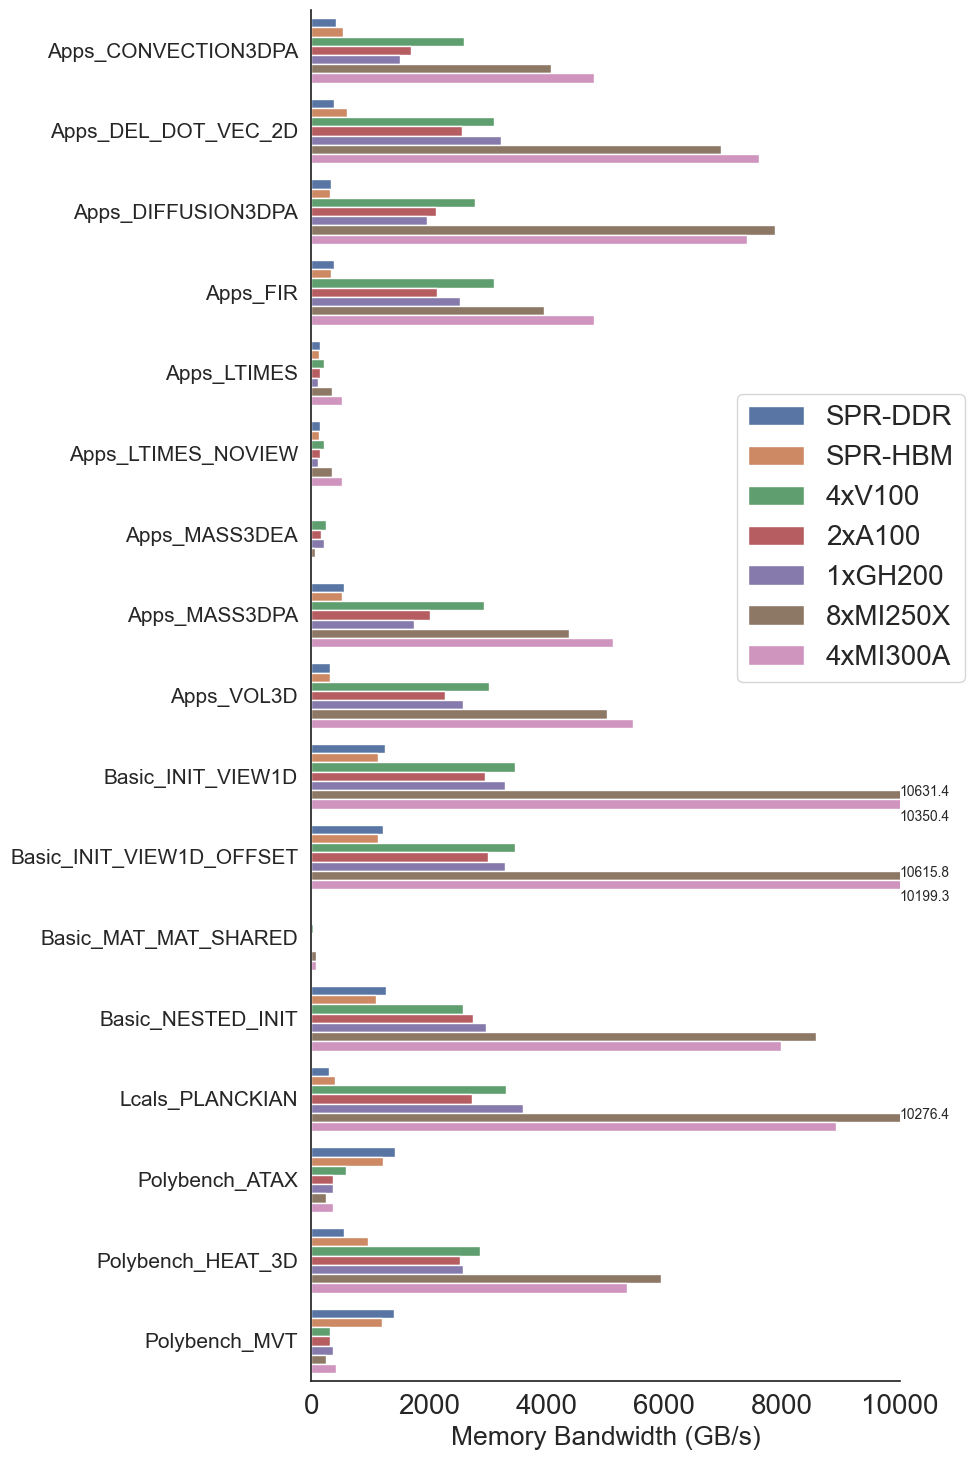

<Figure size 2800x800 with 0 Axes>

In [81]:
# Reshape the data to long format
df_long = pd.melt(raw_bw_df_compbound, id_vars=["Kernel"], var_name="Architecture", value_name="Memory Bandwidth")

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" Memory Bandwidth", "")

df_long = df_long.replace(num_map)

# Plot
plt.figure(figsize=(10, 15))
ax = sns.barplot(
    x="Memory Bandwidth", 
    y="Kernel", 
    hue="Architecture", 
    data=df_long, 
    orient="h"
)
plt.xlabel("Memory Bandwidth (GB/s)")
plt.ylabel("")

lim=10000
# Cap the x-axis at 200
plt.xlim(0, lim)

# Annotate values greater than lim
for i, row in df_long.iterrows():
    if row["Memory Bandwidth"] > lim:
        x_val = min(row["Memory Bandwidth"], lim)
        mod = len(set(df_long["Kernel"]))
        ax.text(
            x_val, i%mod+(i//mod*0.3)-1.25, 
            f"{row['Memory Bandwidth']:.1f}", 
            #color='red', 
            #va='bottom', 
            fontsize=10
        )
    
plt.legend(bbox_to_anchor=(.7, 0.5))
#plt.axvline(x=100, color='black', linestyle='--', label="x = 100")
sns.despine()
plt.tight_layout()
plt.show()
plt.clf()


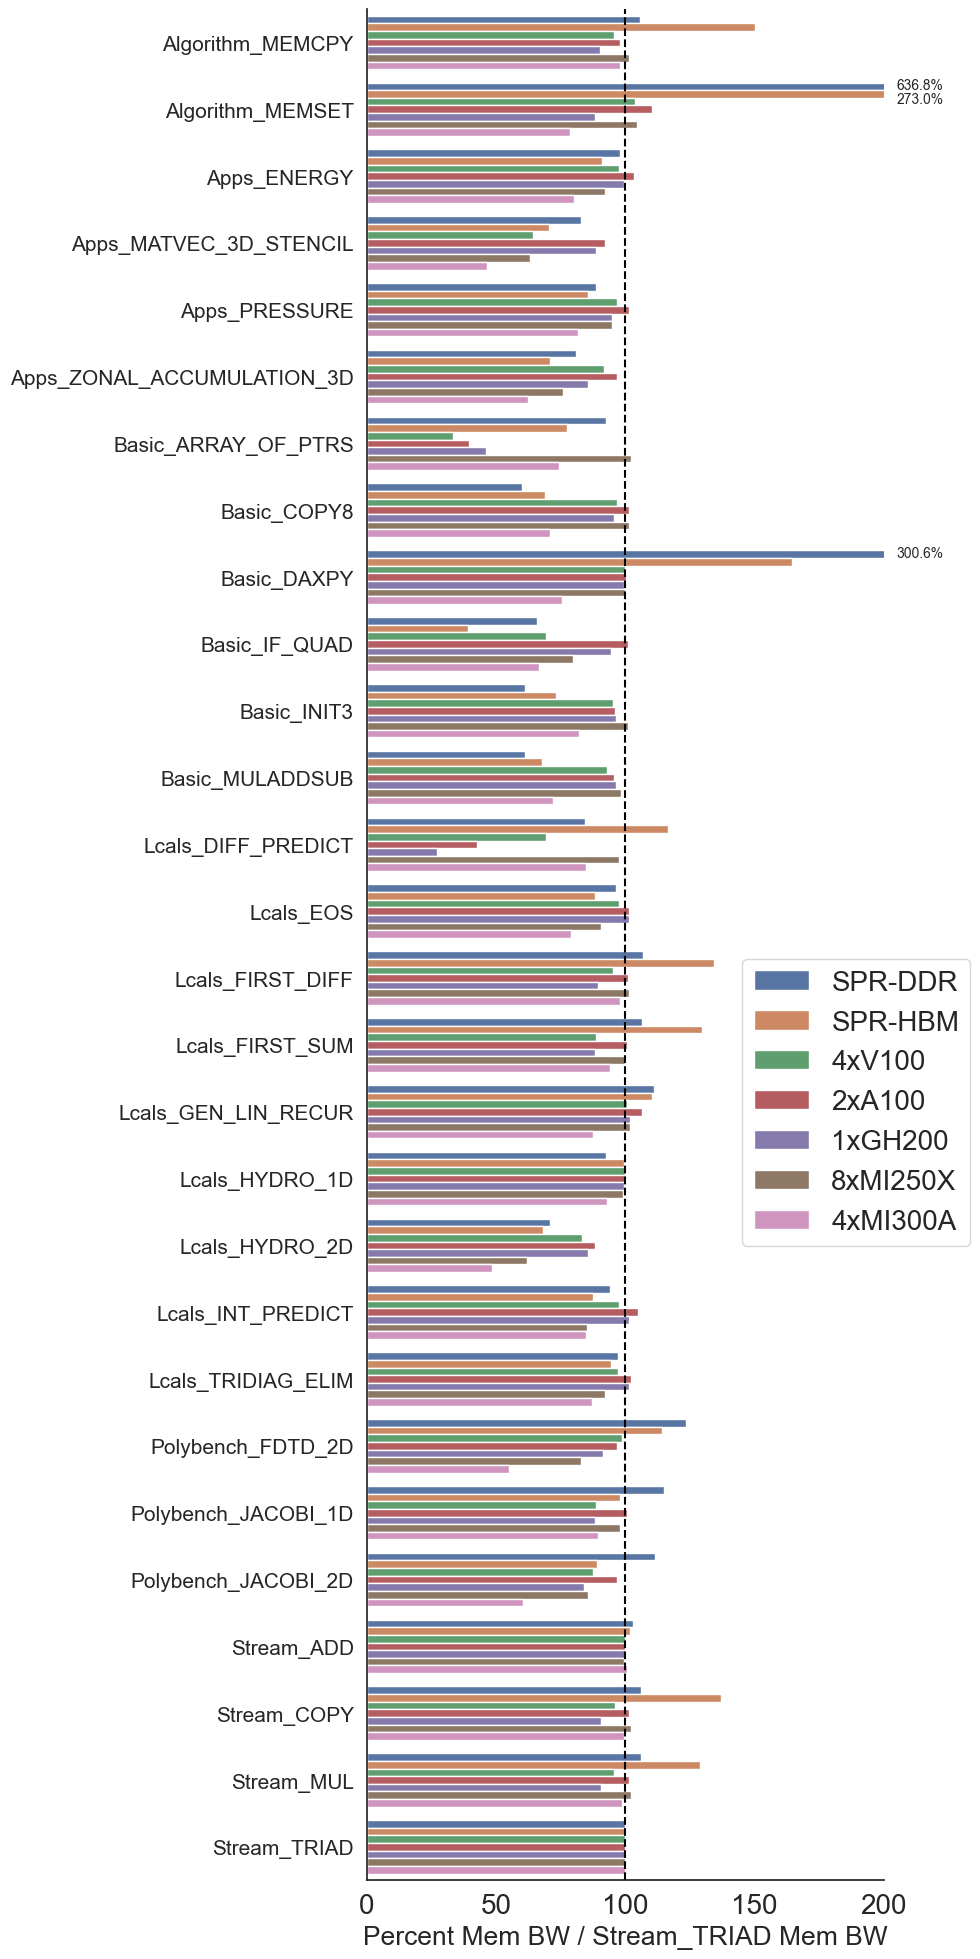

<Figure size 2800x800 with 0 Axes>

In [82]:
# Reshape the data to long format
df_long = pd.melt(perc_triad_df, id_vars=["Kernel"], var_name="Architecture", value_name="Percent of Stream_TRIAD")
df_long["Percent of Stream_TRIAD"] = df_long["Percent of Stream_TRIAD"] * 100

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" Percent of Stream_TRIAD", "")

df_long = df_long.replace(num_map)

# Plot
plt.figure(figsize=(10, 20))
ax = sns.barplot(
    x="Percent of Stream_TRIAD", 
    y="Kernel", 
    hue="Architecture", 
    data=df_long, 
    orient="h"
)
plt.xlabel("Percent Mem BW / Stream_TRIAD Mem BW")
           #Percent Speedup (Mem BW) over Stream_TRIAD")
plt.ylabel("")

# Cap the x-axis at 200
plt.xlim(0, 200)

# Annotate values greater than 200

for i, row in df_long.iterrows():
    if row["Percent of Stream_TRIAD"] > 175:
        x_val = min(row["Percent of Stream_TRIAD"], 205)
        mod = len(set(df_long["Kernel"]))
        ax.text(
            x_val, i%mod+(i//mod*0.2)-0.3, 
            f"{row['Percent of Stream_TRIAD']:.1f}%", 
            #color='red', 
            #va='bottom', 
            fontsize=10
        )
    
plt.legend(bbox_to_anchor=(.7, 0.5))
plt.axvline(x=100, color='black', linestyle='--', label="x = 100")
sns.despine()
plt.tight_layout()
plt.show()
plt.clf()


# for the memory bound ones, which set is roughly the same speedup as stream triad, which set is significantly lower, and which set is higher - per platform

In [83]:
low_list = []
middle_list = []
high_list = []
lowbound = 0.75
highbound = 1.25
for arch in set(df_long["Architecture"].values):
    print(arch)
    tdf = df_long[df_long["Architecture"] == arch]

    lowset = set(tdf[tdf["Percent of Stream_TRIAD"] < lowbound]["Kernel"])
    middleset = set(tdf[(tdf["Percent of Stream_TRIAD"] > lowbound) & (tdf["Percent of Stream_TRIAD"] < highbound)]["Kernel"])
    highset = set(tdf[tdf["Percent of Stream_TRIAD"] > highbound]["Kernel"])

    print(f"\t< {lowbound}", lowset)
    print(f"\tmiddle", middleset)
    print(f"\t> {highbound}", highset)

    low_list.append(lowset)
    middle_list.append(middleset)
    high_list.append(highset)

8xMI250X
	< 0.75 set()
	middle set()
	> 1.25 {'Lcals_TRIDIAG_ELIM', 'Stream_TRIAD', 'Polybench_JACOBI_2D', 'Apps_ENERGY', 'Lcals_INT_PREDICT', 'Lcals_EOS', 'Basic_INIT3', 'Lcals_HYDRO_1D', 'Polybench_JACOBI_1D', 'Lcals_GEN_LIN_RECUR', 'Basic_COPY8', 'Lcals_DIFF_PREDICT', 'Basic_IF_QUAD', 'Algorithm_MEMCPY', 'Lcals_FIRST_DIFF', 'Lcals_FIRST_SUM', 'Stream_ADD', 'Apps_PRESSURE', 'Basic_ARRAY_OF_PTRS', 'Apps_ZONAL_ACCUMULATION_3D', 'Apps_MATVEC_3D_STENCIL', 'Algorithm_MEMSET', 'Basic_DAXPY', 'Stream_MUL', 'Lcals_HYDRO_2D', 'Polybench_FDTD_2D', 'Stream_COPY', 'Basic_MULADDSUB'}
SPR-DDR
	< 0.75 set()
	middle set()
	> 1.25 {'Lcals_TRIDIAG_ELIM', 'Stream_TRIAD', 'Polybench_JACOBI_2D', 'Apps_ENERGY', 'Lcals_INT_PREDICT', 'Lcals_EOS', 'Basic_INIT3', 'Lcals_HYDRO_1D', 'Polybench_JACOBI_1D', 'Lcals_GEN_LIN_RECUR', 'Basic_COPY8', 'Lcals_DIFF_PREDICT', 'Basic_IF_QUAD', 'Algorithm_MEMCPY', 'Lcals_FIRST_DIFF', 'Lcals_FIRST_SUM', 'Stream_ADD', 'Apps_PRESSURE', 'Basic_ARRAY_OF_PTRS', 'Apps_ZONAL_ACCUMUL

# for the memory bound ones, which set has roughly the same % speedup relative to stream triad on ALL platforms?

In [84]:
print(set.intersection(*middle_list))

set()


# for the memory bound ones, which set has good speedup on a subset of the platforms - and shows less speedup on others? 

In [85]:
df = df_long
# Classify the Percent of Stream_TRIAD into ranges
bins = [-float('inf'), 75, 125, float('inf')]
labels = ['75%', '75% - 125%', '> 125%']
df['Stream_TRIAD_Range'] = pd.cut(df['Percent of Stream_TRIAD'], bins=bins, labels=labels)

# Group by Kernel and Stream_TRIAD_Range, then count occurrences
result = df.groupby(['Kernel', 'Stream_TRIAD_Range']).size().reset_index(name='Architectures')


In [86]:
result

,Kernel,Stream_TRIAD_Range,Architectures
0,Algorithm_MEMCPY,75%,0
1,Algorithm_MEMCPY,75% - 125%,6
2,Algorithm_MEMCPY,> 125%,1
3,Algorithm_MEMSET,75%,0
4,Algorithm_MEMSET,75% - 125%,5
...,...,...,...
79,Stream_MUL,75% - 125%,6
80,Stream_MUL,> 125%,1
81,Stream_TRIAD,75%,0
82,Stream_TRIAD,75% - 125%,7


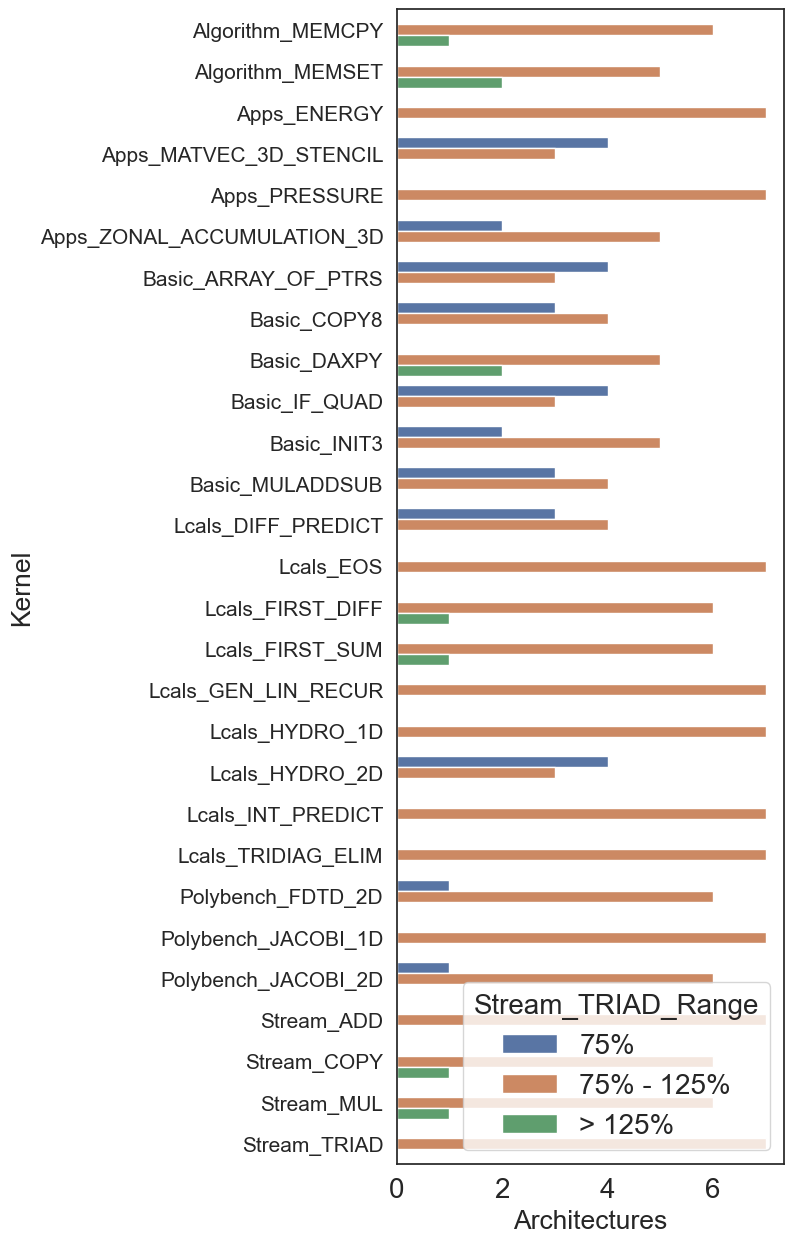

In [87]:
plt.figure(figsize=(5, 15))
sns.barplot(
    data=result,
    x="Architectures",
    y="Kernel",
    hue="Stream_TRIAD_Range",
)
plt.show()

# for the retiring cluster, what % of matmat speedup does each one get?

In [88]:
for i, gpu_type in enumerate(["V100", "A100", "GH200", "MI250X", "MI300A"]):
    triple_plot_df["{} Percent of Basic_MAT_MAT_SHARED".format(gpu_type)] = triple_plot_df["{} Speedup".format(gpu_type)] / triple_plot_df[triple_plot_df["Kernel"] == "Basic_MAT_MAT_SHARED"]["{} Speedup".format(gpu_type)].iloc[0]

triple_plot_df

,index,Kernel,DDR Memory Bound,SPR-HBM Speedup,V100 Speedup,A100 Speedup,GH200 Speedup,MI250X Speedup,MI300A Speedup,color,Cluster ID,SPR-HBM Percent of Stream_TRIAD,V100 Percent of Stream_TRIAD,A100 Percent of Stream_TRIAD,GH200 Percent of Stream_TRIAD,MI250X Percent of Stream_TRIAD,MI300A Percent of Stream_TRIAD,V100 Percent of Basic_MAT_MAT_SHARED,A100 Percent of Basic_MAT_MAT_SHARED,GH200 Percent of Basic_MAT_MAT_SHARED,MI250X Percent of Basic_MAT_MAT_SHARED,MI300A Percent of Basic_MAT_MAT_SHARED
0,0,Algorithm_MEMCPY,0.922720,3.386796,6.473918,5.359793,6.747813,21.017597,30.536256,1,1,1.418409,0.905515,0.927200,0.853649,0.962142,0.928045,3.866756,7.461505,14.638217,4.658586,7.408382
1,1,Algorithm_MEMSET,0.646944,1.023321,1.166566,1.000265,1.097503,3.588471,4.062968,1,1,0.428572,0.163169,0.173038,0.138842,0.164273,0.123480,0.696769,1.392495,2.380843,0.795391,0.985714
2,2,Apps_CONVECTION3DPA,0.443966,1.301700,6.262460,4.094343,3.632800,9.859156,11.631762,1,0,0.545159,0.875938,0.708288,0.459577,0.451332,0.353508,3.740456,5.699840,7.880733,2.185299,2.821974
3,3,Apps_DEL_DOT_VEC_2D,0.462774,1.562515,7.980201,6.586540,8.275382,17.913766,19.563365,1,0,0.654390,1.116200,1.139417,1.046898,0.820055,0.594562,4.766432,9.169292,17.952015,3.970617,4.746256
4,4,Apps_DIFFUSION3DPA,0.263633,0.972539,8.371183,6.375029,5.886129,23.669824,22.257460,1,0,0.407305,1.170887,1.102827,0.744640,1.083556,0.676440,4.999959,8.874842,12.768941,5.246457,5.399868
5,5,Apps_ENERGY,0.833665,2.216925,7.122768,6.091414,8.042887,20.511563,26.917540,1,1,0.928460,0.996270,1.053764,1.017486,0.938977,0.818067,4.254303,8.480014,17.447656,4.546423,6.530447
6,6,Apps_FIR,0.011377,0.887608,8.114739,5.538746,6.602458,10.321326,12.562827,1,0,0.371735,1.135018,0.958157,0.835261,0.472489,0.381804,4.846790,7.710631,14.322895,2.287740,3.047859
7,7,Apps_LTIMES,0.051372,0.858390,1.412363,0.920424,0.795273,2.295889,3.414777,1,0,0.359498,0.197549,0.159226,0.100608,0.105101,0.103781,0.843579,1.281346,1.725207,0.508888,0.828457
8,8,Apps_LTIMES_NOVIEW,0.058963,0.854549,1.397028,0.909689,0.785845,2.269503,3.375551,1,0,0.357890,0.195404,0.157369,0.099415,0.103893,0.102588,0.834420,1.266401,1.704755,0.503039,0.818940
9,9,Apps_MASS3DEA,0.000392,0.862880,13.981073,8.991535,11.846833,3.243761,0.083636,1,0,0.361379,1.955550,1.555461,1.498714,0.148493,0.002542,8.350647,12.517347,25.699662,0.718985,0.020291


In [89]:
flop_df

,Kernel,SPR-DDR FLOP Rate,SPR-HBM FLOP Rate,V100 FLOP Rate,A100 FLOP Rate,GH200 FLOP Rate,MI250X FLOP Rate,MI300A FLOP Rate,Cluster ID,SPR-DDR Percent of Basic_MAT_MAT_SHARED,SPR-HBM Percent of Basic_MAT_MAT_SHARED,V100 Percent of Basic_MAT_MAT_SHARED,A100 Percent of Basic_MAT_MAT_SHARED,GH200 Percent of Basic_MAT_MAT_SHARED,MI250X Percent of Basic_MAT_MAT_SHARED,MI300A Percent of Basic_MAT_MAT_SHARED
0,Algorithm_MEMCPY,0.000000,0.000000,0.000000,0.000000,0.000000,3.429483e-312,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,2.573454e-316,0.000000
1,Algorithm_MEMSET,0.000000,0.000000,0.000000,0.000000,0.000000,7.061081e-312,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,5.298572e-316,0.000000
2,Apps_CONVECTION3DPA,763.359194,993.793449,4780.599702,3125.500160,2773.168875,7.526181e+03,8879.328263,0,0.902903,1.360359,0.683761,0.736509,0.714364,5.647578e-01,0.515858
3,Apps_DEL_DOT_VEC_2D,436.755574,682.466317,3489.126599,2881.730421,3619.432108,7.833950e+03,8553.529440,0,0.516595,0.934197,0.499044,0.679066,0.932360,5.878525e-01,0.496930
4,Apps_DIFFUSION3DPA,632.653018,615.278203,5295.952335,4033.107685,3723.786624,1.497447e+04,14080.909913,0,0.748303,0.842226,0.757471,0.950382,0.959242,1.123671e+00,0.818052
5,Apps_ENERGY,116.267421,258.137220,828.145848,708.235615,935.125667,2.384830e+03,3129.629567,1,0.137521,0.353352,0.118448,0.166892,0.240887,1.789555e-01,0.181821
6,Apps_FIR,764.875637,678.854095,6206.226404,4256.685868,5049.618373,7.893868e+03,9608.142949,0,0.904696,0.929252,0.887666,1.003067,1.300774,5.923488e-01,0.558200
7,Apps_LTIMES,531.383925,456.135271,751.956582,490.043812,423.411101,1.222354e+03,1818.059661,0,0.628522,0.624383,0.107551,0.115476,0.109070,9.172434e-02,0.105623
8,Apps_LTIMES_NOVIEW,537.601441,459.405756,752.511736,490.005634,423.296678,1.222472e+03,1818.244873,0,0.635876,0.628860,0.107630,0.115467,0.109041,9.173320e-02,0.105634
9,Apps_MASS3DEA,15.435408,13.319141,216.223856,139.062419,183.271077,5.016583e+01,1.293449,0,0.018257,0.018232,0.030926,0.032769,0.047210,3.764399e-03,0.000075


In [90]:
raw_flop_df = flop_df[flop_df["Cluster ID"] == 0].loc[:, [
    "Kernel",
    "SPR-DDR FLOP Rate",
    "SPR-HBM FLOP Rate",
    "V100 FLOP Rate", 
    "A100 FLOP Rate", 
    "GH200 FLOP Rate", 
    "MI250X FLOP Rate", 
    "MI300A FLOP Rate"
    ]]
raw_flop_df

,Kernel,SPR-DDR FLOP Rate,SPR-HBM FLOP Rate,V100 FLOP Rate,A100 FLOP Rate,GH200 FLOP Rate,MI250X FLOP Rate,MI300A FLOP Rate
2,Apps_CONVECTION3DPA,763.359194,993.793449,4780.599702,3125.500160,2773.168875,7526.180509,8879.328263
3,Apps_DEL_DOT_VEC_2D,436.755574,682.466317,3489.126599,2881.730421,3619.432108,7833.949501,8553.529440
4,Apps_DIFFUSION3DPA,632.653018,615.278203,5295.952335,4033.107685,3723.786624,14974.466515,14080.909913
6,Apps_FIR,764.875637,678.854095,6206.226404,4256.685868,5049.618373,7893.867769,9608.142949
7,Apps_LTIMES,531.383925,456.135271,751.956582,490.043812,423.411101,1222.353835,1818.059661
8,Apps_LTIMES_NOVIEW,537.601441,459.405756,752.511736,490.005634,423.296678,1222.471904,1818.244873
9,Apps_MASS3DEA,15.435408,13.319141,216.223856,139.062419,183.271077,50.165829,1.293449
10,Apps_MASS3DPA,1120.026074,1042.971293,5858.381187,4025.050750,3481.531345,8767.320812,10239.248708
13,Apps_VOL3D,724.410335,692.362619,6784.203529,5114.604091,5781.860461,11259.015340,12262.399659
20,Basic_INIT_VIEW1D,155.867832,141.386170,433.425939,369.678347,411.864567,1328.920919,1293.805823


In [91]:
raw_flop_df_membound = flop_df[flop_df["Cluster ID"] == 1].loc[:, [
    "Kernel",
    "SPR-DDR FLOP Rate",
    "SPR-HBM FLOP Rate",
    "V100 FLOP Rate", 
    "A100 FLOP Rate", 
    "GH200 FLOP Rate", 
    "MI250X FLOP Rate", 
    "MI300A FLOP Rate"
    ]]
raw_flop_df_membound

,Kernel,SPR-DDR FLOP Rate,SPR-HBM FLOP Rate,V100 FLOP Rate,A100 FLOP Rate,GH200 FLOP Rate,MI250X FLOP Rate,MI300A FLOP Rate
0,Algorithm_MEMCPY,0.000000,0.000000,0.000000,0.000000,0.000000,3.429483e-312,0.000000
1,Algorithm_MEMSET,0.000000,0.000000,0.000000,0.000000,0.000000,7.061081e-312,0.000000
5,Apps_ENERGY,116.267421,258.137220,828.145848,708.235615,935.125667,2.384830e+03,3129.629567
11,Apps_MATVEC_3D_STENCIL,145.912900,296.849156,827.116969,958.492191,1264.314471,2.473362e+03,2746.069350
12,Apps_PRESSURE,25.830625,59.467588,201.424914,170.975352,218.570566,6.031805e+02,784.508504
14,Apps_ZONAL_ACCUMULATION_3D,123.730434,258.182106,1013.111523,867.388276,1048.753454,2.557184e+03,3177.296681
15,Basic_ARRAY_OF_PTRS,51.985542,103.867857,133.046222,128.344510,204.298942,1.252855e+03,1374.082544
16,Basic_COPY8,0.000000,0.000000,0.000000,0.000000,0.000000,4.280891e-313,0.000000
17,Basic_DAXPY,116.757557,152.752223,277.712384,225.566116,305.847710,8.461140e+02,964.411973
18,Basic_IF_QUAD,84.456332,119.065259,634.530690,749.601360,956.199727,2.229397e+03,2814.838302


In [92]:
perc_mat_mat_df = flop_df[flop_df["Cluster ID"] == 0].loc[:, [
    "Kernel",
    "SPR-DDR Percent of Basic_MAT_MAT_SHARED",
    "SPR-HBM Percent of Basic_MAT_MAT_SHARED",
    "V100 Percent of Basic_MAT_MAT_SHARED", 
    "A100 Percent of Basic_MAT_MAT_SHARED", 
    "GH200 Percent of Basic_MAT_MAT_SHARED", 
    "MI250X Percent of Basic_MAT_MAT_SHARED", 
    "MI300A Percent of Basic_MAT_MAT_SHARED"
    ]]
perc_mat_mat_df

,Kernel,SPR-DDR Percent of Basic_MAT_MAT_SHARED,SPR-HBM Percent of Basic_MAT_MAT_SHARED,V100 Percent of Basic_MAT_MAT_SHARED,A100 Percent of Basic_MAT_MAT_SHARED,GH200 Percent of Basic_MAT_MAT_SHARED,MI250X Percent of Basic_MAT_MAT_SHARED,MI300A Percent of Basic_MAT_MAT_SHARED
2,Apps_CONVECTION3DPA,0.902903,1.360359,0.683761,0.736509,0.714364,0.564758,0.515858
3,Apps_DEL_DOT_VEC_2D,0.516595,0.934197,0.499044,0.679066,0.932360,0.587853,0.496930
4,Apps_DIFFUSION3DPA,0.748303,0.842226,0.757471,0.950382,0.959242,1.123671,0.818052
6,Apps_FIR,0.904696,0.929252,0.887666,1.003067,1.300774,0.592349,0.558200
7,Apps_LTIMES,0.628522,0.624383,0.107551,0.115476,0.109070,0.091724,0.105623
8,Apps_LTIMES_NOVIEW,0.635876,0.628860,0.107630,0.115467,0.109041,0.091733,0.105634
9,Apps_MASS3DEA,0.018257,0.018232,0.030926,0.032769,0.047210,0.003764,0.000075
10,Apps_MASS3DPA,1.324769,1.427676,0.837914,0.948484,0.896837,0.657892,0.594865
13,Apps_VOL3D,0.856834,0.947744,0.970333,1.205232,1.489398,0.844866,0.712403
20,Basic_INIT_VIEW1D,0.184361,0.193537,0.061992,0.087113,0.106096,0.099721,0.075166


In [93]:
size=20
plt.rcParams.update({
    'font.size': size,         # General font size
    'axes.titlesize': size,    # Title size of axes
    'axes.labelsize': 19,    # Size of axis labels
    'xtick.labelsize': size,   # X-axis tick labels size
    'ytick.labelsize': 15,   # Y-axis tick labels size
    'legend.fontsize': size,   # Legend font size
    'legend.title_fontsize': size,
    'figure.titlesize': size   # Figure title size
})

In [94]:
raw_flop_df_all = flop_df.loc[:, [
    "Kernel",
    "SPR-DDR FLOP Rate",
    "SPR-HBM FLOP Rate",
    "V100 FLOP Rate", 
    "A100 FLOP Rate", 
    "GH200 FLOP Rate", 
    "MI250X FLOP Rate", 
    "MI300A FLOP Rate"
    ]]
#raw_flop_df_all.set_index("Kernel", inplace=True)
raw_flop_df_all

,Kernel,SPR-DDR FLOP Rate,SPR-HBM FLOP Rate,V100 FLOP Rate,A100 FLOP Rate,GH200 FLOP Rate,MI250X FLOP Rate,MI300A FLOP Rate
0,Algorithm_MEMCPY,0.000000,0.000000,0.000000,0.000000,0.000000,3.429483e-312,0.000000
1,Algorithm_MEMSET,0.000000,0.000000,0.000000,0.000000,0.000000,7.061081e-312,0.000000
2,Apps_CONVECTION3DPA,763.359194,993.793449,4780.599702,3125.500160,2773.168875,7.526181e+03,8879.328263
3,Apps_DEL_DOT_VEC_2D,436.755574,682.466317,3489.126599,2881.730421,3619.432108,7.833950e+03,8553.529440
4,Apps_DIFFUSION3DPA,632.653018,615.278203,5295.952335,4033.107685,3723.786624,1.497447e+04,14080.909913
5,Apps_ENERGY,116.267421,258.137220,828.145848,708.235615,935.125667,2.384830e+03,3129.629567
6,Apps_FIR,764.875637,678.854095,6206.226404,4256.685868,5049.618373,7.893868e+03,9608.142949
7,Apps_LTIMES,531.383925,456.135271,751.956582,490.043812,423.411101,1.222354e+03,1818.059661
8,Apps_LTIMES_NOVIEW,537.601441,459.405756,752.511736,490.005634,423.296678,1.222472e+03,1818.244873
9,Apps_MASS3DEA,15.435408,13.319141,216.223856,139.062419,183.271077,5.016583e+01,1.293449


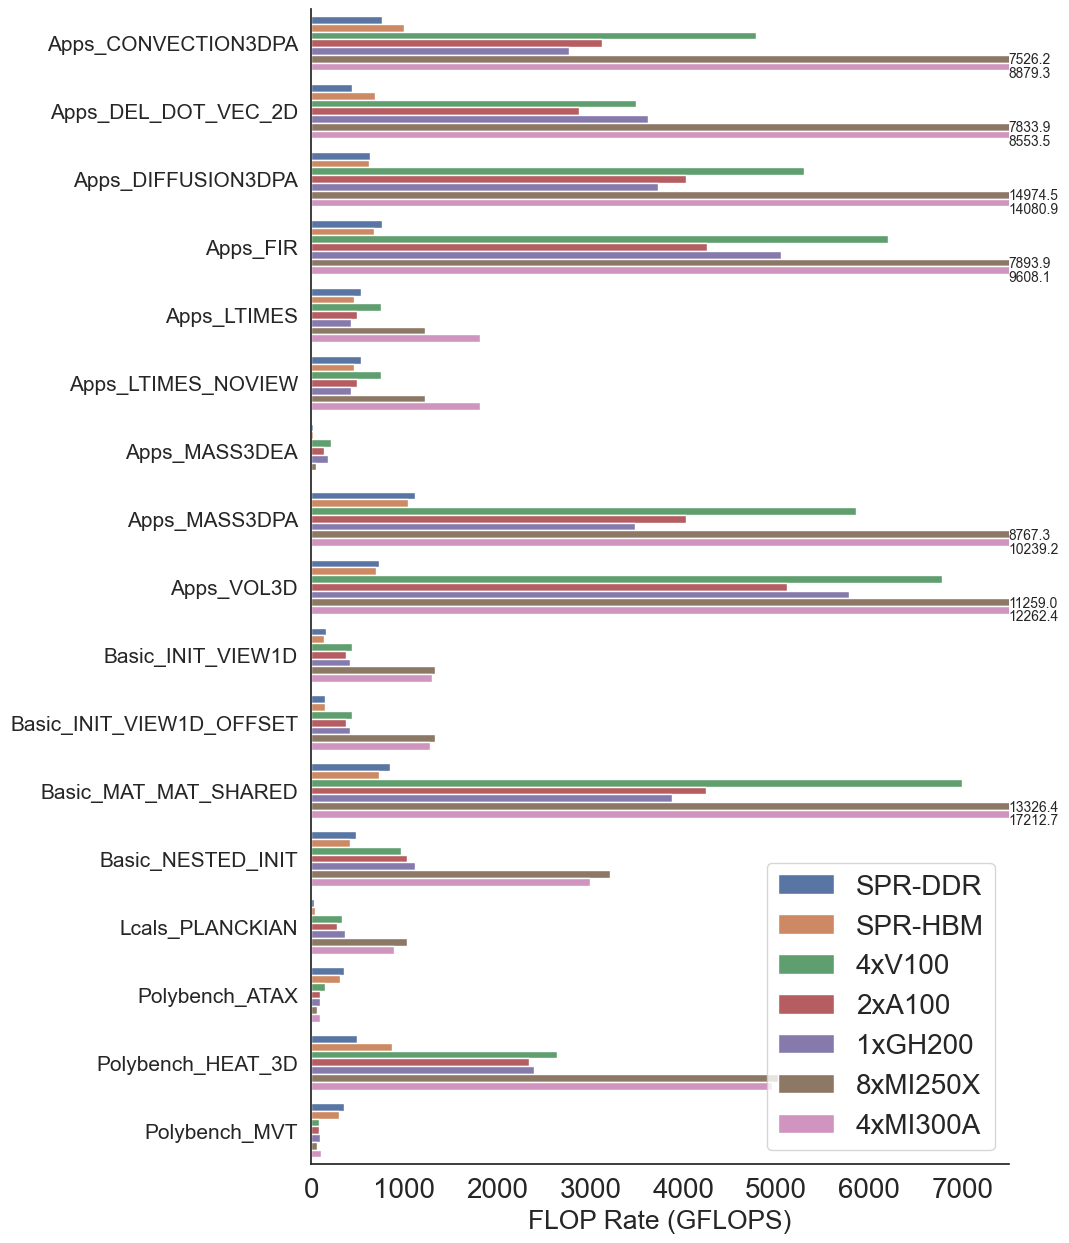

<Figure size 2800x800 with 0 Axes>

In [95]:
# Reshape the data to long format
df_long = pd.melt(raw_flop_df, id_vars=["Kernel"], var_name="Architecture", value_name="FLOP Rate")

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" FLOP Rate", "")

df_long = df_long.replace(num_map)

# Plot
fig, ax = plt.subplots(figsize=(9, 15))
sns.barplot(x="FLOP Rate", y="Kernel", hue="Architecture", data=df_long, orient="h")
plt.xlabel("FLOP Rate (GFLOPS)")
plt.ylabel("")

lim=7500
# Cap the x-axis at 200
plt.xlim(0, lim)

# Annotate values greater than lim
for i, row in df_long.iterrows():
    if row["FLOP Rate"] > lim:
        x_val = min(row["FLOP Rate"], lim)
        mod = len(set(df_long["Kernel"]))
        ax.text(
            x_val, i%mod+(i//mod*0.2)-.7, 
            f"{row['FLOP Rate']:.1f}", 
            #color='red', 
            #va='bottom', 
            fontsize=10
        )
#plt.tight_layout()
sns.despine()
plt.legend(title="")
plt.show()
plt.clf()

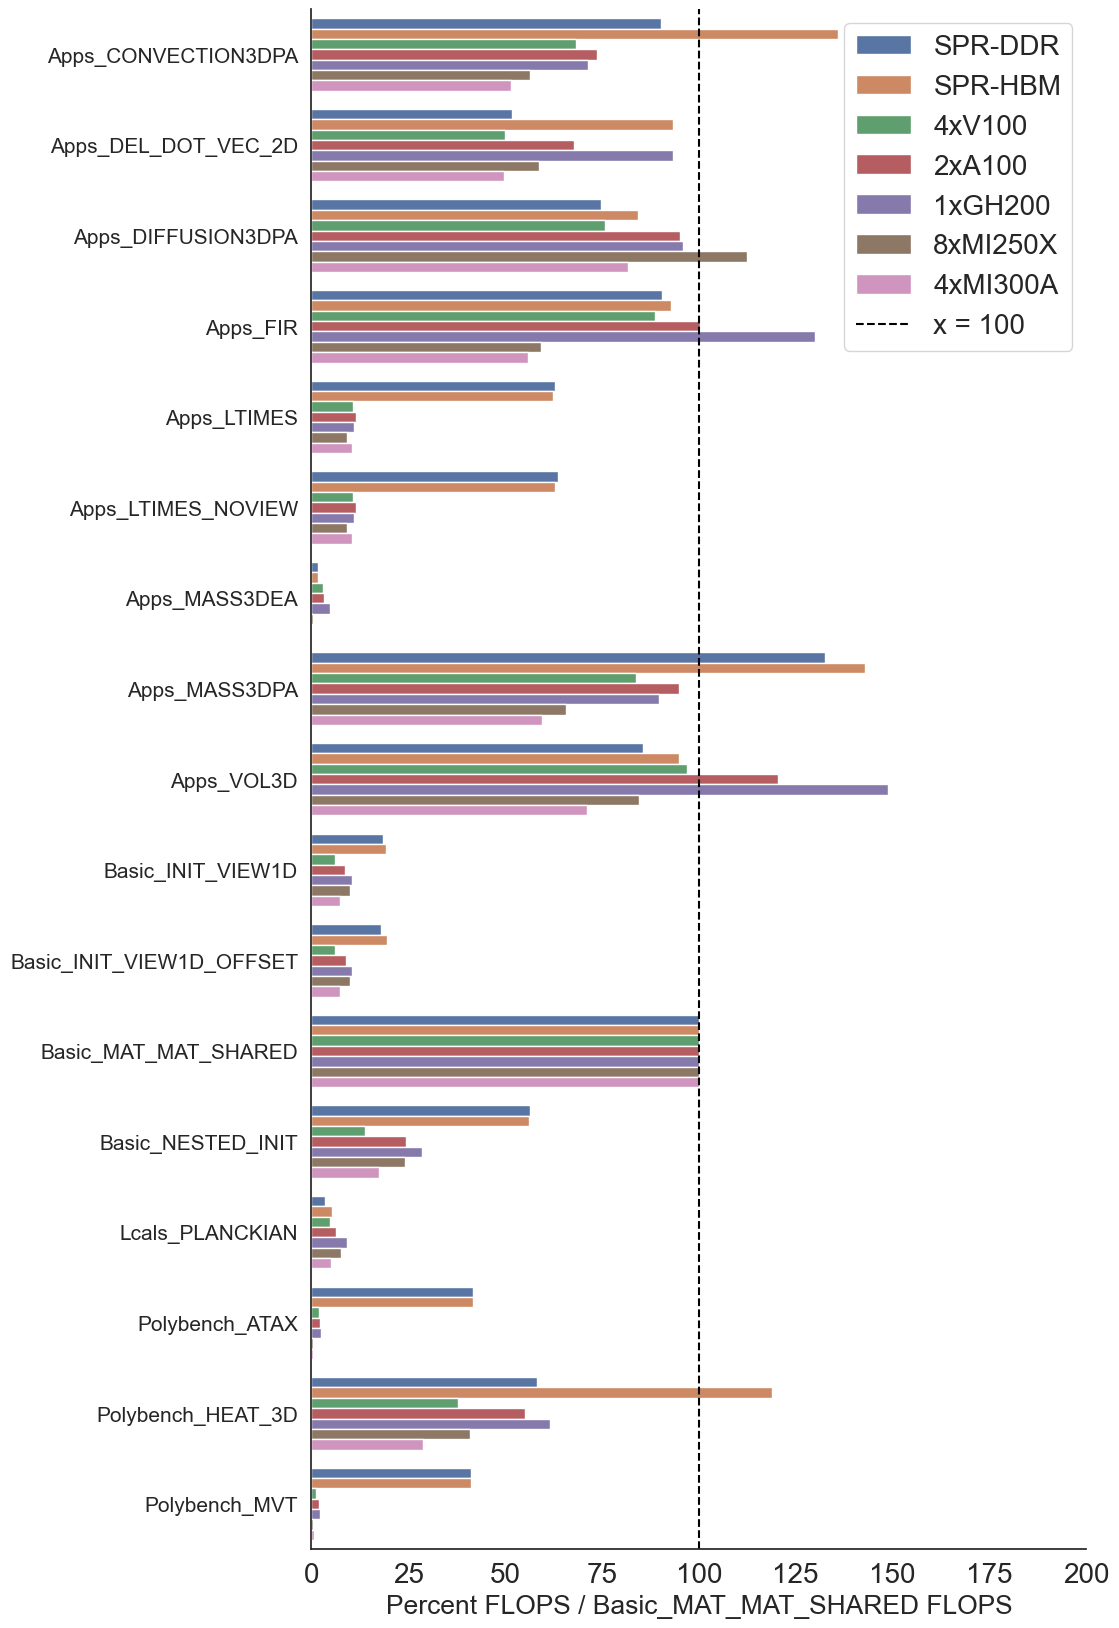

In [96]:
# Reshape the data to long format
df_long = pd.melt(perc_mat_mat_df, id_vars=["Kernel"], var_name="Architecture", value_name="Percent of Basic_MAT_MAT_SHARED")
df_long["Percent of Basic_MAT_MAT_SHARED"] = df_long["Percent of Basic_MAT_MAT_SHARED"] * 100

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" Percent of Basic_MAT_MAT_SHARED", "")

df_long = df_long.replace(num_map)

# Plot
plt.figure(figsize=(10, 20))
sns.barplot(x="Percent of Basic_MAT_MAT_SHARED", y="Kernel", hue="Architecture", data=df_long, orient="h")
#plt.title("Percent of Basic_MAT_MAT_SHARED for Compute Bound Cluster")
plt.xlabel("Percent FLOPS / Basic_MAT_MAT_SHARED FLOPS")
plt.ylabel("")
plt.axvline(x=100, color='black', linestyle='--', label="x = 100")
plt.xlim(0, 200)
#plt.tight_layout()
plt.legend(title="")
sns.despine()
plt.show()

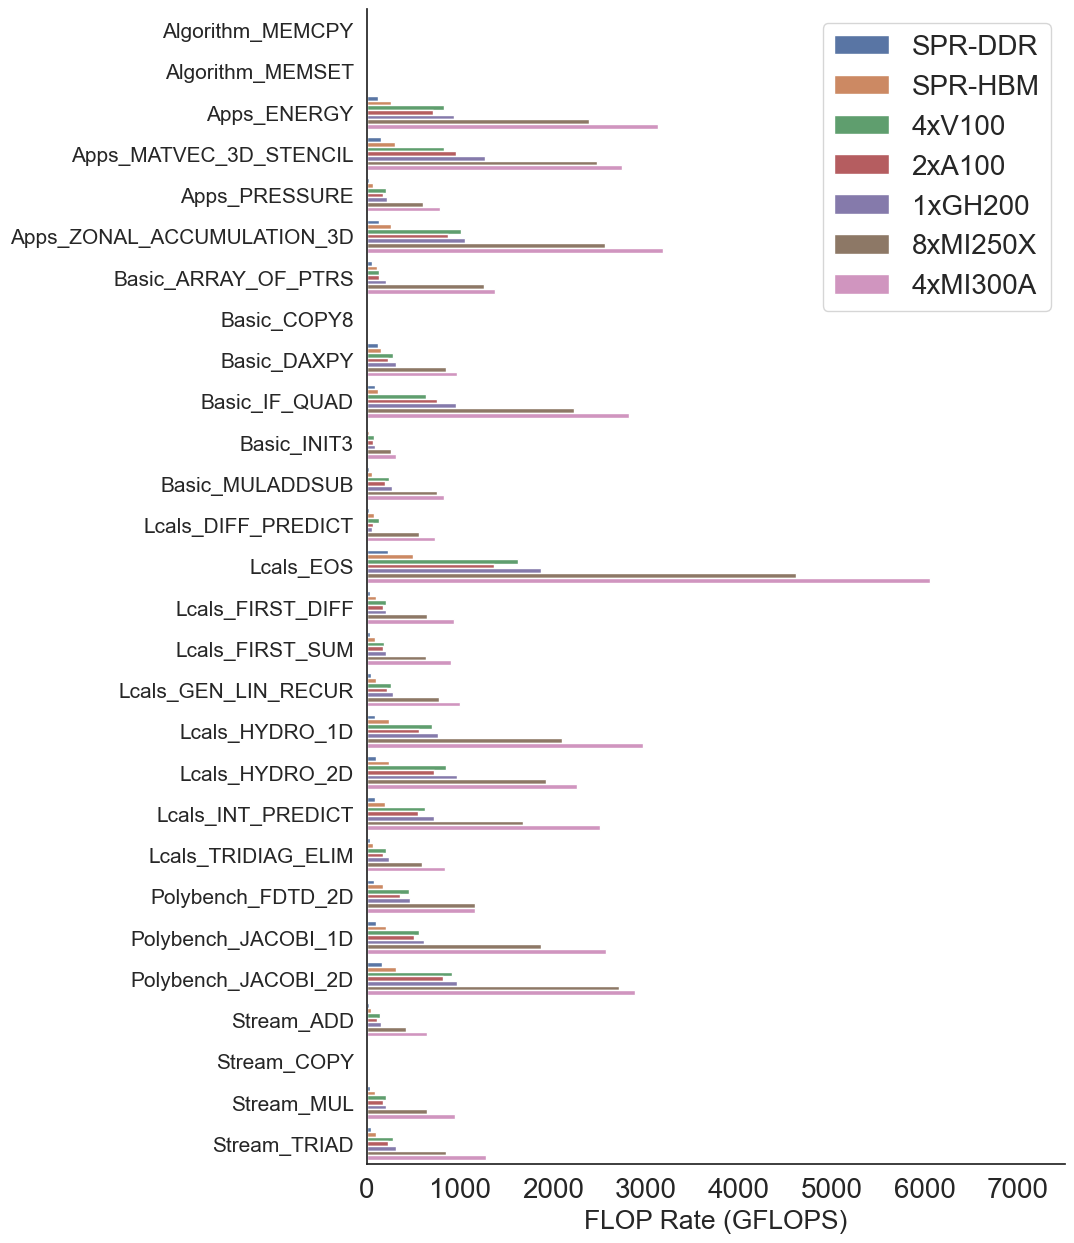

<Figure size 2800x800 with 0 Axes>

In [97]:
# Reshape the data to long format
df_long = pd.melt(raw_flop_df_membound, id_vars=["Kernel"], var_name="Architecture", value_name="FLOP Rate")

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" FLOP Rate", "")

df_long = df_long.replace(num_map)

# Plot
fig, ax = plt.subplots(figsize=(9, 15))
sns.barplot(x="FLOP Rate", y="Kernel", hue="Architecture", data=df_long, orient="h")
plt.xlabel("FLOP Rate (GFLOPS)")
plt.ylabel("")

lim=7500
# Cap the x-axis at 200
plt.xlim(0, lim)

# Annotate values greater than lim
for i, row in df_long.iterrows():
    if row["FLOP Rate"] > lim:
        x_val = min(row["FLOP Rate"], lim)
        mod = len(set(df_long["Kernel"]))
        ax.text(
            x_val, i%mod+(i//mod*0.2)-.7, 
            f"{row['FLOP Rate']:.1f}", 
            #color='red', 
            #va='bottom', 
            fontsize=10
        )
#plt.tight_layout()
sns.despine()
plt.legend(title="")
plt.show()
plt.clf()

## ALL Kernels

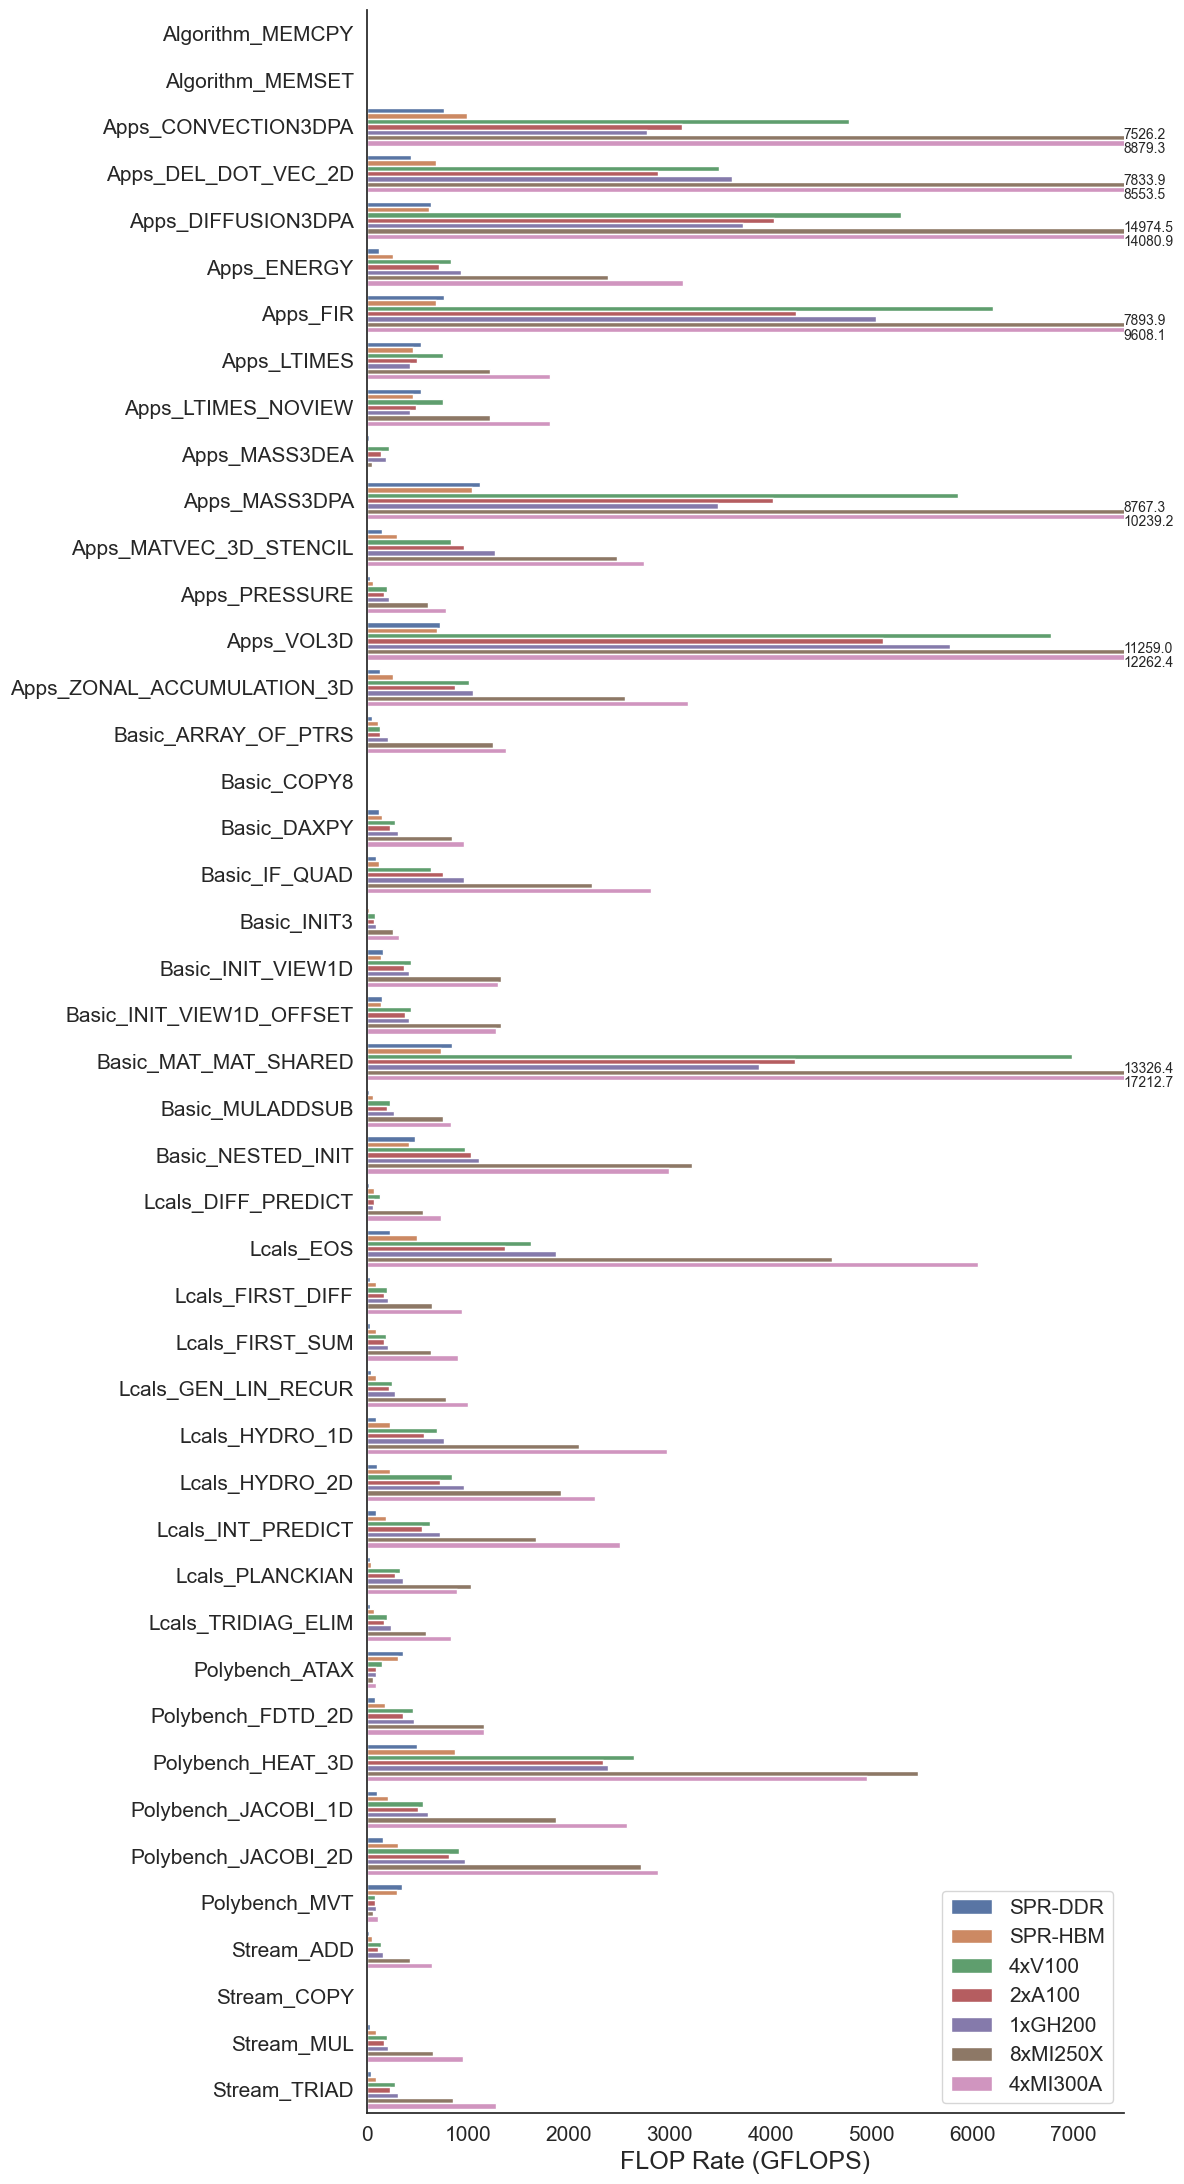

<Figure size 2800x800 with 0 Axes>

In [115]:
sns.set(style='white')
# Reshape the data to long format
df_long = pd.melt(raw_flop_df_all, id_vars=["Kernel"], var_name="Architecture", value_name="FLOP Rate")

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" FLOP Rate", "")

df_long = df_long.replace(num_map)

# Plot
fig, ax = plt.subplots(figsize=(12, 22),)
sns.barplot(x="FLOP Rate", y="Kernel", hue="Architecture", data=df_long, orient="h")
plt.tick_params(axis="both", which="major", labelsize=15)
plt.xlabel("FLOP Rate (GFLOPS)", fontsize=18)
plt.ylabel("")

lim=7500
# Cap the x-axis at 200
plt.xlim(0, lim)

# Annotate values greater than lim
for i, row in df_long.iterrows():
    if row["FLOP Rate"] > lim:
        x_val = min(row["FLOP Rate"], lim)
        mod = len(set(df_long["Kernel"]))
        ax.text(
            x_val, i%mod+(i//mod*0.3)-1.25, 
            f"{row['FLOP Rate']:.1f}", 
            #color='red', 
            #va='bottom', 
            fontsize=10
        )
plt.tight_layout()
sns.despine()
plt.legend(title="", loc="lower right",fontsize=15)
plt.savefig("raw_flop_barchart.png")
plt.show()
plt.clf()

In [99]:
# sns.set_theme(rc={'figure.figsize':(20,20)})
# #xticklabels = ["CPU",'GPU-Prev', 'GPU-New','GPU-NV', 'GPU-AMD', 'GPU', 'All',"CPU",'GPU-Prev', 'GPU-New','GPU-NV', 'GPU-AMD', 'GPU', 'All',]
# raw_flop_heatmap = sns.heatmap(raw_flop_df_all, vmin=0, vmax=700, cbar_kws={"shrink": 0.5}).get_figure()
# #perf_port_heatmap.gca().set(xlabel="FLOPS-BASED SCORES                                                                                    BANDWIDTH-BASED SCORES", ylabel="")
# raw_flop_heatmap.tight_layout()
# raw_flop_heatmap.savefig("raw_flop_heatmap.svg") 
# raw_flop_heatmap.show()

In [100]:
raw_bw_df_all = bandwidth_df.loc[:, [
    "Kernel",
    "SPR-DDR Memory Bandwidth",
    "SPR-HBM Memory Bandwidth",
    "V100 Memory Bandwidth", 
    "A100 Memory Bandwidth", 
    "GH200 Memory Bandwidth", 
    "MI250X Memory Bandwidth", 
    "MI300A Memory Bandwidth"
    ]]
raw_bw_df_all

,Kernel,SPR-DDR Memory Bandwidth,SPR-HBM Memory Bandwidth,V100 Memory Bandwidth,A100 Memory Bandwidth,GH200 Memory Bandwidth,MI250X Memory Bandwidth,MI300A Memory Bandwidth
0,Algorithm_MEMCPY,492.139527,1671.308905,3186.034348,2637.727285,3320.817266,10343.428157,15027.843169
1,Algorithm_MEMSET,2967.769980,3037.671182,3461.603152,2968.143727,3256.709167,10648.219932,12056.230996
2,Apps_CONVECTION3DPA,413.507972,538.333090,2589.548521,1693.017237,1502.164939,4076.772730,4809.744052
3,Apps_DEL_DOT_VEC_2D,389.174360,608.116778,3102.874034,2562.372588,3218.013546,6968.047870,7606.638651
4,Apps_DIFFUSION3DPA,333.120336,323.971713,2788.528017,2123.587496,1960.720114,7884.638184,7414.145930
5,Apps_ENERGY,456.613871,1013.775265,3252.354602,2781.434316,3672.493530,9365.868528,12290.952257
6,Apps_FIR,382.457605,339.444609,3103.118936,2128.346898,2524.810353,3946.939766,4804.089371
7,Apps_LTIMES,151.899371,130.389079,214.330574,139.669739,120.675394,348.445595,518.203137
8,Apps_LTIMES_NOVIEW,153.676686,131.323967,214.488809,139.658858,120.642783,348.479252,518.255928
9,Apps_MASS3DEA,18.179991,15.687428,254.654857,163.778422,215.844772,59.082297,1.523342


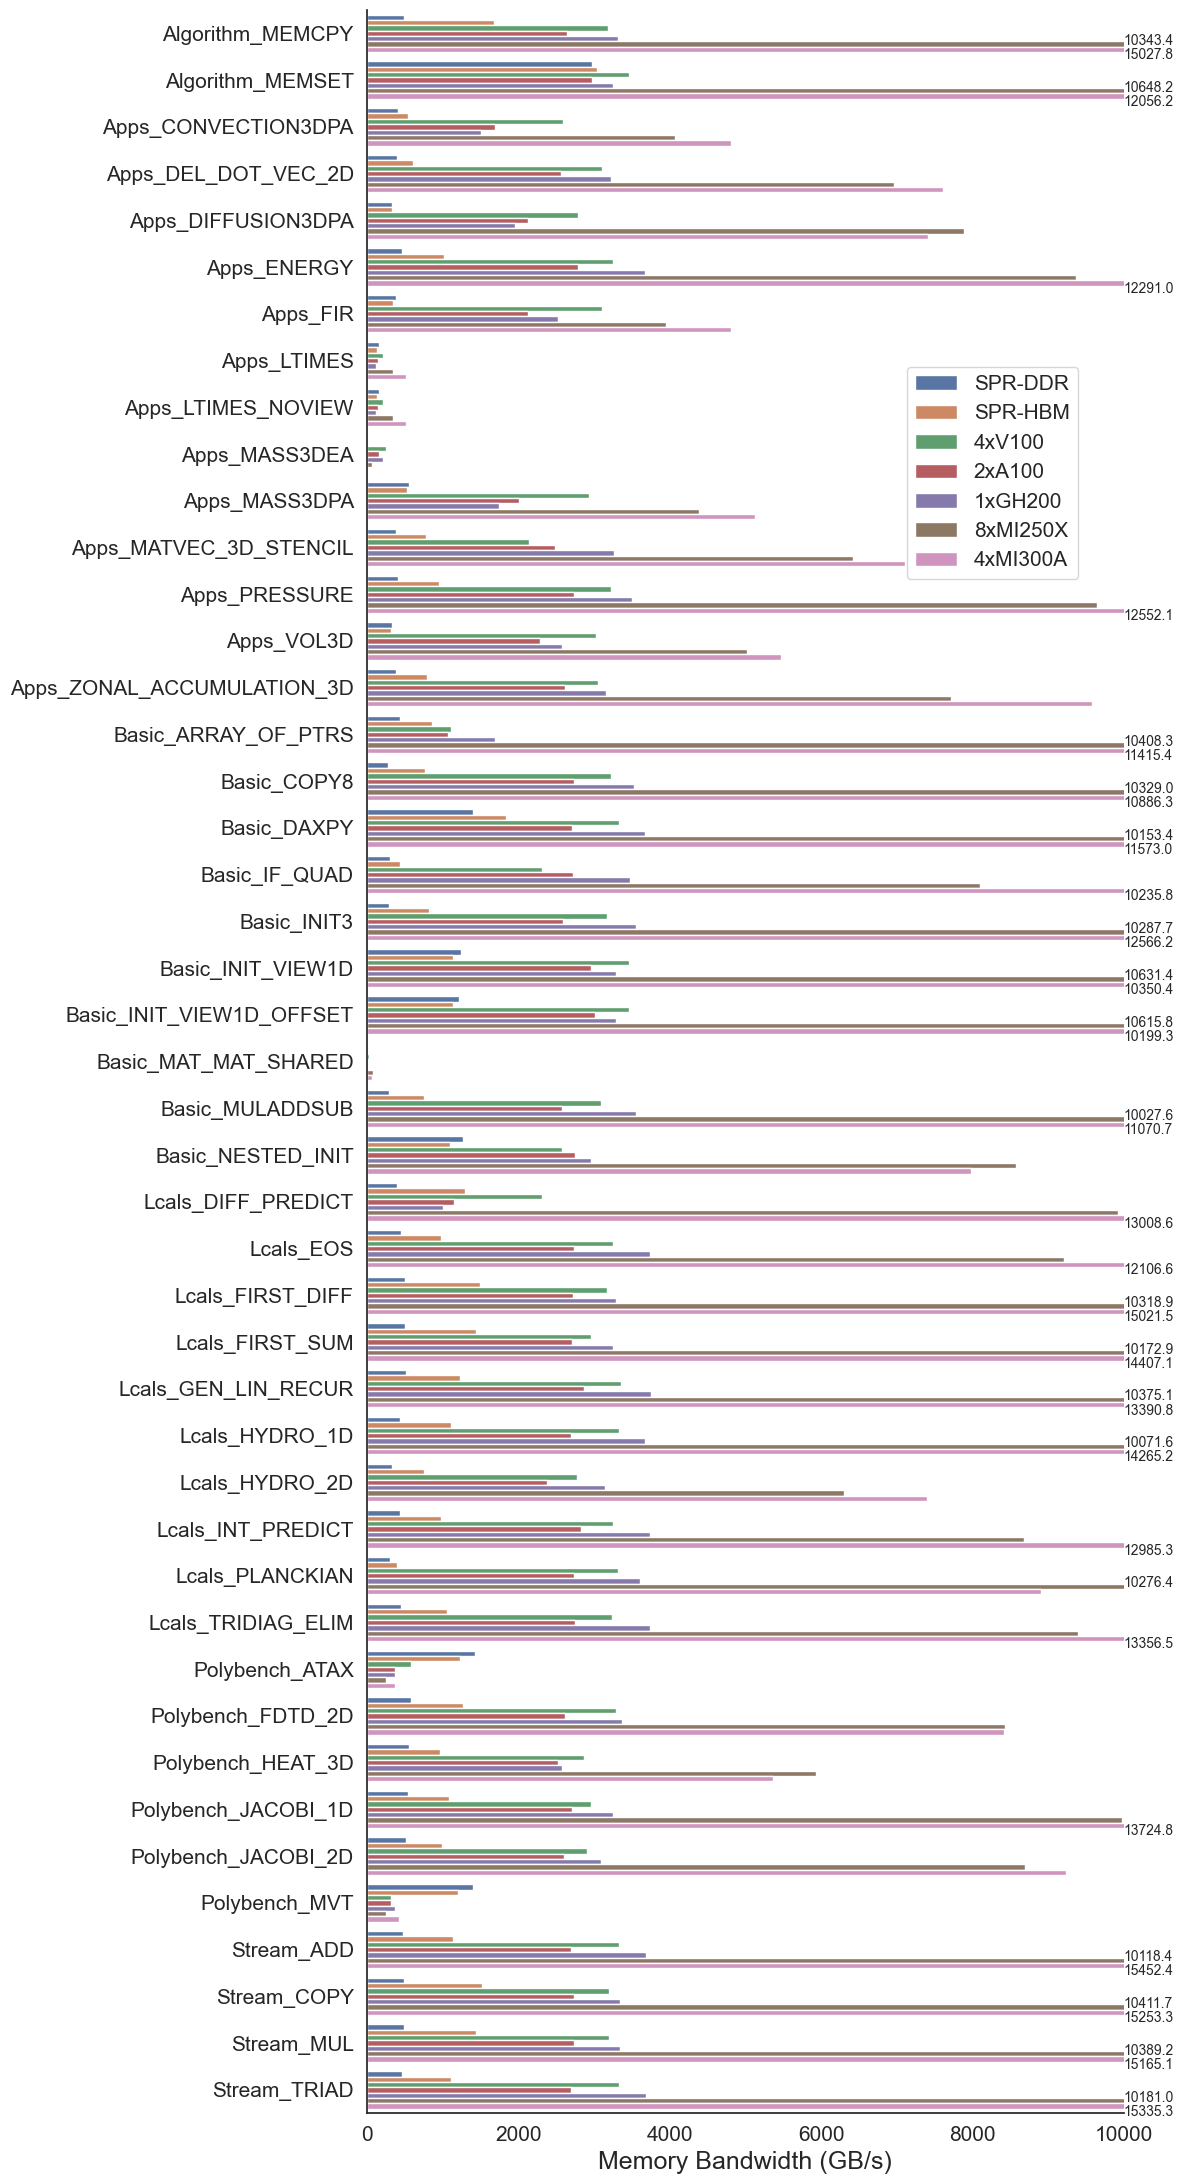

<Figure size 2800x800 with 0 Axes>

In [116]:
# Reshape the data to long format
df_long = pd.melt(raw_bw_df_all, id_vars=["Kernel"], var_name="Architecture", value_name="Memory Bandwidth")

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" Memory Bandwidth", "")

df_long = df_long.replace(num_map)

# Plot
plt.figure(figsize=(12, 22))
ax = sns.barplot(
    x="Memory Bandwidth", 
    y="Kernel", 
    hue="Architecture", 
    data=df_long, 
    orient="h"
)
plt.tick_params(axis="both", which="major", labelsize=15)
plt.xlabel("Memory Bandwidth (GB/s)", fontsize=18)
plt.ylabel("")

lim=10000
# Cap the x-axis at 200
plt.xlim(0, lim)

# Annotate values greater than lim
for i, row in df_long.iterrows():
    if row["Memory Bandwidth"] > lim:
        x_val = min(row["Memory Bandwidth"], lim)
        mod = len(set(df_long["Kernel"]))
        ax.text(
            x_val, i%mod+(i//mod*0.3)-1.25, 
            f"{row['Memory Bandwidth']:.1f}", 
            #color='red', 
            #va='bottom', 
            fontsize=10
        )
    
plt.legend(bbox_to_anchor=(.7, 0.78), fontsize=15)
#plt.axvline(x=100, color='black', linestyle='--', label="x = 100")
sns.despine()
plt.tight_layout()
plt.savefig("raw_bandwidth_barchart.png")
plt.show()
plt.clf()

# for the retiring cluster, which set gets speedup higher than stream - and on which platforms?

In [102]:
bandwidth_df

,Kernel,SPR-DDR Memory Bandwidth,SPR-HBM Memory Bandwidth,V100 Memory Bandwidth,A100 Memory Bandwidth,GH200 Memory Bandwidth,MI250X Memory Bandwidth,MI300A Memory Bandwidth,Cluster ID,SPR-DDR Percent of Stream_TRIAD,SPR-HBM Percent of Stream_TRIAD,V100 Percent of Stream_TRIAD,A100 Percent of Stream_TRIAD,GH200 Percent of Stream_TRIAD,MI250X Percent of Stream_TRIAD,MI300A Percent of Stream_TRIAD
0,Algorithm_MEMCPY,492.139527,1671.308905,3186.034348,2637.727285,3320.817266,10343.428157,15027.843169,1,1.055943,1.501790,0.956164,0.979060,0.901395,1.015955,0.979949
1,Algorithm_MEMSET,2967.769980,3037.671182,3461.603152,2968.143727,3256.709167,10648.219932,12056.230996,1,6.367695,2.729563,1.038866,1.101703,0.883994,1.045893,0.786173
2,Apps_CONVECTION3DPA,413.507972,538.333090,2589.548521,1693.017237,1502.164939,4076.772730,4809.744052,0,0.887229,0.483730,0.777152,0.628407,0.407744,0.400430,0.313638
3,Apps_DEL_DOT_VEC_2D,389.174360,608.116778,3102.874034,2562.372588,3218.013546,6968.047870,7606.638651,0,0.835019,0.546436,0.931207,0.951090,0.873490,0.684418,0.496020
4,Apps_DIFFUSION3DPA,333.120336,323.971713,2788.528017,2123.587496,1960.720114,7884.638184,7414.145930,0,0.714748,0.291112,0.836868,0.788224,0.532213,0.774447,0.483468
5,Apps_ENERGY,456.613871,1013.775265,3252.354602,2781.434316,3672.493530,9365.868528,12290.952257,1,0.979718,0.910949,0.976068,1.032401,0.996853,0.919937,0.801479
6,Apps_FIR,382.457605,339.444609,3103.118936,2128.346898,2524.810353,3946.939766,4804.089371,0,0.820607,0.305015,0.931280,0.789991,0.685329,0.387678,0.313269
7,Apps_LTIMES,151.899371,130.389079,214.330574,139.669739,120.675394,348.445595,518.203137,0,0.325918,0.117164,0.064323,0.051842,0.032756,0.034225,0.033791
8,Apps_LTIMES_NOVIEW,153.676686,131.323967,214.488809,139.658858,120.642783,348.479252,518.255928,0,0.329731,0.118004,0.064370,0.051838,0.032747,0.034228,0.033795
9,Apps_MASS3DEA,18.179991,15.687428,254.654857,163.778422,215.844772,59.082297,1.523342,0,0.039007,0.014096,0.076425,0.060791,0.058588,0.005803,0.000099


In [103]:
retiring_stream_df = triple_plot_df[(triple_plot_df["Cluster ID"] == 0) | (triple_plot_df["Kernel"] == "Stream_TRIAD")][[
    "Kernel",
    "V100 Speedup",
    "A100 Speedup",
    "GH200 Speedup",
    "MI250X Speedup",
    "MI300A Speedup"]
]
retiring_stream_df

,Kernel,V100 Speedup,A100 Speedup,GH200 Speedup,MI250X Speedup,MI300A Speedup
2,Apps_CONVECTION3DPA,6.262460,4.094343,3.632800,9.859156,11.631762
3,Apps_DEL_DOT_VEC_2D,7.980201,6.586540,8.275382,17.913766,19.563365
4,Apps_DIFFUSION3DPA,8.371183,6.375029,5.886129,23.669824,22.257460
6,Apps_FIR,8.114739,5.538746,6.602458,10.321326,12.562827
7,Apps_LTIMES,1.412363,0.920424,0.795273,2.295889,3.414777
8,Apps_LTIMES_NOVIEW,1.397028,0.909689,0.785845,2.269503,3.375551
9,Apps_MASS3DEA,13.981073,8.991535,11.846833,3.243761,0.083636
10,Apps_MASS3DPA,5.232003,3.594719,3.109041,7.830085,9.144523
13,Apps_VOL3D,10.380602,7.874478,9.027100,17.050863,18.762958
20,Basic_INIT_VIEW1D,2.781011,2.371934,2.642665,8.526826,8.301505


In [104]:
df = retiring_stream_df

# Find the value of Stream_TRIAD for each column
stream_triad = df[df['Kernel'] == "Stream_TRIAD"].iloc[:, 1:]

# Filter rows with values greater than Stream_TRIAD
filtered_df = df[df.iloc[:, 1:].gt(stream_triad.values).any(axis=1)]

# Display the filtered DataFrame
stream_triad["Kernel"] = "Stream_TRIAD"
tdf = pd.concat([filtered_df,stream_triad])
tdf

,Kernel,V100 Speedup,A100 Speedup,GH200 Speedup,MI250X Speedup,MI300A Speedup
3,Apps_DEL_DOT_VEC_2D,7.980201,6.586540,8.275382,17.913766,19.563365
4,Apps_DIFFUSION3DPA,8.371183,6.375029,5.886129,23.669824,22.257460
6,Apps_FIR,8.114739,5.538746,6.602458,10.321326,12.562827
9,Apps_MASS3DEA,13.981073,8.991535,11.846833,3.243761,0.083636
13,Apps_VOL3D,10.380602,7.874478,9.027100,17.050863,18.762958
33,Lcals_PLANCKIAN,10.960802,9.059235,11.919954,33.989297,29.484457
44,Stream_TRIAD,7.149434,5.780622,7.904667,21.844581,32.903838


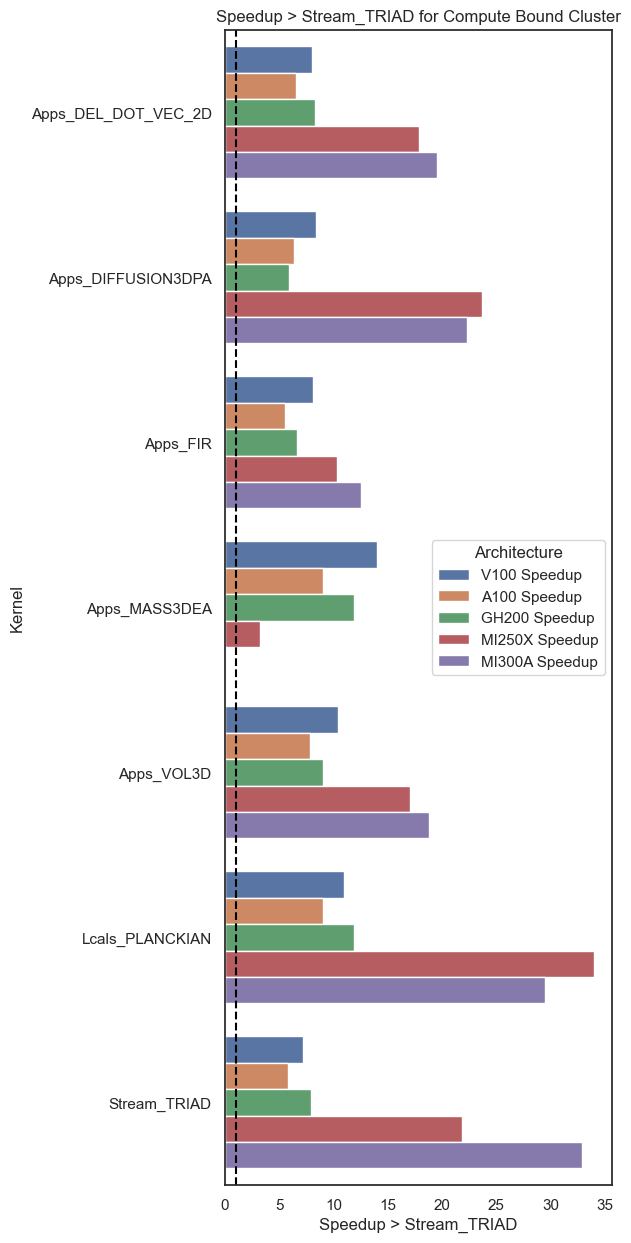

In [105]:
# Reshape the data to long format
df_long = pd.melt(tdf, id_vars=["Kernel"], var_name="Architecture", value_name="Speedup > Stream_TRIAD")

# Extract architecture from column name
df_long['Architecture'] = df_long['Architecture'].str.replace(" Speedup > Stream_TRIAD", "")

# Plot
plt.figure(figsize=(5, 15))
sns.barplot(x="Speedup > Stream_TRIAD", y="Kernel", hue="Architecture", data=df_long, orient="h")
plt.title("Speedup > Stream_TRIAD for Compute Bound Cluster")
plt.xlabel("Speedup > Stream_TRIAD")
plt.ylabel("Kernel")
plt.axvline(x=1, color='black', linestyle='--', label="x = 1")
#plt.tight_layout()
plt.show()

In [106]:
tdf

,Kernel,V100 Speedup,A100 Speedup,GH200 Speedup,MI250X Speedup,MI300A Speedup
3,Apps_DEL_DOT_VEC_2D,7.980201,6.586540,8.275382,17.913766,19.563365
4,Apps_DIFFUSION3DPA,8.371183,6.375029,5.886129,23.669824,22.257460
6,Apps_FIR,8.114739,5.538746,6.602458,10.321326,12.562827
9,Apps_MASS3DEA,13.981073,8.991535,11.846833,3.243761,0.083636
13,Apps_VOL3D,10.380602,7.874478,9.027100,17.050863,18.762958
33,Lcals_PLANCKIAN,10.960802,9.059235,11.919954,33.989297,29.484457
44,Stream_TRIAD,7.149434,5.780622,7.904667,21.844581,32.903838


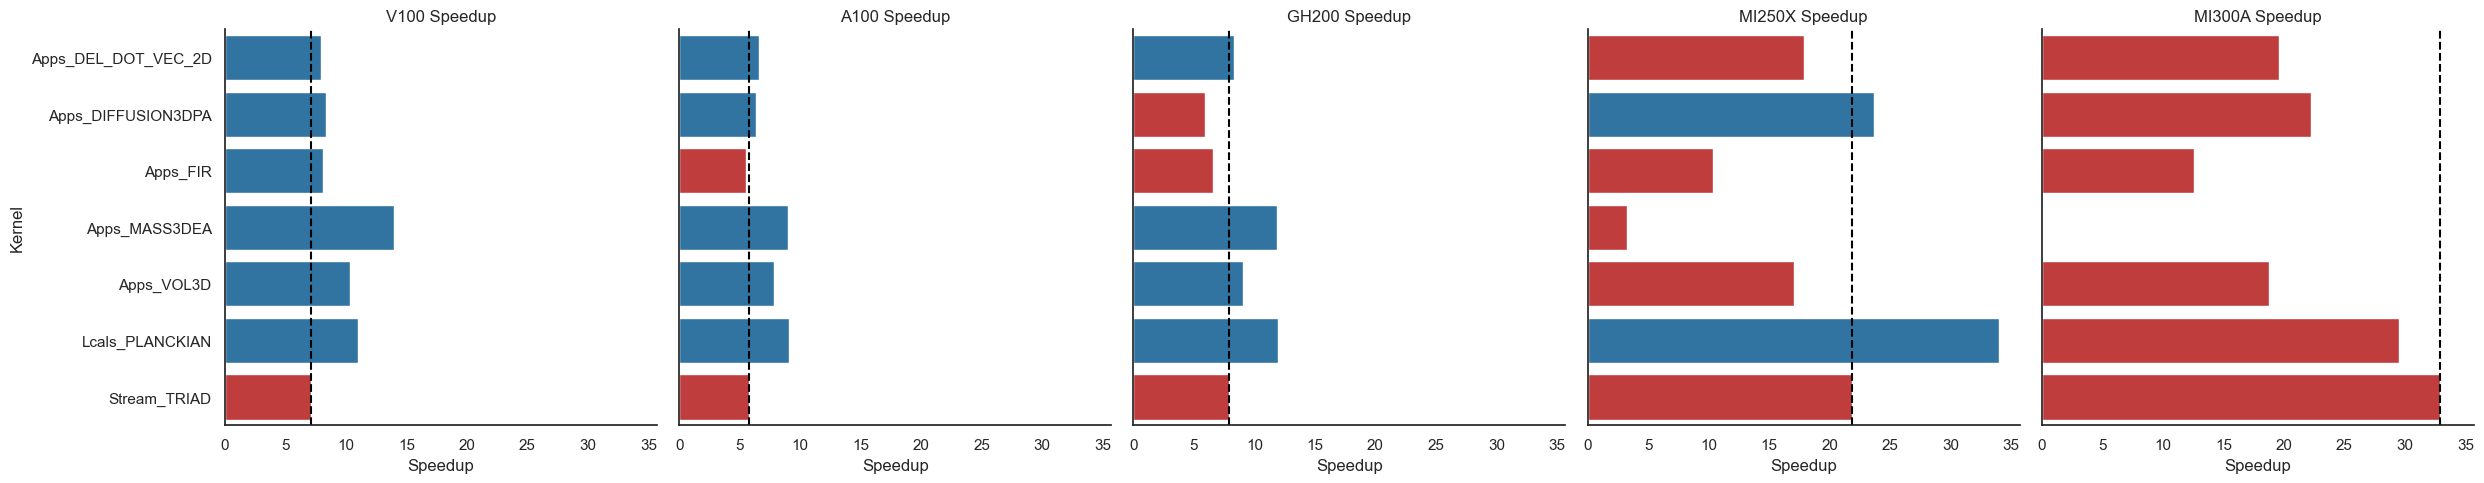

In [107]:
# Reshape the data to long format
df_long = pd.melt(tdf, id_vars=["Kernel"], var_name="Architecture", value_name="Speedup")

# Extract Stream_TRIAD values for each architecture
stream_triads = df_long[df_long['Kernel'] == 'Stream_TRIAD'][['Architecture', 'Speedup']].set_index('Architecture')

# Merge the Stream_TRIAD values with the original dataframe
df_long = df_long.merge(stream_triads, on='Architecture', suffixes=('', '_Stream_TRIAD'))

# Add a 'Color' column based on whether the value is higher than the corresponding Stream_TRIAD value
df_long['Color'] = df_long.apply(lambda row: 'orange' if row['Speedup'] > row['Speedup_Stream_TRIAD'] else 'green', axis=1)

# Plot using FacetGrid
g = sns.FacetGrid(df_long, col="Architecture", col_wrap=5, height=5, sharey=True)
g.map(sns.barplot, "Speedup", "Kernel", data=df_long, hue="Color", orient="h", palette=["tab:blue", "tab:red"])

# Add vertical line at x = 1
for i, ax in enumerate(g.axes.flat):
    ax.axvline(x=tdf[tdf["Kernel"] == "Stream_TRIAD"].T.iloc[i+1].iloc[0], color='black', linestyle='--', label="x = 1")
    ax.set_title(ax.get_title(), fontsize=12)

g.set_axis_labels("Speedup", "Kernel")
g.set_titles(col_template="{col_name}")

plt.subplots_adjust(hspace=0.5)
plt.show()

## Kernels that didn't achieve Stream_TRIAD on MI300A but did on other GPUs

In [108]:
memory_bound_df = bandwidth_df[(bandwidth_df["Cluster ID"] == 0) | (bandwidth_df["Cluster ID"] == 1)]

slow_kernels = {"V100": [], "MI250X": [], "MI300A": []}
for i, gpu_type in enumerate(["V100", "MI250X", "MI300A"]): 
    for index, _ in memory_bound_df.iterrows():
        if memory_bound_df["{} Percent of Stream_TRIAD".format(gpu_type)].loc[index] < 1:
            kernel = memory_bound_df["Kernel".format(gpu_type)].loc[index]
            slow_kernels[gpu_type].append(kernel)
            
slow_kernels

{'V100': ['Algorithm_MEMCPY',
  'Apps_CONVECTION3DPA',
  'Apps_DEL_DOT_VEC_2D',
  'Apps_DIFFUSION3DPA',
  'Apps_ENERGY',
  'Apps_FIR',
  'Apps_LTIMES',
  'Apps_LTIMES_NOVIEW',
  'Apps_MASS3DEA',
  'Apps_MASS3DPA',
  'Apps_MATVEC_3D_STENCIL',
  'Apps_PRESSURE',
  'Apps_VOL3D',
  'Apps_ZONAL_ACCUMULATION_3D',
  'Basic_ARRAY_OF_PTRS',
  'Basic_COPY8',
  'Basic_IF_QUAD',
  'Basic_INIT3',
  'Basic_MAT_MAT_SHARED',
  'Basic_MULADDSUB',
  'Basic_NESTED_INIT',
  'Lcals_DIFF_PREDICT',
  'Lcals_EOS',
  'Lcals_FIRST_DIFF',
  'Lcals_FIRST_SUM',
  'Lcals_HYDRO_1D',
  'Lcals_HYDRO_2D',
  'Lcals_INT_PREDICT',
  'Lcals_PLANCKIAN',
  'Lcals_TRIDIAG_ELIM',
  'Polybench_ATAX',
  'Polybench_FDTD_2D',
  'Polybench_HEAT_3D',
  'Polybench_JACOBI_1D',
  'Polybench_JACOBI_2D',
  'Polybench_MVT',
  'Stream_COPY',
  'Stream_MUL'],
 'MI250X': ['Apps_CONVECTION3DPA',
  'Apps_DEL_DOT_VEC_2D',
  'Apps_DIFFUSION3DPA',
  'Apps_ENERGY',
  'Apps_FIR',
  'Apps_LTIMES',
  'Apps_LTIMES_NOVIEW',
  'Apps_MASS3DEA',
  'Apps_M

In [109]:
v100_mi300a = set(slow_kernels["MI300A"]) - set(slow_kernels["V100"])
mi250x_mi300a =  set(slow_kernels["MI300A"]) - set(slow_kernels["MI250X"])

print(v100_mi300a)
print(mi250x_mi300a)

{'Lcals_GEN_LIN_RECUR', 'Basic_INIT_VIEW1D_OFFSET', 'Basic_INIT_VIEW1D', 'Algorithm_MEMSET', 'Basic_DAXPY'}
{'Lcals_GEN_LIN_RECUR', 'Lcals_FIRST_DIFF', 'Stream_MUL', 'Basic_COPY8', 'Lcals_PLANCKIAN', 'Basic_ARRAY_OF_PTRS', 'Basic_INIT_VIEW1D_OFFSET', 'Basic_INIT_VIEW1D', 'Stream_COPY', 'Basic_INIT3', 'Algorithm_MEMSET', 'Algorithm_MEMCPY'}


#### 6.3D Parallel Coordinate Plots

Note: these plots are created with the plotly library which may require updates to your jupyter environment, and they will not render in LLNL's LC jupyter environment

If experiencing rendering issues, try the following command followed by restarting the kernel.
```
pip install --upgrade nbformat
```

In [110]:
# Get the averages
avg_no_outliers = relevant_metrics_df.set_index("Kernel").groupby("Cluster ID", as_index=False).mean()
avg_no_outliers.head()

,Cluster ID,Frontend Bound,Bad Speculation,Retiring,Core Bound,Memory Bound,Speedup on SPR-HBM,Speedup on P9-V100,Speedup on CAS-A100,Speedup on GR-GH200,Speedup on EPYC-MI250X,Speedup on MI300A
0,0,0.085493,0.002760,0.639008,0.155812,0.116927,1.032833,5.265954,3.938533,4.440836,9.919347,9.892394
1,1,0.018416,0.014161,0.080895,0.062296,0.824238,2.356169,6.745077,5.796123,7.501788,21.325774,27.520972


In [111]:
# fig = go.Figure(data=
#     # 
#     go.Parcoords(
#         line = dict(color = avg_no_outliers["Cluster ID"],
#                    colorscale = [[0, "purple"], [0.33, "green"], [0.66, "red"], [1, "darkorange"],]),
#         dimensions = list([
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = "Bad Speculation", values = avg_no_outliers["Bad Speculation"]),
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = "Frontend Bound", values = avg_no_outliers["Frontend Bound"]),
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = "Core Bound", values = avg_no_outliers["Core Bound"]),
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = "Memory Bound", values = avg_no_outliers["Memory Bound"]),
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = "Retiring", values = avg_no_outliers["Retiring"]),
#             dict(range = [-10,22],
#                  tickvals = [0,2,4,],
#                 label = "SPR-HBM Speedup", values = avg_no_outliers["Speedup on SPR-HBM"]),
#             dict(range = [-10,22],
#                  tickvals = [0,2,4,6,8,10],
#                 label = "P9-V100 Speedup", values = avg_no_outliers["Speedup on P9-V100"]),
#             dict(range = [-10,22],
#                  tickvals = [0,2,4,6,8,10,12,14,16,18,20,22],
#                 label = "EPYC-MI250X Speedup", values = avg_no_outliers["Speedup on EPYC-MI250X"])
#         ])
#     ),
#     #Custom Legend
#     go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="0",
#             marker=dict(size=7, color="purple", ),
#         ),

#         go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="1",
#             marker=dict(size=7, color="green", ),
#         ),

#         go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="2",
#             marker=dict(size=7, color="red",),
#         ),
#         go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="3",
#             marker=dict(size=7, color="darkorange",),
#         ),               
#     ]   
# )

# fig.update_layout(
#     width=1100, height=750,
#     plot_bgcolor = "white",
#     paper_bgcolor = "white"
# )
# fig.update_xaxes(showticklabels=False)
# fig.update_yaxes(showticklabels=False)
# fig.update_layout(
#     legend=dict(
#         title="Cluster",
#         orientation="h",
#         yanchor="auto",
#         y=0.9,
#         xanchor="right",
#         x=0.3
#     )
# )

# #fig.write_image("images/par_coord_AVG_NO_OUTLIERS.png")

# fig.show()

In [112]:
# # plot all kernels
# fig = go.Figure(data=
#     [
#         go.Parcoords(
#             line = dict(
#                 color = relevant_metrics_df["Cluster ID"], 
#                 colorscale = [[0, "purple"], [0.33, "green"], [0.66, "red"], [1, "darkorange"],]
#             ),
#             dimensions = list([
#                 dict(
#                     range = [0, 5],
#                     tickvals = [0, 0.2, 0.4, 0.6, 0.8, 1],
#                     label = "Bad Speculation",
#                     values = relevant_metrics_df["Bad Speculation"],
#                 ),
#                 dict(
#                     range = [0, 5],
#                     tickvals = [0, 0.2, 0.4, 0.6, 0.8, 1],
#                     label = "Frontend Bound",
#                     values = relevant_metrics_df["Frontend Bound"],
#                 ),
#                 dict(
#                     range = [0, 5],
#                     tickvals = [0, 0.2, 0.4, 0.6, 0.8, 1],
#                     label = "Core Bound",
#                     values = relevant_metrics_df["Core Bound"],
#                 ),
#                 dict(
#                     range = [0, 5],
#                     tickvals = [0, 0.2, 0.4, 0.6, 0.8, 1],
#                     label = "Memory Bound",
#                     values = relevant_metrics_df["Memory Bound"],
#                 ),
#                 dict(
#                     range = [0, 5],
#                     tickvals = [0, 0.2, 0.4, 0.6, 0.8, 1],
#                     label = "Retiring",
#                     values = relevant_metrics_df["Retiring"],
#                 ),
#                 dict(
#                     range = [-10, 40],
#                     tickvals = [0, 5],
#                     label = "SPR-HBM Speedup",
#                     values = relevant_metrics_df["Speedup on SPR-HBM"],
#                 ),
#                 dict(
#                     range = [-10, 40],
#                     tickvals = [0, 5, 10, 15, 20],
#                     label = "P9-V100 Speedup",
#                     values = relevant_metrics_df["Speedup on P9-V100"],
#                 ),
#                 dict(
#                     range = [-10, 40],
#                     tickvals = [0, 10, 20, 30, 40],
#                     label = "EPYC-MI250X Speedup",
#                     values = relevant_metrics_df["Speedup on EPYC-MI250X"],
#                 )
#             ])
#         ),
#         #Custom Legend
#         go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="0",
#             marker=dict(size=7, color="purple"),
#         ),

#         go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="1",
#             marker=dict(size=7, color="green"),
#         ),

#         go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="2",
#             marker=dict(size=7, color="red"),
#         ),
#         go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="3",
#             marker=dict(size=7, color="darkorange"),
#         ),                    
#     ]   
# )

# fig.update_layout(
#     width=900,
#     height=1000,
#     plot_bgcolor = "white",
#     paper_bgcolor = "white",
# )

# fig.update_xaxes(showticklabels=False)
# fig.update_yaxes(showticklabels=False)
# fig.update_layout(
#     legend=dict(
#         title="Cluster",
#         orientation="h",
#         yanchor="auto",
#         y=0.9,
#         xanchor="right",
#         x=0.4,
#     )
# )

# #fig.write_image("images/par_coord_NO_OUTLIERS.png")

# fig.show()